# ASSIGNMENT 5 (Policy Gradient and Actor Critic Methods)
# Submission Deadline: 30-03-2026, 11:59 PM
# Submission Link: [https://forms.gle/UYb1Lu6jiSiCiWVs8](https://forms.gle/UYb1Lu6jiSiCiWVs8)

# Table of Contents

1. [Provide Information](#Provide-Information)
2. [Instructions](#Instructions)
3. [Environment](#Environment)
4. [Hyperparameters](#Hyperparameters)
5. [Helper Functions](#helper)
6. [DDPG](#ddpg)
7. [TD3](#td3)
8. [SAC](#SAC)
9. [PPO](#ppo)
10. [Experiments to Run](#experiments)

# Provide Information
<a id="Provide-Information"></a>

Name: **YOUR FULL NAME GOES HERE**

Roll No.: **YOUR ROLL NO**

IITK EMail: **email@iitk.ac.in**

# Instructions
<a id="Instructions"></a>


**Read all the instructions below carefully before you start working on the assignment.**
- The purpose of this course is that you learn RL and the best way to do that is by implementation and experimentation.
- The assignment requires your to implement some algorithms and you are required report your findings after experimenting with those algorithms.
- **You are required to submit a Jupyter notebook (.ipynb). The notebook would include the code, graphs/plots of the experiments you run and your findings/observations.**
- In case you use any maths in your explanations, render it using latex in the Jupyter notebook.
- You are expected to implement algorithms on your own and not copy it from other sources/class mates. Of course, you can refer to lecture slides.
- If you use any reference or material (including code), please cite the source, else it will be considered plagiarism. But referring to other sources that directly solve the problems given in the assignment is not allowed. There is a limit to which you can refer to outside material.
- This is an individual assignment.
- In case your solution is found to have an overlap with solution by someone else (including external sources), all the parties involved will get zero in this and all future assignments plus further more penalties in the overall grade. We will check not just for lexical but also semantic overlap. Same applies for the code as well. Even an iota of cheating would NOT be tolerated. If you cheat one line or cheat one page the penalty would be same.
- Be a smart agent, think long term, if you cheat we will discover it somehow, the price you would be paying is not worth it.
- In case you are struggling with the assignment, seek help from TAs. Cheating is not an option! I respect honesty and would be lenient if you are not able to solve some questions due to difficulty in understanding. Remember we are there to help you out, seek help if something is difficult to understand.
- The deadline for the submission is given above. Submit at least 30 minutes before the deadline, lot can happen at the last moment, your internet can fail, there can be a power failure, you can be abducted by aliens, etc.
- You have to submit your assignment via the Google Form (link above)
- The form would close after the deadline and we will not accept any solution. No reason what-so-ever would be accepted for not being able to submit before the deadline.
- Since the assignment involves experimentation, reporting your results and observations, there is a lot of scope for creativity and innovation and presenting new perspectives. Such efforts would be highly appreciated and accordingly well rewarded. Be an exploratory agent!
- Your code should be very well documented, there are marks for that.
- In your plots, have a clear legend and clear lines, etc. Of course you would generating the plots in your code but you must also put these plots in your notebook. Generate high resolution pdf/svg version of the plots so that it doesn't pixilate on zooming.
- For all experiments, report about the seed used in the code documentation, write about the seed used.
- In your notebook write about all things that are not obvious from the code e.g., if you have made any assumptions, references/sources, running time, etc.
-  **DO NOT Forget to write name, roll no and email details above**
- **In addition to checking your code, we will be conducting one-on-one viva for the evaluation. So please make sure that you do not cheat!**
- For each of the sub-part in the question create a new cell below the question and put your answer in there. This includes the plots as well


# LLM Usage Policy

It is **OK** to use LLM or other sources (websites, blogs, books, etc) for:
* Coding ancillary parts of the algorithm such as plotting graphs, etc.
* To develop understanding of the algorithm in the case it is not clear to you

It is **NOT OK** to use LLM or other sources (websites, blogs, books, etc) for:
* Writing the code for the main parts of the algorithm especially given that I have already provided pseudo-code in the lectures. (You can use pseudo code as it is from the lecture slides)
* For doing hyper-parameter tuning of the algorithm.
* For doing analysis of the results and drawing conclusions about it

Since RL is specialized domain, it is very straight forward to detect when someone (especially a newbie) is taking code from LLM or other sources. In case you are found to do so (even for a small part of assignment), there will be no questions asked direct zero will be awarded to you along with further penalties which will affect your final grade.

Be a smart agent (remember Honesty is the best Policy), it is ok to loose a few marks than getting a zero + penalties. It is OK if you don't do all questions in the assignment which will cost you a few marks vs getting 0.

**Remember that grading is relative and you are not the only one who is finding it tough!**


# LLM Usage Declaration

It is permitted to use Large Language Models (LLMs) **only for understanding concepts, ideation, and creating initial code stubs**.  
Using an LLM to **completely solve the assignment is not allowed**.  

Even if an LLM is used for the permitted purposes, you **must be able to clearly explain the solution without any LLM assistance during the viva**, if called.

---

### Q1. **Which Large Language Model (LLM) did you use to complete this assignment?**

> _Your answer here_

---

### Q2. **In which questions did you use the LLM, and how did it help you?**  
(You may extend this table by adding more rows if needed.)

| Question Number / Sub-part | Used LLM? (Yes/No) | Purpose of Using LLM (e.g., ideation, explanation, code stub, grammar) | Brief Description of LLM Contribution |
|----------------------------|--------------------|------------------------------------------------------------------------|-------------------------------------|
| Q1                         |                    |                                                                        |                                     |
| Q2                         |                    |                                                                        |                                     |
| Q3                         |                    |                                                                        |                                     |
| Q4                         |                    |                                                                        |                                     |

---

### Q3. **Did you refer to any other sources or websites apart from the LLM and lecture slides?**  

If yes, please mention the source(s) clearly:
> _Example: Research papers, blogs, documentation, textbooks, etc._

---

### Q4. **Apart from using any LLM, what was your own contribution while solving this assignment?**  

Briefly describe:
- Your understanding of the concepts  
- The reasoning you applied  
- Any implementation or analysis done independently  

> _Your answer here_

---


# OpenAI Gym Environments [10 marks]
<a id="Environment"></a>

In [1]:
%pip install gymnasium
%pip install swig
%pip install gymnasium[box2d]
%pip install gymnasium[mujoco]
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# all imports go in here
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import time
import random
from itertools import count, cycle
from collections import deque, namedtuple

from matplotlib import animation
from IPython.display import HTML

from scipy import stats
import os
import matplotlib.pyplot as plt

In this assignment we will be exploring Deep RL algorithms and for this we will be using environmentd provided by OpenAI Gym. In particular we will be exploring "Pendulum-v1" , "Hopper-v4", and "Half-Cheetah" environments (https://gymnasium.farama.org/environments/classic_control/ ). The code to instantiate the environments are given in the cells below. Run these cells and play with the environments to learn more details about the environments.

In [3]:
def showAnimation(frames):
    """
    defined this helper method for visualizing the agent path in the environment
    during the final evaluation.

    input: it takes list of frames
    output: display the animation
    """
    fig = plt.figure()
    plt.axis("off")

    patch = plt.imshow(frames[0])

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=len(frames),
        interval=100
    )
    plt.close(fig)
    display(HTML(anim.to_jshtml()))

In [4]:
# Create Inverted Pendulum environment
#https://gymnasium.farama.org/environments/classic_control/cart_pole/

env = gym.make('Pendulum-v1', render_mode="rgb_array")
s = env.reset(seed = 34)
print("Observation Space = ")
print(env.observation_space)
print("Action Space = ")
print(env.action_space)
done = False
for episode in range(2):
    per_episode_frames = []
    print("In episode {}".format(episode))
    for i in range(100):
        frame = env.render()
        per_episode_frames.append(frame)
        # print(s)
        a = env.action_space.sample()
        s, r, done, truncated, _ = env.step(a)
        if done:
            print("Finished after {} timestep".format(i+1))
    showAnimation(per_episode_frames)
env.close()

Observation Space = 
Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action Space = 
Box(-2.0, 2.0, (1,), float32)
In episode 0


c:\Users\hgoel\anaconda3\envs\torch_new\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In episode 1


In [5]:
# Create Hopper environment
# https://gymnasium.farama.org/environments/mujoco/hopper/


env = gym.make("Hopper-v4", render_mode = "rgb_array")
s,_ = env.reset(seed = 34)
print("Observation Space = ")
print(env.observation_space)
print("Action Space = ")
print(env.action_space)
done = False
for episode in range(2):
    per_episode_frames = []
    print("In episode {}".format(episode))
    for i in range(100):
        # frames = env.render()
        # per_episode_frames.append(frames)
        # print(s)
        a = env.action_space.sample()
        s, r, done, truncated, _ = env.step(a)
        if done:
            print("Finished after {} timestep".format(i+1))
            break
    # showAnimation(per_episode_frames)
env.close()


c:\Users\hgoel\anaconda3\envs\torch_new\lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Observation Space = 
Box(-inf, inf, (11,), float64)
Action Space = 
Box(-1.0, 1.0, (3,), float32)
In episode 0
Finished after 32 timestep
In episode 1
Finished after 1 timestep


In [6]:
# Create Half-Cheetah environment
# https://gymnasium.farama.org/environments/mujoco/hopper/

env = gym.make("HalfCheetah-v4", render_mode = "rgb_array")
s = env.reset(seed = 34)
print("Observation Space = ")
print(env.observation_space)
print("Action Space = ")
print(env.action_space)
done = False
for episode in range(1):
    # per_episode_frames = []
    print("In episode {}".format(episode))
    for i in range(100):
        # frames = env.render()
        # per_episode_frames.append(frames)
        # print(s)
        a = env.action_space.sample()
        s, r, done, truncated, _ = env.step(a)
        if done:
            print("Finished after {} timestep".format(i+1))
    # showAnimation(per_episode_frames)
env.close()


Observation Space = 
Box(-inf, inf, (17,), float64)
Action Space = 
Box(-1.0, 1.0, (6,), float32)
In episode 0


c:\Users\hgoel\anaconda3\envs\torch_new\lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


# Hyperparameters [10 marks]
<a id="Hyperparameters"></a>

All your hyperparameters should be stated here. We will change their value here and your code should work  accordingly.

In [27]:
# mention the values of all the hyperparameters (you can add more hyper-paramters as well) to be used in the entire notebook, put the values that gave the best
# performance and were finally used for the agent

gamma = 0.99
beta = 0.01
optimizerFn = torch.optim.Adam
optimizerLR = 0.0008
MAX_GRAD_NORM_POLICY = 0.5
MAX_GRAD_NORM_VALUE = 0.5
MAX_TRAIN_EPISODES = 400
MAX_EVAL_EPISODES = 1

noiseScaleRatio = 0.15
minSamples = 32
epocs = 50
tau = 0.1
epsilon = 0.52
bufferSize = 50000
batchSize = 32

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Helper Functions [20 marks]

<a id="helper"></a>

Write all the helper functions that will be used for value-based and policy based algorithms below. In case you want to add more helper functions, please feel free to add.

In [ ]:
#Value Network
def createValueNetwork(inDim, outDim, action_size=0, hDim = [32,32], activation = F.relu, isTwoStreams=False):
    #this creates a Feed Forward Neural Network class and instantiates it and returns the class
    #the class should be derived from torch nn.Module and it should have init and forward method at the very least
    #the forward function should return q-value for each possible action

    #Your code goes in here
    class ValueNetwork(nn.Module):
        def __init__(self):
           super(ValueNetwork, self).__init__()
           self.activation = activation
           self.isTwoStreams = isTwoStreams

           if not self.isTwoStreams:
              layers = []
              prev_dim = inDim

              for h in hDim:
                  layers.append(nn.Linear(prev_dim, h))
                  prev_dim = h

              layers.append(nn.Linear(prev_dim + action_size, outDim))
              self.layers = nn.ModuleList(layers)
              
           else:
              layers = []
              prev_dim = inDim + action_size
              layers1 = []
              layers2 = []
              for h in hDim:
                  layers1.append(nn.Linear(prev_dim, h))
                  layers2.append(nn.Linear(prev_dim, h))
                  prev_dim = h
              layers1.append(nn.Linear(prev_dim, outDim))
              layers2.append(nn.Linear(prev_dim, outDim))
              self.layers1 = nn.ModuleList(layers1)
              self.layers2 = nn.ModuleList(layers2)


        def forward(self, x, action=None):
            if not self.isTwoStreams:
                for layer in self.layers[:-1]:
                    x = self.activation(layer(x))

                if action is not None:
                    x = torch.cat([x, action], dim=1)
                x = self.layers[-1](x)
                return x

            else:
                x1 = x2 = torch.cat([x, action], dim=1)
                for layer1, layer2 in zip(self.layers1[:-1], self.layers2[:-1]):
                    x1 = self.activation(layer1(x1))
                    x2 = self.activation(layer2(x2))

                x1 = self.layers1[-1](x1)
                x2 = self.layers2[-1](x2)
                return x1, x2

    valueNetwork = ValueNetwork()
    return valueNetwork

In [10]:
#Policy Network
def createPolicyNetwork(inDim, outDim, hDim = [32,32], activation = F.relu):
    #this creates a Feed Forward Neural Network class and instantiates it and returns the class
    #the class should be derived from torch nn.Module and it should have init and forward method at the very least
    #the forward function should return action logit vector
    #Your code goes in here
    class PolicyNetwork(nn.Module):
        def __init__(self):
            super(PolicyNetwork, self).__init__()
            self.activation = activation
            layers = []
            prev_dim = inDim

            # Hidden layers
            for h in hDim:
                layers.append(nn.Linear(prev_dim, h))
                prev_dim = h

            layers.append(nn.Linear(prev_dim, outDim))

            self.layers = nn.ModuleList(layers)
            self.activation = activation

        def forward(self, x):
            for layer in self.layers[:-1]:
                x = self.activation(layer(x))

            x = self.layers[-1](x)
            return x

    policyNetwork = PolicyNetwork()
    return policyNetwork

In [11]:
def selectGreedyAction(policy_network, s):
    state = torch.FloatTensor(s).unsqueeze(0)
    with torch.no_grad():
        mean = policy_network(state)

    return mean.detach().numpy().flatten()


def selectAction(policy_network, s):
    state = torch.FloatTensor(s).unsqueeze(0)
    mean = policy_network(state)
    std = torch.ones_like(mean) * 0.1
    dist = torch.distributions.Normal(mean, std)

    action = dist.sample()
    logp_a = dist.log_prob(action).sum(dim=-1)

    entropy_pa = dist.entropy().sum(dim=-1)
    return action.detach().numpy().flatten(), logp_a.squeeze(), entropy_pa.squeeze()

In [12]:
def getStepWiseReturnsAndDiscounts(gamma, reward, next_value=0.0):
    rewards = torch.tensor(reward, dtype=torch.float32)
    size = rewards.shape[-1]
    returns = torch.zeros(size, dtype=torch.float32)
    gammas = gamma ** torch.arange(size, dtype=torch.float32)

    G = next_value if isinstance(next_value, float) else next_value.item()
    for t in range(size-1, -1, -1):
        G = rewards[t] + gamma * G
        returns[t] = G

    if size > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns, gammas

In [13]:
def moving_average(x, window=50):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')


def plotResults(quantityDict, env_names, window=50, use_moving_avg=True, save_pdf=False, save_dir='./plots'):
    """
    input: dict (quentityDict) i.e. {"env": { "quantityName": {"agent": [quantityList]}}}
    output: moving avg or normal quantity plots
    """

    if save_pdf:
        os.makedirs(save_dir, exist_ok=True)

    for env in env_names:
        for quantityName in quantityDict[env].keys():
            plt.figure(figsize=(8, 5))

            for agent, quantityOverSeeds in quantityDict[env][quantityName].items():
                processed_seeds = []

                for quantityList in quantityOverSeeds:
                    quantityList = np.array(quantityList)

                    # Handle scalar case
                    if quantityList.ndim == 0:
                        continue

                    # Handle (N,1) shape
                    if quantityList.ndim > 1:
                        quantityList = quantityList.reshape(-1)

                    if use_moving_avg:
                        processed = moving_average(quantityList, window)
                    else:
                        processed = quantityList

                    processed_seeds.append(processed)

                # convert to array -> (num_seeds, time)
                min_len = min(len(s) for s in processed_seeds)
                if min_len == 0:
                    continue

                processed_seeds = np.array([s[:min_len] for s in processed_seeds])

                mean = processed_seeds.mean(axis=0)
                std = processed_seeds.std(axis=0)
                sem = stats.sem(processed_seeds, axis=0)

                x = np.arange(len(mean))

                if use_moving_avg:
                    plt.plot(x, mean, label=agent, linewidth=2)
                    plt.fill_between(x, mean - std, mean + std, alpha=0.2)
                else:
                    # Plot individual runs with low alpha
                    for i, run in enumerate(processed_seeds):
                        plt.plot(x, run, alpha=0.15, color='gray')
                    plt.plot(x, mean, label=agent, linewidth=2)
                    plt.fill_between(x, mean - sem, mean + sem, alpha=0.3)

            title_suffix = "Moving Avg" if use_moving_avg else "Raw"
            plt.title(f"[{env}] {title_suffix} {quantityName} over Episodes")
            plt.xlabel("Episodes")
            plt.ylabel(f"{quantityName}")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()

            if save_pdf:
                # Create safe filename
                safe_env = env.replace('-', '_').replace(' ', '_')
                safe_quantity = quantityName.replace(' ', '_').replace('/', '_')
                suffix = "MA" if use_moving_avg else "Raw"
                filename = f"{safe_env}_{safe_quantity}_{suffix}.pdf"
                filepath = os.path.join(save_dir, filename)
                plt.savefig(filepath, format='pdf', dpi=300, bbox_inches='tight')
                print(f"Saved: {filepath}")
                plt.close()
            else:
                plt.show()

## ReplayBuffer [40 marks]

In next few cells, you will implement replaybuffer class.

This class creates a buffer for storing and retrieving experiences. This is a generic class and can be used
for different agents like NFQ, DQN, DDQN, PER_DDQN, etc.
Following are the methods for this class which are implemented in subsequent cells

```
class ReplayBuffer():
    def __init__(self, bufferSize, batch_size, seed)
    def store(self, state, action, reward, next_state, done)
    def sample(self, batchSize)
    def length(self)
```   

In [14]:
class ReplayBuffer():
    def __init__(self, buffer_size, batch_size=32, seed=33):
        # this function creates the relevant data-structures, and intializes all relevant variables
        #Your code goes in here
        self.buffer_size = buffer_size
        self.batch_size = batch_size
        self.seed = seed
        random.seed(self.seed)

        self.buffer = deque(maxlen=self.buffer_size)

In [15]:
class ReplayBuffer(ReplayBuffer):
    def store(self, state, action, reward, next_state, done):
        #stores the experiences, based on parameters in init
        #
        #this function does not return anything
        #
        #Your code goes in here
        self.buffer.append((state, action, reward, next_state, done))

In [16]:

class ReplayBuffer(ReplayBuffer):
    def sample(self, batchSize):
        # this method returns batchSize number of experiences
        # this function returns experiences samples
        #
        #Your code goes in here
        experiencesList = random.sample(self.buffer, batchSize)
        return experiencesList

In [ ]:
class ReplayBuffer(ReplayBuffer):
    def splitExperiences(self, experiences):
        #it takes in experiences and gives the following:
        #states, actions, rewards, nextStates, dones
        #
        #Your code goes in here
        #
        states = []
        actions = []
        rewards = []
        nextStates = []
        dones = []

        # spliting the curr_states, action_taken, reward_got, next_states, done(whether_terminated)
        # in 5 different lists
        for exp in experiences:
            s, a, r, ns, done = exp
            states.append(s)
            actions.append(a)
            rewards.append(r)
            nextStates.append(ns)
            dones.append(done)

        # converting python list into numpy array
        states = np.array(states)
        actions = np.array(actions)
        rewards = np.array(rewards)
        nextStates = np.array(nextStates)
        dones = np.array(dones)

        # finally returning all the separated numpy arrays
        return states, actions, rewards, nextStates, dones

In [18]:
class ReplayBuffer(ReplayBuffer):
    def length(self):
        #tells the number of experiences stored in the internal buffer
        #
        #Your code goes in here
        #
        bufferSize = len(self.buffer)
        return bufferSize

# Deep Policy Based RL agents.
<a id="deep-policy-based"></a>

**The purpose of this part is to learn about different Deep Policy Based RL agents.**

In this part of the assignment you will be implementing Deep Policy based RL algorithms we learnt in Lectures. Namely, we will be implementing REINFORCE and VPG.

For all the algorithms below, this time we will not be specifying the hyper-parameters, please play with the hyper-params to come up with the best values. This way you will learn to tune the model. Some of the values were specified in the lecture, that would be a good starting point.

#REINFORCE [40 marks]


Implement the REINFORCE algorithm. We have studied about REINFORCE algorithm in the Lecture. Use the function definitions (given below).

This class implements the REINFORCE Agent, you are required to implement the various methods of this class
as outlined below. Note this class is generic and should work with any permissible Gym environment

```
class REINFORCE():
    def __init__(env, seed, gamma,
                 optimizerFn,
                 optimizerLR,
                 MAX_TRAIN_EPISODES, MAX_EVAL_EPISODES,
                 explorationStrategyTrainFn,
                 explorationStrategyEvalFn)
    def initBookKeeping(self)
    def performBookKeeping(self, train = True)
    def runREINFORCE(self)
    def trainAgent(self)
    def trainPolicyNetwork(self, experiences)
    def evaluateAgent(self)
```

### Implement the methods for the REINFORCE class below

In [28]:
# def __init__
class Reinforce():
    def __init__(self, env, seed, gamma, optimizerFn, optimizerLR,
                MAX_TRAIN_EPISODES, MAX_EVAL_EPISODES,
                explorationStrategyTrainFn, explorationStrategyEvalFn):

        self.env = env
        self.seed = seed

        self.env.reset(seed=self.seed)
        self.env.action_space.seed(self.seed)
        np.random.seed(seed=self.seed)
        random.seed(self.seed)
        torch.manual_seed(self.seed)

        self.gamma = gamma
        self.optimizerFn = optimizerFn
        self.optimizerLR = optimizerLR
        self.epsilon = epsilon
        self.render = False

        self.MAX_TRAIN_EPISODES = MAX_TRAIN_EPISODES
        self.MAX_EVAL_EPISODES = MAX_EVAL_EPISODES

        self.explorationStrategyTrainFn = explorationStrategyTrainFn
        self.explorationStrategyEvalFn = explorationStrategyEvalFn

        inDim = self.env.observation_space.shape[0]
        outDim = self.env.action_space.shape[0]
        self.policy_network = createPolicyNetwork(inDim, outDim, hDim=[64, 64])

        self.optimizer = self.optimizerFn(self.policy_network.parameters(), lr=self.optimizerLR)
        self.initBookKeeping()

In [ ]:
# def initBookKeeping
class Reinforce(Reinforce):
    def initBookKeeping(self):
        
        self.trainRewardsList = []
        self.evalRewardsList = []
        self.trainTimeList = []
        self.wallClockTimeList = []
        self.totalStepsList = []

        self.startTime = time.time()

In [ ]:
# def performBookKeeping
class Reinforce(Reinforce):
    def performBookKeeping(self, train = True):

       currentTime = time.time()
       if train:
           trainTime = currentTime - self.startTime
           self.trainTimeList.append(trainTime)
       else :
           wallClock = currentTime - self.startTime
           self.wallClockTimeList.append(wallClock)

In [31]:
# def runREINFORCE
class Reinforce(Reinforce):
    def runREINFORCE(self):
        trainRewardsList, trainTimeList, evalRewardsList, wallClockTimeList, totalStepsList = self.trainAgent()

        self.render = True                        # set this to true before finalEvlaution so that frames will get stored in the class variables
        finalEvalReward = self.evaluateAgent()    # evaluating the agent
        self.render = False                       # after final evaluation, makes render to false

        return trainRewardsList, trainTimeList, evalRewardsList, wallClockTimeList, totalStepsList, finalEvalReward

In [32]:
# def trainAgent
class Reinforce(Reinforce):
    def trainAgent(self):
        for e in range(self.MAX_TRAIN_EPISODES):
            s, done = self.env.reset()
            rewards, logProbs = [], []
            train_steps = 0
            while not done:
                a, logp_a, _ = self.explorationStrategyTrainFn(self.policy_network, s)
                s, r, done, truncated, _ = self.env.step(a)
                done = done or truncated

                rewards.append(r)
                logProbs.append(logp_a)
                train_steps += 1

            self.totalStepsList.append(train_steps)
            self.trainRewardsList.append(np.sum(rewards))
            self.trainPolicyNetwork(rewards, logProbs)
            self.performBookKeeping(train = True)

            evalRmean, _ = self.evaluateAgent()
            self.evalRewardsList.append(evalRmean)
            self.performBookKeeping(train = False)

        return self.trainRewardsList, self.trainTimeList, self.evalRewardsList, self.wallClockTimeList, self.totalStepsList

In [33]:
# def trainPolicyNetwork
class Reinforce(Reinforce):
    def trainPolicyNetwork(self, rewards, logProbs):
        returns, _ = getStepWiseReturnsAndDiscounts(self.gamma, rewards)

        logProbs = torch.stack(logProbs).squeeze()
        policyLoss = -1.0 * (returns * logProbs).mean()

        self.optimizer.zero_grad()
        policyLoss.backward()
        self.optimizer.step()

In [34]:
# def evaluateAgent
class Reinforce(Reinforce):
    def evaluateAgent(self, greedy = True):
        rewards = []
        for _ in range(self.MAX_EVAL_EPISODES):
            rs, done = 0, 0
            s, _ = self.env.reset()
            for _ in count():
                if greedy:
                    a = self.explorationStrategyEvalFn(self.policy_network, s)
                else:
                    a, _, _ = self.explorationStrategyTrainFn(self.policy_network, s)

                s, r, done, truncated, _ = self.env.step(a)
                rs += r
                if done or truncated:
                    rewards.append(rs)
                    break

        if self.render:
            self.performBookKeeping(train = False)

        rewards = np.array(rewards)
        return rewards.mean(), rewards.std()


In [35]:
# evaluating the REINFORCE agent on multiple continuous-control

# Environments used in this experiment
env_names = [
    "Pendulum-v1",
    "HalfCheetah-v4",
    "Hopper-v4"
]

reinforceQuantityDict = {}

# Number of independent training runs per environment
num_runs = 5

# For each environment:
for env_name in env_names:

    print(f"\n===== Environment: {env_name} =====")

    all_train_rewards = []
    all_eval_rewards = []
    all_train_times = []
    all_wall_clock_times = []
    all_total_steps = []

    for run in range(num_runs):

        print(f"Run {run+1}")

        # Create environment
        env = gym.make(env_name)

        # Initialize SAC agent
        agent = Reinforce(
            env=env, seed=run, gamma=gamma,
            optimizerFn=optimizerFn, optimizerLR=optimizerLR,
            MAX_TRAIN_EPISODES=MAX_TRAIN_EPISODES,
            MAX_EVAL_EPISODES=MAX_EVAL_EPISODES,
            explorationStrategyTrainFn=selectAction,
            explorationStrategyEvalFn=selectGreedyAction
        )

        # Run training
        train_rewards, train_times, eval_rewards, wall_clock_times, total_steps_per_episode, final_eval_reward = agent.runREINFORCE()

        # Store rewards for this run
        all_train_rewards.append(train_rewards)
        all_eval_rewards.append(eval_rewards)
        all_train_times.append(train_times)
        all_wall_clock_times.append(wall_clock_times)
        all_total_steps.append(total_steps_per_episode)

    # Compute Statistics
    all_train_rewards = np.array(all_train_rewards)
    all_eval_rewards = np.array(all_eval_rewards)

    train_mean_rewards = np.mean(all_train_rewards, axis=0)
    train_std_rewards = np.std(all_train_rewards, axis=0)

    eval_mean_rewards = np.mean(all_eval_rewards, axis=0)
    eval_std_rewards = np.std(all_eval_rewards, axis=0)

    print(f'train rewards: {np.mean(all_train_rewards)} & train std: {np.std(all_train_rewards)}')
    print(f'eval rewards: {np.mean(all_eval_rewards)} & eval std: {np.std(all_eval_rewards)}')
    print(f"Finished {env_name}")

    reinforceQuantityDict[env_name] = {
        "Mean Train Rewards": {
            "REINFORCE": all_train_rewards
        },
        "Mean Eval Rewards": {
            "REINFORCE": all_eval_rewards
        },
        "Train Time (in sec)": {
            "REINFORCE": all_train_times
        },
        "Wall Clock Time (in sec)": {
            "REINFORCE": all_wall_clock_times
        },
        "Total Steps": {
            "REINFORCE": all_total_steps
        }
    }
np.save(f"plot_configs/reinforce_dict.npy", reinforceQuantityDict)


===== Environment: Pendulum-v1 =====
Run 1


Run 2
Run 3
Run 4
Run 5
train rewards: -1420.0892923629829 & train std: 263.2936759318323
eval rewards: -1421.9283501212365 & eval std: 264.47878191746156
Finished Pendulum-v1

===== Environment: HalfCheetah-v4 =====
Run 1


c:\Users\hgoel\anaconda3\envs\torch_new\lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


KeyboardInterrupt: 

In [ ]:
plotResults(reinforceQuantityDict, env_names)

# Vanilla Policy Gradient (VPG) [40 marks]

Implement the VPG algorithm. We have studied about VPG algorithm in the Lecture. Use the function definitions (given below).

This class implements the VPG Agent, you are required to implement the various methods of this class
as outlined below. Note this class is generic and should work with any permissible Gym environment

```
class VPG():
    def __init__(env, seed, gamma, beta,
                 optimizerFn,
                 optimizerLR,
                 MAX_TRAIN_EPISODES, MAX_EVAL_EPISODES,
                 explorationStrategyTrainFn,
                 explorationStrategyEvalFn)
    def initBookKeeping(self)
    def performBookKeeping(self, train = True)
    def runVPG(self)
    def trainAgent(self)
    def trainPolicyNetwork(self, experiences)
    def evaluateAgent(self)
```

In [ ]:
# def __init__
class VPG():
    def __init__(self, env, seed, gamma, beta, optimizerFn, optimizerLR,
                MAX_TRAIN_EPISODES, MAX_EVAL_EPISODES,
                explorationStrategyTrainFn, explorationStrategyEvalFn):

        self.env = env
        self.seed = seed

        self.env.reset(seed=self.seed)
        self.env.action_space.seed(self.seed)
        np.random.seed(seed=self.seed)
        random.seed(self.seed)
        torch.manual_seed(self.seed)

        self.gamma = gamma
        self.beta = beta
        self.optimizerFn = optimizerFn
        self.optimizerLR = optimizerLR
        self.epsilon = epsilon
        self.render = False

        self.MAX_TRAIN_EPISODES = MAX_TRAIN_EPISODES
        self.MAX_EVAL_EPISODES = MAX_EVAL_EPISODES

        self.explorationStrategyTrainFn = explorationStrategyTrainFn
        self.explorationStrategyEvalFn = explorationStrategyEvalFn

        inDim = self.env.observation_space.shape[0]
        outDim = self.env.action_space.shape[0]

        self.policy_network = createPolicyNetwork(inDim, outDim, hDim=[64, 64])
        self.value_network = createValueNetwork(inDim, 1, hDim=[64, 64])
        self.policyOptimizer = self.optimizerFn(self.policy_network.parameters(), lr=self.optimizerLR)
        self.valueOptimizer = self.optimizerFn(self.value_network.parameters(), lr=self.optimizerLR)

        self.initBookKeeping()

In [ ]:
# def initBookKeeping
class VPG(VPG):
    def initBookKeeping(self):
        #this method creates and intializes all the variables required for book-keeping values and it is called
        #init method

        self.trainRewardsList = []
        self.evalRewardsList = []
        self.trainTimeList = []
        self.wallClockTimeList = []
        self.totalStepsList = []

        self.startTime = time.time()

In [ ]:
# def performBookKeeping
class VPG(VPG):
    def performBookKeeping(self, train = True):
       #this method updates relevant variables for the bookKeeping, this can be called
       #multiple times during training
       #if you want you can print information using this, so it may help to monitor progress and also help to debug
       #Your code goes in here

       currentTime = time.time()
       if train:
           trainTime = currentTime - self.startTime
           self.trainTimeList.append(trainTime)
       else :
           wallClock = currentTime - self.startTime
           self.wallClockTimeList.append(wallClock)

In [ ]:
# def runREINFORCE
class VPG(VPG):
    def runVPG(self):
        trainRewardsList, trainTimeList, evalRewardsList, wallClockTimeList, totalStepsList = self.trainAgent()

        self.render = True                        # set this to true before finalEvlaution so that frames will get stored in the class variables
        finalEvalReward = self.evaluateAgent()    # evaluating the agent
        self.render = False                       # after final evaluation, makes render to false

        return trainRewardsList, trainTimeList, evalRewardsList, wallClockTimeList, totalStepsList, finalEvalReward

In [ ]:
# def trainAgent
class VPG(VPG):
    def trainAgent(self):
        for e in range(self.MAX_TRAIN_EPISODES):
            s, done = self.env.reset()
            rewards, logProbs = [], []
            entropies, values = [], []
            train_steps = 0
            while not done:
                a, logp_a, entropy_pa = self.explorationStrategyTrainFn(self.policy_network, s)
                state = torch.FloatTensor(s).unsqueeze(0)
                value = self.value_network(state)
                s, r, done, truncated, _ = self.env.step(a)
                done = done or truncated

                rewards.append(r)
                logProbs.append(logp_a)
                entropies.append(entropy_pa)
                values.append(value.squeeze())
                train_steps += 1

            self.totalStepsList.append(train_steps)
            self.trainRewardsList.append(np.sum(rewards))
            self.trainPolicyAndValueNetwork(rewards, logProbs, entropies, values)
            self.performBookKeeping(train = True)

            evalRmean, _ = self.evaluateAgent()
            self.evalRewardsList.append(evalRmean)
            self.performBookKeeping(train = False)

        return self.trainRewardsList, self.trainTimeList, self.evalRewardsList, self.wallClockTimeList, self.totalStepsList

In [ ]:
# def trainPolicyNetwork
class VPG(VPG):
    def trainPolicyAndValueNetwork(self, rewards, logProbs, entropies, values):
        returns, _ = getStepWiseReturnsAndDiscounts(self.gamma, rewards)
        logProbs = torch.stack(logProbs).squeeze()
        entropies = torch.stack(entropies).squeeze()
        values = torch.stack(values).squeeze()

        deltas = returns - values
        baselineLoss = -1.0 * (deltas.detach() * logProbs).mean()
        entropyLoss = -1.0 * entropies.mean()
        policyLoss = baselineLoss + self.beta * entropyLoss

        self.policyOptimizer.zero_grad()
        policyLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_network.parameters(), MAX_GRAD_NORM_POLICY)
        self.policyOptimizer.step()

        valueLoss = 0.5 * (deltas ** 2)
        valueLoss = valueLoss.mean()
        self.valueOptimizer.zero_grad()
        valueLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.value_network.parameters(), MAX_GRAD_NORM_VALUE)
        self.valueOptimizer.step()


In [ ]:
# def evaluateAgent
class VPG(VPG):
    def evaluateAgent(self, greedy = True):
        rewards = []
        for _ in range(self.MAX_EVAL_EPISODES):
            rs, done = 0, 0
            s, _ = self.env.reset()
            for _ in count():
                if greedy:
                    a = self.explorationStrategyEvalFn(self.policy_network, s)
                else:
                    a, _ = self.explorationStrategyTrainFn(self.policy_network, s)

                s, r, done, truncated, _ = self.env.step(a)
                rs += r
                if done or truncated:
                    rewards.append(rs)
                    break

        if self.render:
            self.performBookKeeping(train = False)

        rewards = np.array(rewards)
        return rewards.mean(), rewards.std()


In [ ]:
# evaluating the VPG agent on multiple continuous-control

# Environments used in this experiment
env_names = [
    "Pendulum-v1",
    "HalfCheetah-v4",
    "Hopper-v4"
]

quantityDictVPG = {}

# Number of independent training runs per environment
num_runs = 5

# For each environment:
for env_name in env_names:

    print(f"\n===== Environment: {env_name} =====")

    all_train_rewards = []
    all_eval_rewards = []
    all_train_times = []
    all_wall_clock_times = []
    all_total_steps = []

    for run in range(num_runs):

        print(f"Run {run+1}")

        # Create environment
        env = gym.make(env_name)

        # Initialize SAC agent
        agent = VPG(
            env=env, seed=run, gamma=gamma, beta=beta,
            optimizerFn=optimizerFn, optimizerLR=optimizerLR,
            MAX_TRAIN_EPISODES=MAX_TRAIN_EPISODES,
            MAX_EVAL_EPISODES=MAX_EVAL_EPISODES,
            explorationStrategyTrainFn=selectAction,
            explorationStrategyEvalFn=selectGreedyAction
        )

        # Run training
        train_rewards, train_times, eval_rewards, wall_clock_times, total_steps_per_episode, final_eval_reward = agent.runVPG()

        # Store rewards for this run
        all_train_rewards.append(train_rewards)
        all_eval_rewards.append(eval_rewards)
        all_train_times.append(train_times)
        all_wall_clock_times.append(wall_clock_times)
        all_total_steps.append(total_steps_per_episode)

    # Compute Statistics
    all_train_rewards = np.array(all_train_rewards)
    all_eval_rewards = np.array(all_eval_rewards)

    train_mean_rewards = np.mean(all_train_rewards, axis=0)
    train_std_rewards = np.std(all_train_rewards, axis=0)

    eval_mean_rewards = np.mean(all_eval_rewards, axis=0)
    eval_std_rewards = np.std(all_eval_rewards, axis=0)

    print(f'train rewards: {np.mean(all_train_rewards)} & train std: {np.std(all_train_rewards)}')
    print(f'eval rewards: {np.mean(all_eval_rewards)} & eval std: {np.std(all_eval_rewards)}')
    print(f"Finished {env_name}")

    quantityDictVPG[env_name] = {
        "Mean Train Rewards": {
            "VPG": all_train_rewards
        },
        "Mean Eval Rewards": {
            "VPG": all_eval_rewards
        },
        "Train Time (in sec)": {
            "VPG": all_train_times
        },
        "Wall Clock Time (in sec)": {
            "VPG": all_wall_clock_times
        },
        "Total Steps": {
            "VPG": all_total_steps
        }
    }
    
np.save('plot_configs/vpg_dict.npy', quantityDictVPG)

In [ ]:
plotResults(quantityDictVPG, env_names)

# Asynchronous Advantange Actor-Critic (A3C) [50 marks]
<a id="a3c"></a>

A3C (Mnih et al., 2016) was one of the first successful deep RL algorithms to train on CPU using parallel workers. Each worker maintains its own copy of the environment and policy, collects experience independently, and asynchronously pushes gradient updates to a shared global network.

**Key ideas:**
- Multiple worker processes each interact with their own environment copy.
- Each worker computes gradients locally and applies them to a **shared global network** asynchronously (no waiting for other workers).
- The asynchronous updates provide natural exploration diversity (different workers explore different parts of the state space).
- Uses n-step returns and advantage estimation similar to A2C.

**Update rule per worker:**
$$\theta \leftarrow \theta + \alpha \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot A(s_t, a_t)$$

where the gradient is computed by the worker and applied to the shared $\theta$.

**Note:** True A3C requires `multiprocessing` with shared memory. Below we implement it using `torch.multiprocessing` with shared parameters.

```
class SharedAdam(optim.Adam)   # Adam optimizer with shared state
class A3CAgent(nn.Module)      # Same architecture as A2C
def a3c_worker(...)            # Worker process
def train_a3c(...)             # Main launcher
```

In [ ]:
# ======================================================================
# A3C Implementation
# ======================================================================

import torch.multiprocessing as mp
from queue import Empty

# A3C Hyperparameters
a3c_gym_id = 'Pendulum-v1'
a3c_learning_rate = 2e-4
a3c_gamma = 0.99
a3c_num_workers = 2                         # Number of asynchronous worker processes
a3c_num_steps = 4                           # n-step return length per worker
a3c_max_episodes_per_worker = 50
a3c_ent_coef = 0.001
a3c_vf_coef = 0.5
a3c_max_grad_norm = 0.5

In [ ]:
# ======================================================================
# SharedAdam: Adam optimizer with shared state across processes
# ======================================================================
# Standard Adam stores its internal state (moment estimates) per-process.
# For A3C, we need the optimizer state to be in shared memory so that
# all worker processes update the same momentum buffers.

class SharedAdam(optim.Adam):

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        # Your code goes here
        super(SharedAdam, self).__init__(params, lr=lr, betas=betas, eps=eps)

        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state['step'] = torch.zeros(1).share_memory_()
                state['exp_avg'] = torch.zeros_like(p.data).share_memory_()
                state['exp_avg_sq'] = torch.zeros_like(p.data).share_memory_()

    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data
                state = self.state[p]

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']

                state['step'] += 1

                # Decay the first and second moment running average coefficient
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                denom = exp_avg_sq.sqrt().add_(group['eps'])
                bias_correction1 = 1 - beta1 ** state['step'].item()
                bias_correction2 = 1 - beta2 ** state['step'].item()
                step_size = group['lr'] * np.sqrt(bias_correction2) / bias_correction1

                p.data.addcdiv_(exp_avg, denom, value=-step_size)

        return loss

In [ ]:
class A3CAgent(nn.Module):
    """
    A3C agent with separate actor and critic networks.
    Supports both discrete and continuous action spaces.
    """

    def __init__(self, obs_dim, act_dim, is_discrete=False):
        """
        Initialize actor and critic networks.
        obs_dim     : Dimension of observation space
        act_dim     : Dimension of action space
        is_discrete : Whether the action space is discrete
        """

        # Your code goes here
        super(A3CAgent, self).__init__()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.is_discrete = is_discrete

        self.hDim = [64, 64]
        self.actor_network = createPolicyNetwork(obs_dim, act_dim, hDim=self.hDim)
        self.critic_network = createValueNetwork(obs_dim, 1, hDim=self.hDim)

        if not self.is_discrete:
            self.actor_log_std = nn.Parameter(torch.zeros(act_dim))

    def get_value(self, x):
        """
        Return the value estimate for a given state using the critic.
        """
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.critic_network(x)


    def get_action_and_value(self, x, action=None):
        """
        Compute action, log probability, entropy, and value.

        For discrete actions:
            create a categorical distribution from actor logits.

        For continuous actions:
            create a normal distribution using mean and std.

        If action is None, sample from the distribution.
        Return action, log probability, entropy, and value.
        """
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        value = self.get_value(x)

        if self.is_discrete:
            logits = self.actor_network(x)
            dist = torch.distributions.Categorical(logits=logits)
            if action is None:
                action = dist.sample()
            else:
                action = action.long().squeeze()
            log_prob = dist.log_prob(action)
            entropy = dist.entropy()

        else:
            mu = self.actor_network(x)
            log_std = torch.clamp(self.actor_log_std, -20, 2)
            std = log_std.exp().expand_as(mu)
            dist = torch.distributions.Normal(mu, std)
            if action is None:
                action = dist.sample()
            else:
                action = action.float()
            log_prob = dist.log_prob(action).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1)

        return action, log_prob, entropy, value

In [ ]:

# A3C Worker (truly parallel via torch.multiprocessing)

def a3c_worker(worker_id, global_agent, global_optimizer, grad_lock,
               env_id, seed, num_episodes,
               gamma, num_steps, ent_coef, vf_coef, max_grad_norm,
               result_queue):
    """
    A3C worker — runs as a separate OS process.

    Each worker independently:
      1. Syncs local weights from the shared global network.
      2. Collects a rollout of num_steps transitions.
      3. Computes n-step returns and advantage.
      4. Computes gradients on its LOCAL network copy.
      5. Pushes those gradients to the GLOBAL network (under lock).
      6. Sends episode reward to main process via result_queue.

    The grad_lock serialises gradient push + optimizer.step() to prevent
    two workers from corrupting each other's gradients.
    """
    # Setup
    torch.manual_seed(seed + worker_id)
    np.random.seed(seed + worker_id)

    env = gym.make(env_id)
    env.reset(seed=seed + worker_id)

    obs_dim = env.observation_space.shape[0]
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
    act_dim = env.action_space.n if is_discrete else env.action_space.shape[0]
    action_high = env.action_space.high if not is_discrete else None
    action_low = env.action_space.low if not is_discrete else None

    # Local agent
    local_agent = A3CAgent(obs_dim, act_dim, is_discrete)

    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        step_count = 0

        # Storage for trajectory
        log_probs = []
        values = []
        rewards = []
        entropies = []

        done = False
        truncated = False

        while not (done or truncated):
            # Sync with global
            local_agent.load_state_dict(global_agent.state_dict())

            # Collect n-step trajectory
            for step in range(num_steps):
                # Get action
                action, log_prob, entropy, value = local_agent.get_action_and_value(state)

                # Execute action
                if is_discrete:
                    action_np = action.item()
                else:
                    action_np = action.squeeze(0).numpy()
                    action_np = np.clip(action_np, action_low, action_high)

                next_state, reward, done, truncated, _ = env.step(action_np)

                # Store
                log_probs.append(log_prob)
                values.append(value)
                rewards.append(reward)
                entropies.append(entropy)

                episode_reward += reward
                step_count += 1
                state = next_state

                if done or truncated:
                    break

            # Compute returns using provided function
            with torch.no_grad():
                next_value = local_agent.get_value(state)
                if done or truncated:
                    next_value = torch.tensor([[0.0]])

            returns, _ = getStepWiseReturnsAndDiscounts(gamma, rewards, next_value)
            returns = returns.view(-1, 1)

            # Stack tensors
            values_tensor = torch.cat(values)
            log_probs_tensor = torch.cat(log_probs)
            entropies_tensor = torch.stack(entropies)

            # Calculate losses
            advantages = returns - values_tensor

            policy_loss = -(log_probs_tensor * advantages.detach()).mean()
            value_loss = 0.5 * advantages.pow(2).mean()
            entropy_loss = entropies_tensor.mean()

            total_loss = policy_loss - ent_coef * entropy_loss + vf_coef * value_loss

            # Backprop
            local_agent.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(local_agent.parameters(), max_grad_norm)

            # Update global
            with grad_lock:
                global_optimizer.zero_grad()
                for local_p, global_p in zip(local_agent.parameters(), global_agent.parameters()):
                    if global_p.grad is None:
                        global_p.grad = local_p.grad.clone()
                    else:
                        global_p.grad += local_p.grad
                global_optimizer.step()

            # Clear buffers
            log_probs = []
            values = []
            rewards = []
            entropies = []

        # Report progress casually every 10 episodes
        if episode % 10 == 0:
            print(f"Worker {worker_id} | Episode {episode:3d} | Reward: {episode_reward:8.2f}")

        # Send final result
        result_queue.put(episode_reward)

    env.close()

In [ ]:

# A3C Launcher — spawns truly parallel worker processes
def train_a3c(env_id=a3c_gym_id, seed=1, num_workers=a3c_num_workers,
              episodes_per_worker=100,
              gamma=a3c_gamma, num_steps=a3c_num_steps, lr=a3c_learning_rate,
              ent_coef=a3c_ent_coef, vf_coef=a3c_vf_coef,
              max_grad_norm=a3c_max_grad_norm):
    """
    Launches A3C training with truly parallel worker processes.

    1. Creates global_agent in shared memory.
    2. Creates SharedAdam (optimizer state also in shared memory).
    3. Creates mp.Lock for gradient push serialisation.
    4. Spawns num_workers mp.Process instances (all start simultaneously).
    5. Main process collects rewards from Queue while workers train.
    6. p.join() waits for all workers to finish.
    """

    # Your code goes here
    # Get env specs
    env = gym.make(env_id)
    obs_dim = env.observation_space.shape[0]
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
    act_dim = env.action_space.n if is_discrete else env.action_space.shape[0]
    env.close()

    # Create global agent and optimizer
    global_agent = A3CAgent(obs_dim, act_dim, is_discrete=is_discrete)
    global_agent.share_memory()
    global_optimizer = SharedAdam(global_agent.parameters(), lr=lr)
    grad_lock = mp.Lock()

    result_queue = mp.Queue()

    print(f"Training A3C on {env_id}")
    print(f"Workers: {num_workers} | Episodes: {episodes_per_worker*num_workers}")

    # Spawn workers
    processes = []
    for worker_id in range(num_workers):
        p = mp.Process(
            target=a3c_worker,
            args=(
                worker_id, global_agent, global_optimizer,
                grad_lock, env_id, seed, episodes_per_worker,
                gamma, num_steps, ent_coef, vf_coef,
                max_grad_norm, result_queue
            )
        )
        p.start()
        processes.append(p)

    # Collect results
    total_episodes = num_workers * episodes_per_worker
    rewards = []
    episodes = 0

    while episodes < total_episodes:
        while True:
            try:
                reward = result_queue.get_nowait()
                rewards.append(reward)
                episodes += 1
            except Empty:
                break

            # Print every 20 episodes overall
            if episodes % 20 == 0:
                recent = rewards[-10:] if len(rewards) >= 10 else rewards
                print(f"Progress: {episodes}/{total_episodes} episodes | Avg Reward: {np.mean(recent):.2f} | Best: {max(rewards):.2f}")

        time.sleep(0.1)

    # Wait for completion
    for p in processes:
        p.join()

    # Get remaining rewards
    while not result_queue.empty():
        rewards.append(result_queue.get_nowait())

    print(f"\nTraining Done! Mean Reward: {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")

    return rewards

Training A3C on Pendulum-v1
Workers: 2 | Episodes: 200
Worker 1 | Episode   0 | Reward: -1494.52
Worker 0 | Episode   0 | Reward: -1632.60
Progress: 20/200 episodes | Avg Reward: -1388.63 | Best: -1000.33
Worker 1 | Episode  10 | Reward: -1654.52
Worker 0 | Episode  10 | Reward: -1212.55
Progress: 40/200 episodes | Avg Reward: -1401.49 | Best: -907.53
Worker 0 | Episode  20 | Reward: -1443.47
Worker 1 | Episode  20 | Reward: -1541.88
Progress: 60/200 episodes | Avg Reward: -1395.64 | Best: -907.53
Worker 0 | Episode  30 | Reward: -1286.84
Worker 1 | Episode  30 | Reward: -1231.82
Progress: 80/200 episodes | Avg Reward: -1370.87 | Best: -907.53
Worker 0 | Episode  40 | Reward: -1212.06
Worker 1 | Episode  40 | Reward: -1607.37
Progress: 100/200 episodes | Avg Reward: -1187.34 | Best: -907.53
Worker 1 | Episode  50 | Reward:  -741.38
Worker 0 | Episode  50 | Reward: -1426.61
Progress: 120/200 episodes | Avg Reward: -1342.08 | Best: -741.38
Worker 1 | Episode  60 | Reward: -1171.70
Worker

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Worker 1 | Episode   0 | Reward:    10.64
Worker 0 | Episode   0 | Reward:    13.88
Worker 0 | Episode  10 | Reward:    11.34
Worker 1 | Episode  10 | Reward:    23.54
Progress: 20/200 episodes | Avg Reward: 14.44 | Best: 35.20
Worker 0 | Episode  20 | Reward:    18.18
Worker 1 | Episode  20 | Reward:     6.42
Progress: 40/200 episodes | Avg Reward: 16.96 | Best: 43.47
Worker 0 | Episode  30 | Reward:     9.60
Worker 1 | Episode  30 | Reward:     5.49
Progress: 60/200 episodes | Avg Reward: 8.84 | Best: 43.47
Worker 1 | Episode  40 | Reward:    11.33
Worker 0 | Episode  40 | Reward:    15.58
Progress: 80/200 episodes | Avg Reward: 9.15 | Best: 46.27
Worker 1 | Episode  50 | Reward:    15.54
Worker 0 | Episode  50 | Reward:    14.87
Progress: 100/200 episodes | Avg Reward: 8.98 | Best: 46.27
Worker 1 | Episode  60 | Reward:    14.59
Worker 0 | Episode  60 | Reward:     5.91
Progress: 120/200 episodes | Avg Reward: 9.16 | Best: 46.27
Worker 1 | Episode  70 | Reward:     9.62
Worker 0 | E

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Worker 1 | Episode   0 | Reward:  -253.53
Worker 0 | Episode   0 | Reward:  -394.37
Progress: 20/200 episodes | Avg Reward: -444.81 | Best: -253.53
Worker 1 | Episode  10 | Reward:  -438.00
Worker 0 | Episode  10 | Reward:  -437.16
Progress: 40/200 episodes | Avg Reward: -326.88 | Best: -220.27
Worker 0 | Episode  20 | Reward:  -384.08
Worker 1 | Episode  20 | Reward:  -347.68
Progress: 60/200 episodes | Avg Reward: -432.51 | Best: -220.27
Worker 0 | Episode  30 | Reward:  -538.74
Worker 1 | Episode  30 | Reward:  -518.32
Progress: 80/200 episodes | Avg Reward: -252.31 | Best: -57.63
Worker 0 | Episode  40 | Reward:  -118.90
Worker 1 | Episode  40 | Reward:  -159.63
Progress: 100/200 episodes | Avg Reward: -544.57 | Best: -57.63
Worker 0 | Episode  50 | Reward:  -594.07
Worker 1 | Episode  50 | Reward:  -589.72
Progress: 120/200 episodes | Avg Reward: -583.67 | Best: -57.63
Worker 0 | Episode  60 | Reward:  -591.71
Worker 1 | Episode  60 | Reward:  -592.56
Progress: 140/200 episodes | 

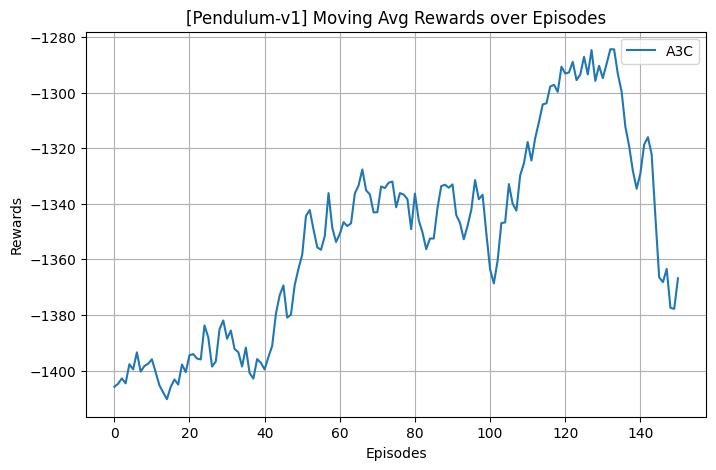

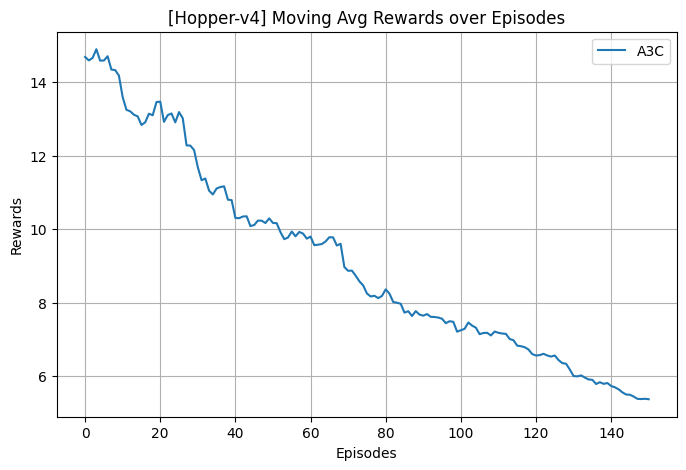

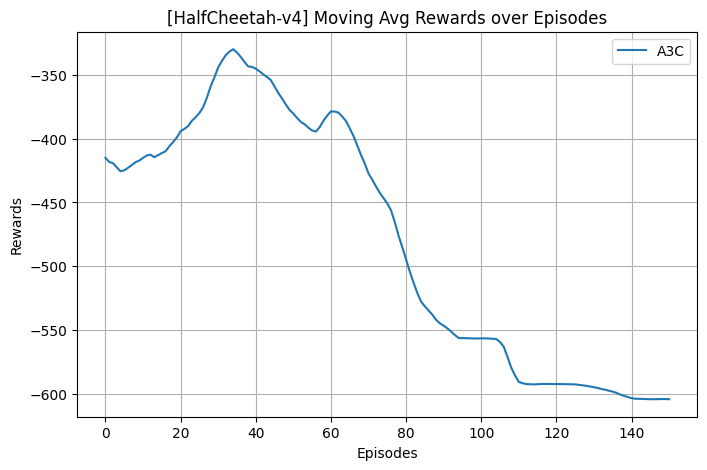

In [ ]:
# Run A3C on all 3 environments
a3c_all_results = {}
env_names = ['Pendulum-v1', 'Hopper-v4', 'HalfCheetah-v4']

if __name__ == "__main__":
    for env_name in env_names:
        rewards = train_a3c(env_id=env_name)
        a3c_all_results[env_name] = {"Rewards": {"A3C": [rewards]}}


plotResults(a3c_all_results, env_names)

## A3C Questions [$10 \times 3 = 30$ marks]

### Q1. Why does A3C use asynchronous updates, and what benefit does this provide over synchronous (A2C) updates?


### Q2. What is the "stale gradient" problem in A3C and how does it affect learning?


### Q3. Compare A3C with DQN in terms of memory requirements and training paradigm.




# Advantange Actor-Critic (A2C) [50 marks]
<a id="a2c"></a>

A2C is the synchronous, deterministic variant of A3C. Instead of using asynchronous workers, A2C waits for all parallel workers to finish their rollouts before performing a single gradient update. This makes it simpler to implement and often equally effective.

**Key ideas:**
- Uses an Actor-Critic architecture: the actor outputs a policy $\pi(a|s)$ and the critic estimates $V(s)$.
- The advantage $A(s,a) = R_t - V(s_t)$ (or using GAE) is used to reduce variance in the policy gradient.
- Multiple environments run in parallel (vectorized) and all updates are synchronous.
- The loss combines: policy gradient loss, value loss, and an entropy bonus for exploration.

**Policy Gradient with Advantage:**
$$\nabla_\theta J(\theta) = \mathbb{E}\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot A(s_t, a_t)\right]$$

Implement the A2C agent using the class structure below.

```
class A2CAgent(nn.Module):
    def __init__(self, envs)
    def get_value(self, x)
    def get_action_and_value(self, x, action=None)

def train_a2c(env_id, seed, ...)
```


In [ ]:
# Import all the required libraries
from torch.distributions import Categorical, Normal
import torch.nn.functional as F
import time

In [63]:
# ======================================================================
# A2C Hyperparameters
# ======================================================================

a2c_gym_id = "HalfCheetah-v4"     # Environment name
a2c_learning_rate = 2e-4
a2c_seed = 333

a2c_total_timesteps = 100_000
a2c_num_envs = 4
a2c_num_steps = 200

a2c_gamma = 0.99
a2c_gae_lambda = 0.96
a2c_use_gae = True

a2c_ent_coef = 0.001
a2c_vf_coef = 0.5
a2c_max_grad_norm = 0.5
a2c_norm_adv = True

# Derived parameter
a2c_batch_size = a2c_num_envs * a2c_num_steps

print(
    f"A2C: {a2c_total_timesteps // a2c_batch_size} gradient updates on {a2c_total_timesteps}"
)

A2C: 125 gradient updates on 100000


In [64]:
# ======================================================================
# A2C Agent Network
# ======================================================================
# This class defines the architecture for an Advantage Actor-Critic (A2C) agent.
# A2C has two parts:
# 1. A critic that estimates the value of a state (V(s)).
# 2. An actor that outputs a probability distribution over actions.
# You will create separate networks for the actor and the critic.

class A2CAgent(nn.Module):
    def __init__(self, env):
        # Initialize the A2C agent.
        # Tasks:
        # - Determine the dimensions of the observation space.
        # - Determine the number of possible actions.
        # - Create the critic network (takes state, outputs V(s)).
        # - Create the actor network (takes state, outputs action logits).

        # Your code goes here
        super(A2CAgent, self).__init__()
        self.env = env
        self.obs_dim = env.observation_space.shape[0]
        self.is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
        self.act_dim = env.action_space.n if self.is_discrete else env.action_space.shape[0]

        self.hDim = [64, 64]
        self.actor_network = createPolicyNetwork(self.obs_dim, self.act_dim, hDim=self.hDim)
        self.critic_network = createValueNetwork(self.obs_dim, 1, hDim=self.hDim)

        if not self.is_discrete:
            self.actor_log_std = nn.Parameter(torch.zeros(self.act_dim))

        self.initBookKeeping()

    def initBookKeeping(self):
        self.train_rewards = []
        self.eval_rewards = []
        self.train_time = []
        self.total_steps = []
        self.wallclock_time = []
        self.start_time = time.time()

    def performBookKeeping(self, train=True):
        if train:
            self.train_time.append(time.time() - self.start_time)
        else:
            self.wallclock_time.append(time.time() - self.start_time)


    def get_value(self, x):
        """Return the value of a state from the critic network."""
        # Your code goes here
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.critic_network(x)

    def get_action_and_value(self, x, action=None):
        """
        Get an action from the actor and value from the critic.
        Tasks:
        - Use the actor network to produce logits over actions.
        - Convert logits into a probability distribution.
        - Sample an action from the distribution (if action is not provided).
        - Compute the log probability of the chosen action.
        - Compute the entropy of the distribution (helps with exploration).
        - Get the value of the state from the critic.

        Returns: action, log_prob, entropy, value
        """
        # Your code goes here
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        value = self.get_value(x)

        if self.is_discrete:
            logits = self.actor_network(x)
            dist = torch.distributions.Categorical(logits=logits)
            if action is None:
                action = dist.sample()
            else:
                action = action.long().squeeze()
            log_prob = dist.log_prob(action)
            entropy = dist.entropy()

        else:
            mu = self.actor_network(x)
            log_std = torch.clamp(self.actor_log_std, -20, 2)
            std = log_std.exp().expand_as(mu)
            dist = torch.distributions.Normal(mu, std)
            if action is None:
                action = dist.sample()
            else:
                action = action.float()
            log_prob = dist.log_prob(action).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1)

        return action, log_prob, entropy, value

In [65]:
def evaluate_policy(agent, env_id, episodes=5):
    env = gym.make(env_id)
    rewards = []

    for _ in range(episodes):
        s, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            with torch.no_grad():
                action, _, _, _ = agent.get_action_and_value(s)

            # Handle action properly for both discrete and continuous
            if agent.is_discrete:
                action = action.item()
            else:
                action = action.squeeze(0).cpu().numpy()
                # Clip to environment bounds
                action = np.clip(action, env.action_space.low, env.action_space.high)

            s, r, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += r

        rewards.append(total_reward)

    return np.mean(rewards)

In [66]:
# ======================================================================
# A2C Worker + Training Loop (multiprocessing version)
# ======================================================================
# A2C is the SYNCHRONOUS counterpart to A3C:
#   - Worker processes each run their own environment and collect rollouts.
#   - After each rollout, workers WAIT at a barrier (synchronous).
#   - The main process computes GAE and does a SINGLE gradient update.
#   - A second barrier signals workers that weights have been updated.
# This barrier-based synchronisation is the key difference from A3C.
# ======================================================================

def a2c_worker(worker_id, global_agent,
               env_id, seed, num_steps, num_updates,
               shared_obs, shared_actions, shared_logprobs,
               shared_rewards, shared_dones, shared_values,
               shared_next_obs, shared_next_done,
               collect_barrier, update_barrier, ep_queue):
    """
    A2C worker process.  Collects rollouts into shared memory buffers,
    then waits at a barrier for the main process to do a centralised update.

    Unlike A3C, this worker NEVER computes gradients or calls optimizer.step().
    The main process owns the gradient update exclusively.
    """

    #Your code goes here
    env = gym.make(env_id)
    env.reset(seed=seed + worker_id)
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)

    s, _ = env.reset()
    s = torch.tensor(s, dtype=torch.float32)

    for _ in range(num_updates):
        total_reward = 0.0
        ep_count = 0

        for step in range(num_steps):
            with torch.no_grad():
                action, logprob, _, value = global_agent.get_action_and_value(s.unsqueeze(0))

            # Handle action for environment step
            if is_discrete:
                action_np = action.item()
                # Store as float in shared memory (will convert back in main)
                action_store = action.float()
            else:
                action_np = action.squeeze(0).cpu().numpy()
                # IMPORTANT: Tanh squashing or clipping to ensure bounds
                action_np = np.tanh(action_np)  # Ensure [-1, 1] then scale
                action_np = action_np * env.action_space.high
                action_np = np.clip(action_np, env.action_space.low, env.action_space.high)
                action_store = action.squeeze(0)

            s_next, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated
            total_reward += reward

            # Store in shared buffers
            shared_obs[worker_id, step] = s
            shared_actions[worker_id, step] = action_store
            shared_logprobs[worker_id, step] = logprob
            shared_rewards[worker_id, step] = reward
            shared_dones[worker_id, step] = float(done)
            shared_values[worker_id, step] = value.squeeze(0)

            s = torch.tensor(s_next, dtype=torch.float32)

            if done:
                ep_queue.put(total_reward)
                total_reward = 0.0
                ep_count += 1
                s, _ = env.reset()
                s = torch.tensor(s, dtype=torch.float32)

        # Bootstrap from last state
        shared_next_obs[worker_id] = s
        shared_next_done[worker_id] = float(done)

        # Wait for all workers to finish collection
        collect_barrier.wait()
        # Wait for main process to finish update
        update_barrier.wait()

    env.close()


def train_a2c(env_id=a2c_gym_id, seed=a2c_seed, total_timesteps=a2c_total_timesteps,
              num_envs=a2c_num_envs, num_steps=a2c_num_steps, lr=a2c_learning_rate,
              gamma=a2c_gamma, gae_lambda=a2c_gae_lambda, use_gae=a2c_use_gae,
              ent_coef=a2c_ent_coef, vf_coef=a2c_vf_coef,
              max_grad_norm=a2c_max_grad_norm, norm_adv=a2c_norm_adv):
    """
    A2C training with torch.multiprocessing.

    - num_envs worker processes each run their own environment.
    - Workers collect num_steps of experience into shared memory buffers.
    - A barrier synchronises: all workers must finish before the update.
    - The main process computes GAE advantages and does ONE gradient step.
    - A second barrier signals workers that weights have been updated.
    """

    #Your code goes here
    env = gym.make(env_id)
    obs_dim = env.observation_space.shape[0]
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)

    if is_discrete:
        act_dim = 1
    else:
        act_dim = env.action_space.shape[0]

    global_agent = A2CAgent(env)
    global_agent.share_memory()

    optimizer = SharedAdam(global_agent.parameters(), lr=lr)

    num_updates = total_timesteps // (num_envs * num_steps)
    batch_size = num_envs * num_steps
    minibatch_size = batch_size // 4  # 4 mini-batches per update

    # Shared buffers - actions as float (will cast to long for discrete in forward)
    shared_obs = torch.zeros(num_envs, num_steps, obs_dim).share_memory_()
    shared_actions = torch.zeros(num_envs, num_steps, act_dim).share_memory_()
    shared_logprobs = torch.zeros(num_envs, num_steps).share_memory_()
    shared_rewards = torch.zeros(num_envs, num_steps).share_memory_()
    shared_dones = torch.zeros(num_envs, num_steps).share_memory_()
    shared_values = torch.zeros(num_envs, num_steps).share_memory_()

    shared_next_obs = torch.zeros(num_envs, obs_dim).share_memory_()
    shared_next_done = torch.zeros(num_envs).share_memory_()

    collect_barrier = mp.Barrier(num_envs + 1)
    update_barrier = mp.Barrier(num_envs + 1)
    ep_queue = mp.Queue()

    # Logging
    train_rewards = []
    eval_rewards = []
    train_times = []
    total_steps_list = []
    wallclock_times = []

    total_steps = 0  # Cumulative counter
    start_time = time.time()

    # Start workers
    processes = []
    for i in range(num_envs):
        p = mp.Process(target=a2c_worker, args=(
            i, global_agent,
            env_id, seed, num_steps, num_updates,
            shared_obs, shared_actions, shared_logprobs,
            shared_rewards, shared_dones, shared_values,
            shared_next_obs, shared_next_done,
            collect_barrier, update_barrier, ep_queue
        ))
        p.start()
        processes.append(p)

    # Training loop
    for update in range(num_updates):
        collect_barrier.wait()

        # Update cumulative steps (FIXED: was overwriting before)
        steps_this_update = num_envs * num_steps
        total_steps += steps_this_update

        # Compute GAE
        with torch.no_grad():
            next_value = global_agent.get_value(shared_next_obs).squeeze(-1)

        advantages = torch.zeros_like(shared_rewards)
        lastgaelam = torch.zeros(num_envs)

        for t in reversed(range(num_steps)):
            if t == num_steps - 1:
                nextnonterminal = 1.0 - shared_next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - shared_dones[:, t + 1]
                nextvalues = shared_values[:, t + 1]

            delta = shared_rewards[:, t] + gamma * nextvalues * nextnonterminal - shared_values[:, t]

            if use_gae:
                advantages[:, t] = lastgaelam = delta + gamma * gae_lambda * nextnonterminal * lastgaelam
            else:
                advantages[:, t] = delta

        returns = advantages + shared_values

        # Flatten
        b_obs = shared_obs.reshape(-1, obs_dim)
        b_actions = shared_actions.reshape(-1, act_dim)
        b_old_logprobs = shared_logprobs.reshape(-1)
        b_advantages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)
        b_values_old = shared_values.reshape(-1)

        if norm_adv:
            b_advantages = (b_advantages - b_advantages.mean()) / (b_advantages.std() + 1e-8)

        # Mini-batch SGD (A2C typically does multiple epochs)
        batch_inds = np.arange(batch_size)
        num_epochs = 3

        for _ in range(num_epochs):
            np.random.shuffle(batch_inds)

            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = batch_inds[start:end]

                # Forward pass
                _, new_logprob, entropy, value = global_agent.get_action_and_value(
                    b_obs[mb_inds],
                    b_actions[mb_inds].long() if is_discrete else b_actions[mb_inds]
                )
                value = value.view(-1)

                # Losses
                policy_loss = -(b_advantages[mb_inds] * new_logprob).mean()
                value_loss = ((b_returns[mb_inds] - value) ** 2).mean()
                entropy_loss = entropy.mean()

                loss = policy_loss + vf_coef * value_loss - ent_coef * entropy_loss

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(global_agent.parameters(), max_grad_norm)
                optimizer.step()

        update_barrier.wait()

        # Logging (FIXED: proper handling of ep_r)
        train_times.append(time.time() - start_time)
        total_steps_list.append(total_steps)

        # Collect episode rewards
        ep_rewards_this_update = []
        while not ep_queue.empty():
            try:
                ep_r = ep_queue.get_nowait()
                train_rewards.append(ep_r)
                ep_rewards_this_update.append(ep_r)
            except:
                break

        # Evaluation
        if update % 10 == 0:
            eval_r = evaluate_policy(global_agent, env_id)
            eval_rewards.append(eval_r)
            wallclock_times.append(time.time() - start_time)

            # Use average of collected episodes or last known
            avg_train_r = np.mean(ep_rewards_this_update) if ep_rewards_this_update else (
                np.mean(train_rewards[-10:]) if train_rewards else 0
            )

            print(f"Update {update:3d} | Steps {total_steps:6d} | "
                  f"Train: {avg_train_r:8.2f} | Eval: {eval_r:8.2f} | "
                  f"Loss: {loss.item():.3f}")

    # Cleanup
    for p in processes:
        p.join()

    return train_rewards, eval_rewards, train_times, total_steps_list, wallclock_times

--------------------------------------------------
Running Pendulum-v1
Update   0 | Steps    800 | Train: -1294.72 | Eval: -1420.07 | Loss: 7445.787
Update  10 | Steps   8800 | Train: -1278.68 | Eval: -1317.46 | Loss: 7596.839
Update  20 | Steps  16800 | Train: -1270.55 | Eval: -1191.92 | Loss: 7281.122
Update  30 | Steps  24800 | Train: -1286.30 | Eval: -1142.96 | Loss: 6540.818
Update  40 | Steps  32800 | Train: -1347.04 | Eval: -1144.32 | Loss: 7485.462
Update  50 | Steps  40800 | Train: -1346.37 | Eval: -1278.71 | Loss: 7015.041
Update  60 | Steps  48800 | Train: -1255.02 | Eval: -1312.44 | Loss: 6263.141
Update  70 | Steps  56800 | Train: -1160.70 | Eval: -1270.06 | Loss: 5462.656
Update  80 | Steps  64800 | Train: -1333.44 | Eval: -1352.67 | Loss: 6888.643
Update  90 | Steps  72800 | Train: -1277.86 | Eval: -1380.35 | Loss: 6212.673
Update 100 | Steps  80800 | Train: -1511.67 | Eval: -1538.13 | Loss: 6689.804
Update 110 | Steps  88800 | Train: -1273.58 | Eval: -1496.90 | Loss: 68

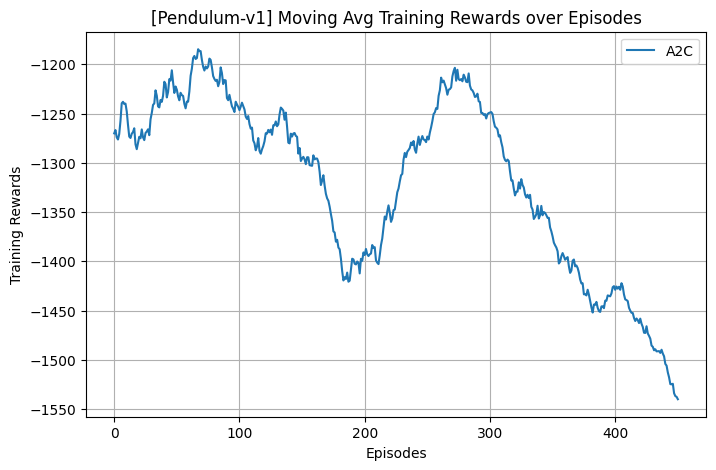

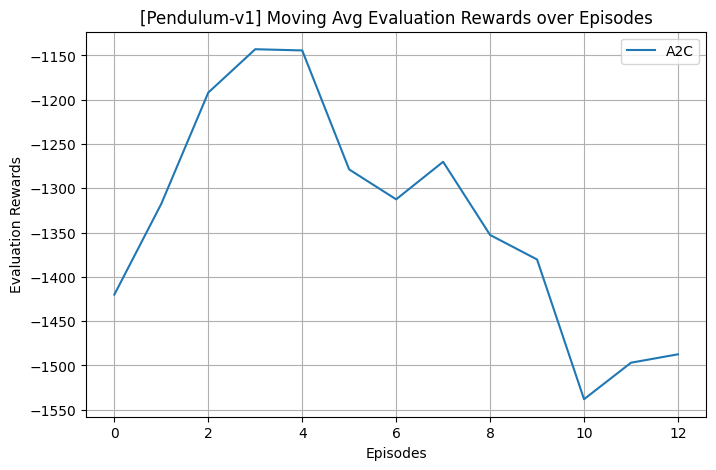

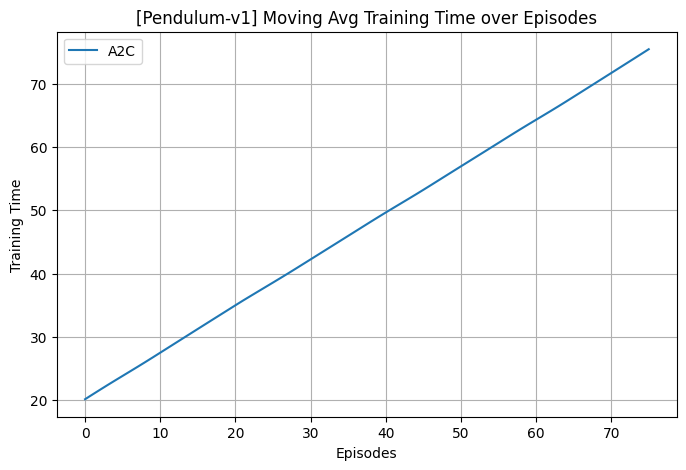

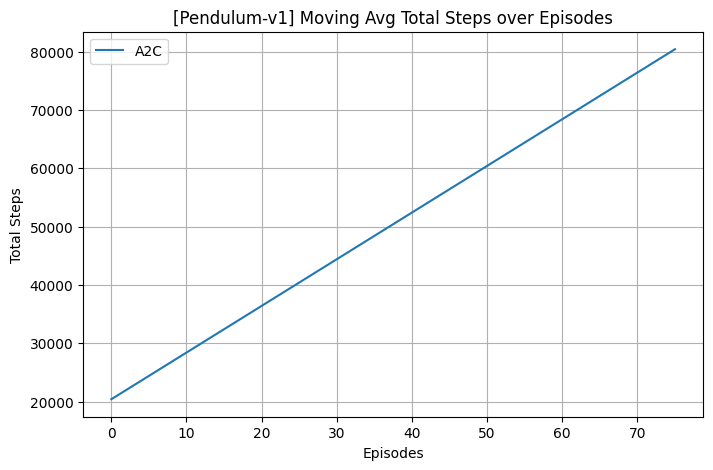

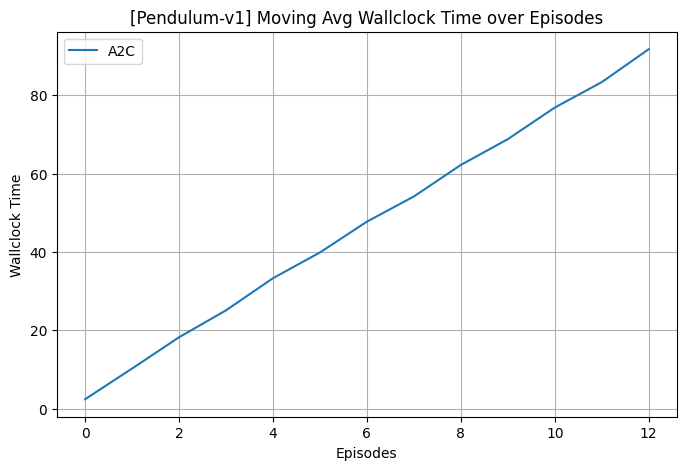

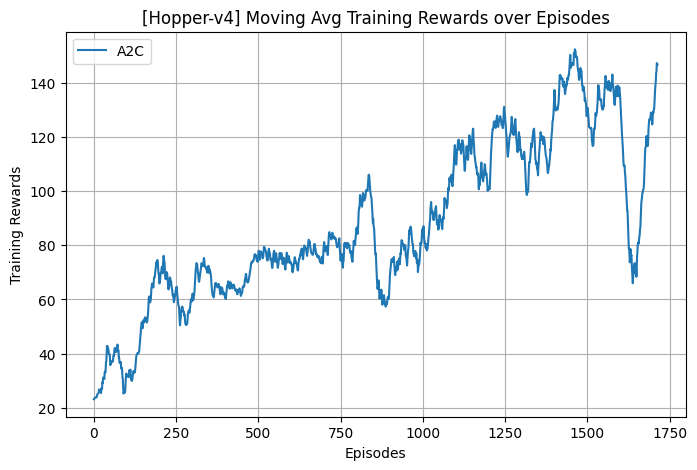

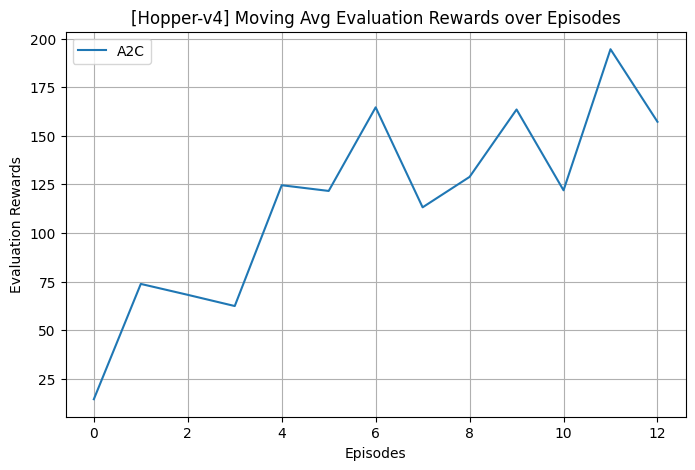

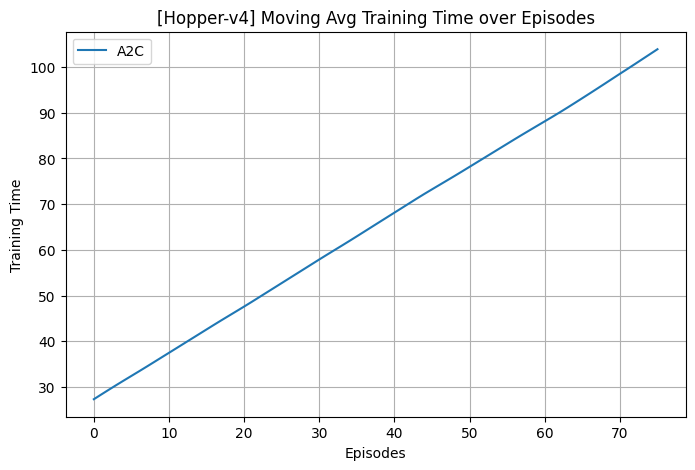

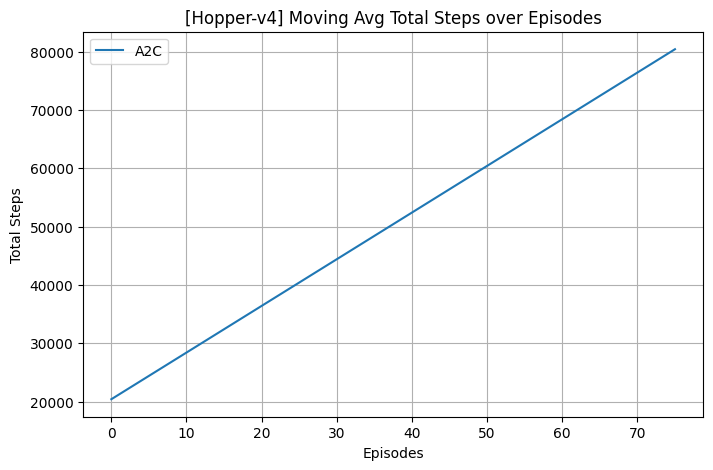

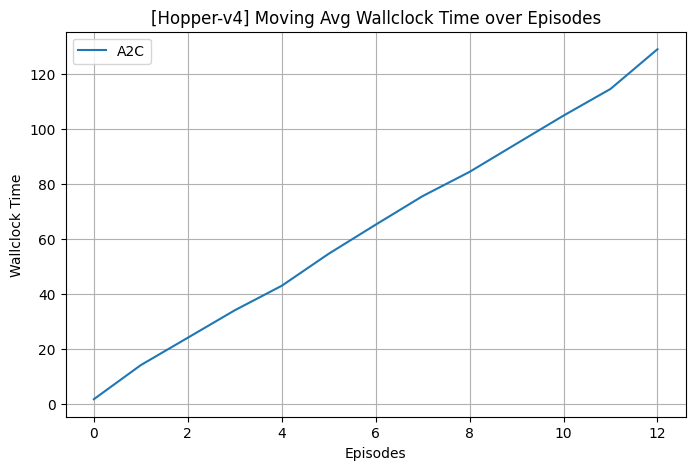

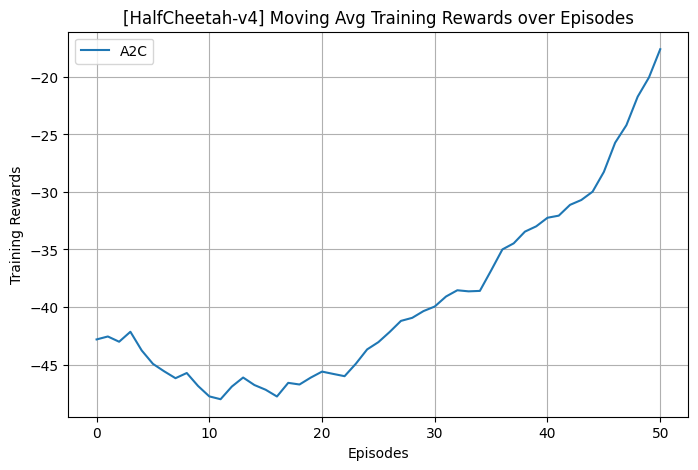

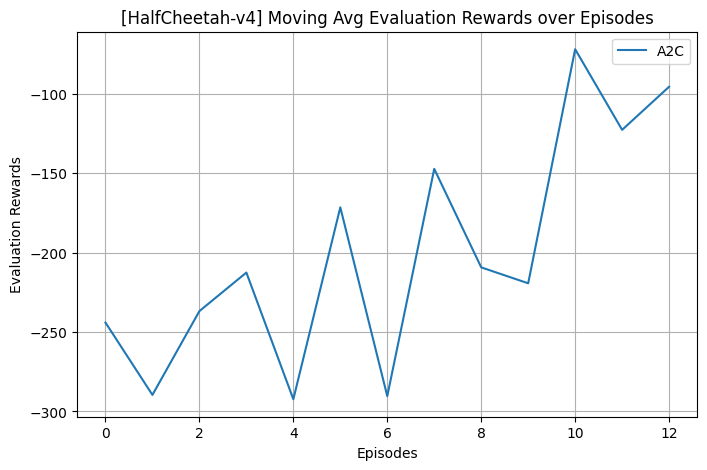

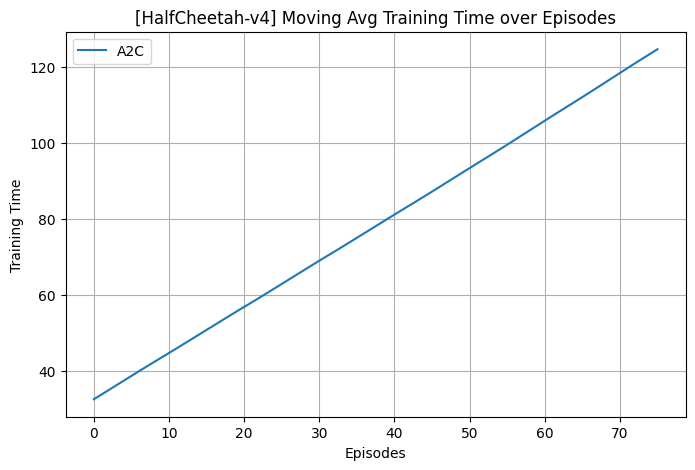

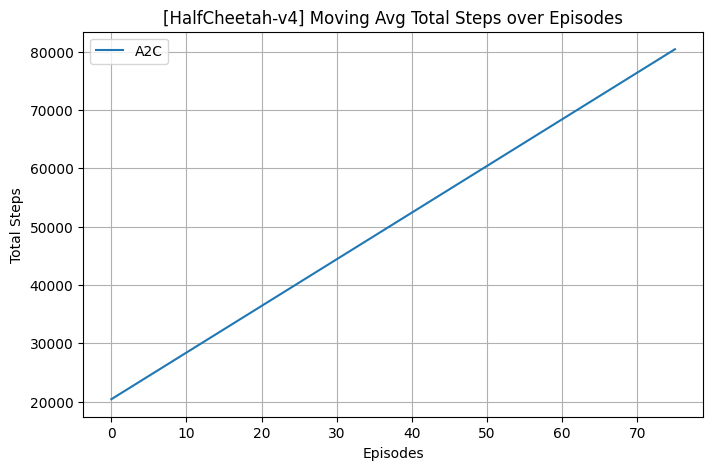

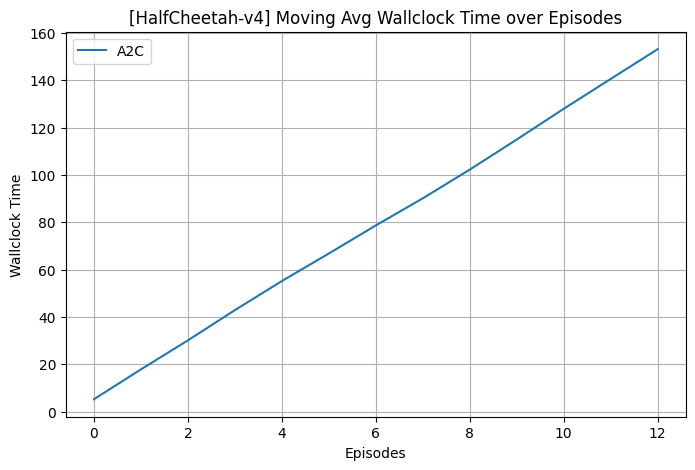

In [67]:
# Run the A2C training on multiple environments and store the results.
# Iterate through the environments: 'Pendulum-v1', 'Hopper-v4', and 'HalfCheetah-v4'.

# For each environment, print a header so that the training progress is clear.

# Call the function train_a2c() with the environment name and a total training
# Store the returned training results in a dictionary.


env_names = ["Pendulum-v1", "Hopper-v4", "HalfCheetah-v4"]
a2c_plot_config = {}

for env_id in env_names:
    print(f"-" * 50)
    print(f"Running {env_id}")
    train_rewards, eval_rewards, train_times, total_steps_list, wallclock_times = train_a2c(env_id=env_id)

    a2c_plot_config[env_id] = {
        "Training Rewards": {"A2C": [train_rewards]},
        "Evaluation Rewards": {"A2C": [eval_rewards]},
        "Training Time": {"A2C": [train_times]},
        "Total Steps": {"A2C": [total_steps_list]},
        "Wallclock Time": {"A2C": [wallclock_times]}
      }


# Plot the learning curve:
#   - First plot the raw returns with a light transparency.
#   - Then compute a moving-average smoothing using numpy convolution
#     to show a cleaner trend of the learning progress.


# Display the plot for each environment.
plotResults(a2c_plot_config, env_names)

## A2C Questions [$10 \times 4 = 40$ marks ]

### Q1. What is the advantage function in A2C and why is it used instead of raw returns?



### Q2. How does A2C differ from REINFORCE?



### Q3. Why does A2C use RMSprop instead of Adam, and does the choice matter?



### Q4. Experiment: Compare A2C with different numbers of parallel environments (num_envs = 1, 4, 8, 16). What do you observe?



# Generalized Advantage Estimation (GAE) [50 marks]
<a id="gae"></a>

GAE (Schulman et al., 2016) provides a principled way to balance bias and variance in advantage estimation through a single parameter $\lambda \in [0, 1]$.

**The core idea:**

The 1-step advantage (TD error) is: $\delta_t^V = r_t + \gamma V(s_{t+1}) - V(s_t)$

The GAE advantage is an exponentially-weighted average of multi-step advantages:
$$\hat{A}_t^{\text{GAE}(\gamma, \lambda)} = \sum_{l=0}^{\infty} (\gamma \lambda)^l \delta_{t+l}^V$$

This can be computed recursively:
$$\hat{A}_t = \delta_t + \gamma \lambda \hat{A}_{t+1}$$

**Special cases:**
- $\lambda = 0$: GAE reduces to the 1-step TD advantage $\delta_t^V$ → **low variance, high bias**
- $\lambda = 1$: GAE reduces to the full Monte Carlo advantage → **high variance, low bias**
- $0 < \lambda < 1$: Smooth interpolation between the two extremes

Below we implement a standalone GAE module and demonstrate how different values of $\lambda$ affect learning performance.


In [69]:
# ======================================================================
# GAE Implementation (standalone module)
# ======================================================================

def compute_gae(rewards, values, dones, next_value, gamma, gae_lambda):
    """
    Computes Generalized Advantage Estimation.

    Args:
        rewards    : tensor of shape (T, num_envs) - rewards at each timestep
        values     : tensor of shape (T, num_envs) - V(s_t) predictions
        dones      : tensor of shape (T, num_envs) - done flags
        next_value : tensor of shape (1, num_envs) - V(s_{T}) bootstrap value
        gamma      : discount factor
        gae_lambda : GAE lambda parameter (0=TD, 1=MC)

    Returns:
        advantages : tensor of shape (T, num_envs)
        returns    : tensor of shape (T, num_envs)
    """

    #Your code goes here
    if not isinstance(rewards, torch.Tensor):
        rewards = torch.tensor(rewards, dtype=torch.float32)
    if not isinstance(values, torch.Tensor):
        values = torch.tensor(values, dtype=torch.float32)
    if not isinstance(dones, torch.Tensor):
        dones = torch.tensor(dones, dtype=torch.float32)
    if not isinstance(next_value, torch.Tensor):
        next_value = torch.tensor(next_value, dtype=torch.float32)

    # Handle dimensions
    if rewards.dim() == 1:
        rewards = rewards.unsqueeze(-1)  # (T, 1)
        values = values.unsqueeze(-1) if values.dim() == 1 else values
        dones = dones.unsqueeze(-1) if dones.dim() == 1 else dones
        squeeze_output = True
    else:
        squeeze_output = False

    T, num_envs = rewards.shape
    advantages = torch.zeros_like(rewards)

    # Initialize with next value
    next_advantage = 0

    # Compute GAE backwards
    for t in reversed(range(T)):
        if t == T - 1:
            next_value_t = next_value.view(1, -1)
            next_non_terminal = 1.0 - dones[t]
        else:
            next_value_t = values[t + 1]
            next_non_terminal = 1.0 - dones[t]

        # TD error: delta_t = r_t + gamma * V(s_{t+1}) * (1 - done) - V(s_t)
        delta = rewards[t] + gamma * next_value_t * next_non_terminal - values[t]

        # GAE: A_t = delta_t + gamma * lambda * (1 - done) * A_{t+1}
        advantages[t] = delta + gamma * gae_lambda * next_non_terminal * next_advantage
        next_advantage = advantages[t]

    # Returns = advantages + values (TD(lambda) targets)
    returns = advantages + values

    if squeeze_output:
        return advantages.squeeze(-1), returns.squeeze(-1)
    return advantages, returns

In [70]:
# ==============================================================
# GAE Visualization (Synthetic Example)
# ==============================================================

# Demonstrate how GAE behaves for different λ values using
# a small synthetic reward and value sequence.

# Generate synthetic rewards, values, and a done signal.
# Assume the episode terminates at a specific timestep.

# For multiple λ values (e.g., 0 → 1), compute the advantages
# using the compute_gae() function.

# Plot 1:
# Visualize the advantage estimates across timesteps for
# different λ values to observe how smoothing changes.

# Plot 2:
# Evaluate the bias–variance trade-off:
#   • Compute the variance of advantages for λ ∈ [0,1]
#   • Also compute the mean absolute advantage
# Plot both curves against λ.

# Add labels, legend, grid, and export the figure as
# 'gae_lambda_analysis.pdf'.

In [71]:
def create_synthetic_data(T=50, seed=42):
    """Create synthetic trajectory for visualization"""
    np.random.seed(seed)

    rewards = np.zeros(T)
    rewards[10:15] = 1.0
    rewards[25:30] = 1.5
    rewards[40:45] = 2.0
    rewards += np.random.randn(T) * 0.1

    values = np.zeros(T)
    for i in range(T):
        future_rewards = sum([rewards[min(i+k, T-1)] * (0.95 ** k) for k in range(10)])
        values[i] = future_rewards * 0.9 + np.random.randn() * 0.05

    dones = np.zeros(T)
    dones[39] = 1.0

    return torch.tensor(rewards, dtype=torch.float32), \
           torch.tensor(values, dtype=torch.float32), \
           torch.tensor(dones, dtype=torch.float32)


def prepare_gae_visualization_data():
    """
    Prepares data for plotResults showing GAE behavior.
    Returns quantityDict for plotResults.
    """
    rewards, values, dones = create_synthetic_data(T=50)
    gamma = 0.95
    next_value = torch.tensor(0.0)

    lambda_values = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]

    # Structure: {"Synthetic": {"GAE Advantages": {"λ=0.0": [[...]], ...}}}
    quantityDict = {"Synthetic Environment": {"GAE Advantage Estimates": {}}}

    for lam in lambda_values:
        advantages, returns = compute_gae(rewards, values, dones, next_value, gamma, lam)
        # Wrap in list to match "list of seeds" format (single seed here)
        quantityDict["Synthetic Environment"]["GAE Advantage Estimates"][f"λ={lam}"] = [
            [advantages.numpy()]  # Double list: seeds -> data
        ]

    return quantityDict, lambda_values


def visualize_gae_bias_variance():
    """Creates bias-variance plot and saves PDF"""
    rewards, values, dones = create_synthetic_data(T=50)
    gamma = 0.95
    next_value = torch.tensor(0.0)

    lambda_range = np.linspace(0, 1, 21)
    variances = []
    mean_abs_adv = []

    for lam in lambda_range:
        advantages, _ = compute_gae(rewards, values, dones, next_value, gamma, lam)
        variances.append(advantages.var().item())
        mean_abs_adv.append(advantages.abs().mean().item())

    # Save analysis plot as PDF
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(lambda_range, variances, 'b-o', linewidth=2, markersize=6)
    ax1.set_xlabel('λ (GAE Parameter)', fontsize=12)
    ax1.set_ylabel('Variance of Advantages', fontsize=12)
    ax1.set_title('Bias-Variance Trade-off: Variance', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.plot(lambda_range, mean_abs_adv, 'r-s', linewidth=2, markersize=6)
    ax2.set_xlabel('λ (GAE Parameter)', fontsize=12)
    ax2.set_ylabel('Mean Absolute Advantage', fontsize=12)
    ax2.set_title('Bias-Variance Trade-off: Magnitude', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('gae_lambda_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('gae_lambda_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    return lambda_range, variances, mean_abs_adv

Generating GAE synthetic visualization
Plotting GAE advantages (Moving Average).


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


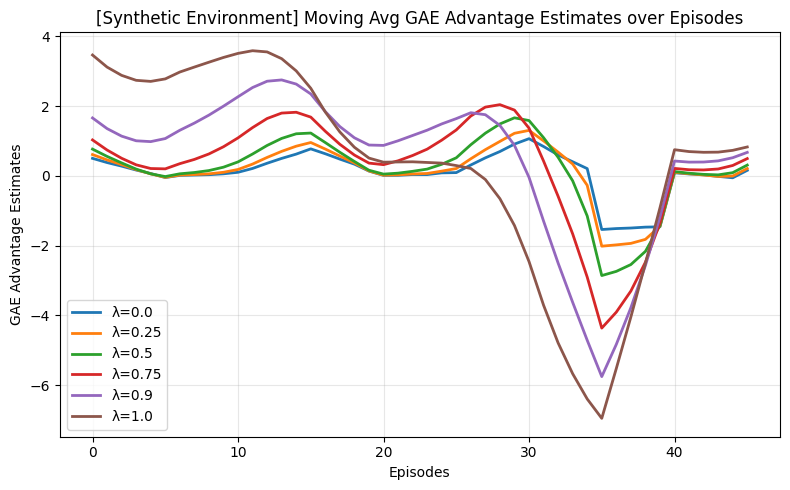

Plotting GAE advantages (Raw)


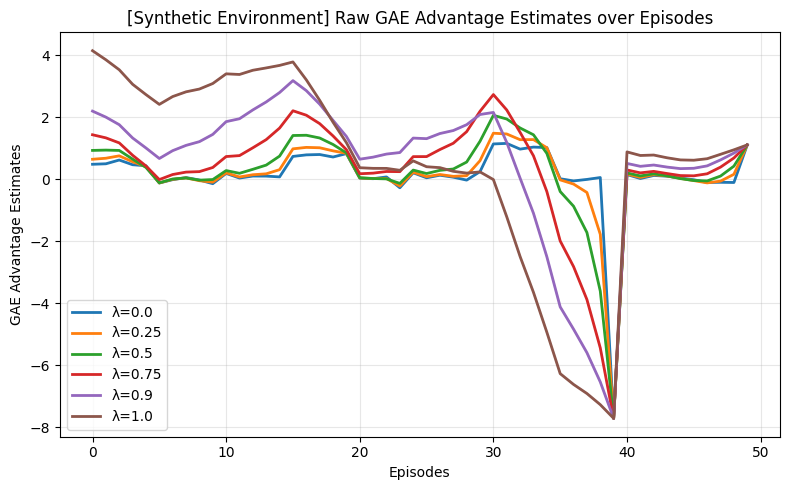


Generating bias-variance analysis


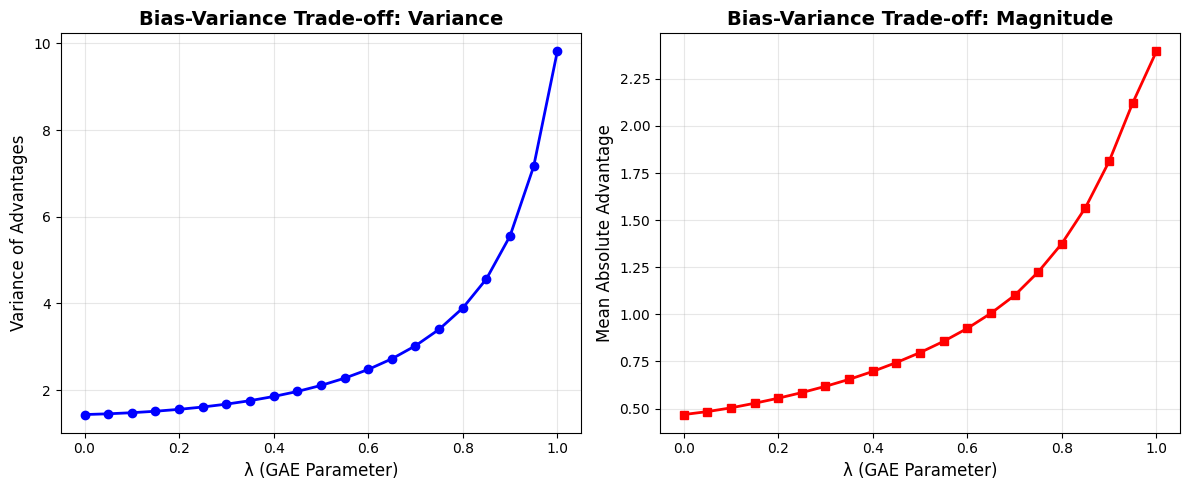

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 [1.4352689981460571,
  1.452782392501831,
  1.4782295227050781,
  1.5122385025024414,
  1.5556831359863281,
  1.609718680381775,
  1.6758317947387695,
  1.7559105157852173,
  1.8523385524749756,
  1.9681274890899658,
  2.1071038246154785,
  2.2741968631744385,
  2.4759092330932617,
  2.721161365509033,
  3.0229411125183105,
  3.4017281532287598,
  3.8930068016052246,
  4.5644025802612305,
  5.555587291717529,
  7.160648822784424,
  9.813689231872559],
 [0.4684261381626129,
  0.48404091596603394,
  0.5039127469062805,
  0.5283382534980774,
  0.5551425814628601,
  0.585048258304596,
  0.6182122826576233,
  0.6550951600074768,
  0.6971125602722168,
  0.7444071173667908,
  0.7971853613853455,
  0.8569976687431335,
  0.9255449175834656,
  1.0057499408721924,
  1.1003084182739258,
  1.2247473001480103,
  1.375441551208496,
  1.5664238929748535,
  1.

In [72]:
print("Generating GAE synthetic visualization")
gae_viz_data, lambdas = prepare_gae_visualization_data()

print("Plotting GAE advantages (Moving Average).")
plotResults(gae_viz_data, ["Synthetic Environment"], window=5, use_moving_avg=True)

print("Plotting GAE advantages (Raw)")
plotResults(gae_viz_data, ["Synthetic Environment"], use_moving_avg=False)

print("\nGenerating bias-variance analysis")
visualize_gae_bias_variance()

In [73]:
# GAE Lambda Sweep on all 3 environments
''' - Run A2C with different GAE λ values on multiple environments.
- For each environment (Pendulum, Hopper, HalfCheetah), train the agent
- using several λ values and store the training results for comparison.'''

# Your code goes here
def run_gae_sweep(env_names=['Pendulum-v1', 'Hopper-v4', 'HalfCheetah-v4'],
                  lambda_values=[0.0, 0.5, 0.95, 0.99, 1.0],
                  num_updates=100):
    """
    Run A2C with different GAE lambda values.
    Returns quantityDict for plotResults.
    """
    # Structure: {env: {metric: {lambda_agent: [[seed1], [seed2]]}}}
    sweep_results = {env: {"Training Rewards": {}, "Eval Rewards": {}} for env in env_names}

    for env_name in env_names:
        print(f"\n{'='*60}")
        print(f"GAE Sweep on {env_name}")
        print(f"{'='*60}")

        for lam in lambda_values:
            print(f"\nTraining with λ={lam}...")

            # Assuming train_a2c is available globally
            train_rewards, eval_rewards, _, _, _ = train_a2c(
                env_id=env_name,
                total_timesteps=num_updates * 2 * 500,
                gae_lambda=lam,
                num_envs=2,
                num_steps=500,
                use_gae=True
            )

            # Store as list of lists (single seed for now, can extend to multiple)
            agent_name = f"λ={lam}"
            sweep_results[env_name]["Training Rewards"][agent_name] = [[train_rewards]]
            sweep_results[env_name]["Eval Rewards"][agent_name] = [[eval_rewards]]

            print(f"  Final reward: {np.mean(train_rewards[-10:]):.2f}")

    return sweep_results


Running GAE Lambda Sweep...

GAE Sweep on Pendulum-v1

Training with λ=0.0...
Update   0 | Steps   1000 | Train: -1367.84 | Eval: -1351.87 | Loss: 28.487
Update  10 | Steps  11000 | Train: -1329.74 | Eval: -1226.16 | Loss: 27.219
Update  20 | Steps  21000 | Train: -1636.28 | Eval: -1527.75 | Loss: 30.504
Update  30 | Steps  31000 | Train: -1664.53 | Eval: -1639.64 | Loss: 31.390
Update  40 | Steps  41000 | Train: -1677.02 | Eval: -1617.61 | Loss: 28.888
Update  50 | Steps  51000 | Train: -1563.02 | Eval: -1575.59 | Loss: 24.096
Update  60 | Steps  61000 | Train: -1483.16 | Eval: -1538.56 | Loss: 20.748
Update  70 | Steps  71000 | Train: -1517.11 | Eval: -1524.43 | Loss: 18.466
Update  80 | Steps  81000 | Train: -1523.45 | Eval: -1454.15 | Loss: 32.191
Update  90 | Steps  91000 | Train: -1425.83 | Eval: -1487.75 | Loss: 13.820
  Final reward: -1331.84

Training with λ=0.5...
Update   0 | Steps   1000 | Train: -1321.10 | Eval: -1382.02 | Loss: 98.692
Update  10 | Steps  11000 | Train: -

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Update   0 | Steps   1000 | Train:     8.66 | Eval:     9.77 | Loss: 0.150
Update  10 | Steps  11000 | Train:    12.28 | Eval:    11.40 | Loss: 0.395
Update  20 | Steps  21000 | Train:    35.05 | Eval:    34.88 | Loss: 1.806
Update  30 | Steps  31000 | Train:    46.10 | Eval:    40.69 | Loss: 8.030
Update  40 | Steps  41000 | Train:    30.04 | Eval:    48.85 | Loss: 10.846
Update  50 | Steps  51000 | Train:    25.78 | Eval:    20.04 | Loss: 11.726
Update  60 | Steps  61000 | Train:    39.78 | Eval:    39.22 | Loss: 12.262
Update  70 | Steps  71000 | Train:    42.09 | Eval:    39.08 | Loss: 12.250
Update  80 | Steps  81000 | Train:    44.69 | Eval:    35.37 | Loss: 18.395
Update  90 | Steps  91000 | Train:    30.33 | Eval:    30.42 | Loss: 34.269
  Final reward: 49.59

Training with λ=0.5...
Update   0 | Steps   1000 | Train:    12.09 | Eval:    11.82 | Loss: 2.251
Update  10 | Steps  11000 | Train:    14.84 | Eval:    13.03 | Loss: 1.641
Update  20 | Steps  21000 | Train:    15.41 | Ev

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Update   0 | Steps   1000 | Train:     0.00 | Eval:  -299.97 | Loss: -0.749
Update  10 | Steps  11000 | Train:   -64.10 | Eval:  -231.39 | Loss: -1.058
Update  20 | Steps  21000 | Train:  -117.33 | Eval:  -334.23 | Loss: -0.502
Update  30 | Steps  31000 | Train:  -156.11 | Eval:  -347.43 | Loss: 0.114
Update  40 | Steps  41000 | Train:  -149.89 | Eval:  -445.18 | Loss: 1.020
Update  50 | Steps  51000 | Train:  -190.73 | Eval:  -392.45 | Loss: -0.305
Update  60 | Steps  61000 | Train:  -153.28 | Eval:  -408.03 | Loss: 0.708
Update  70 | Steps  71000 | Train:  -188.05 | Eval:  -475.79 | Loss: -0.099
Update  80 | Steps  81000 | Train:  -156.40 | Eval:  -338.26 | Loss: 0.751
Update  90 | Steps  91000 | Train:  -182.36 | Eval:  -551.68 | Loss: 0.384
  Final reward: -213.90

Training with λ=0.5...
Update   0 | Steps   1000 | Train:     0.00 | Eval:  -450.30 | Loss: 0.679
Update  10 | Steps  11000 | Train:  -147.61 | Eval:  -229.75 | Loss: 0.389
Update  20 | Steps  21000 | Train:   -86.32 | E

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


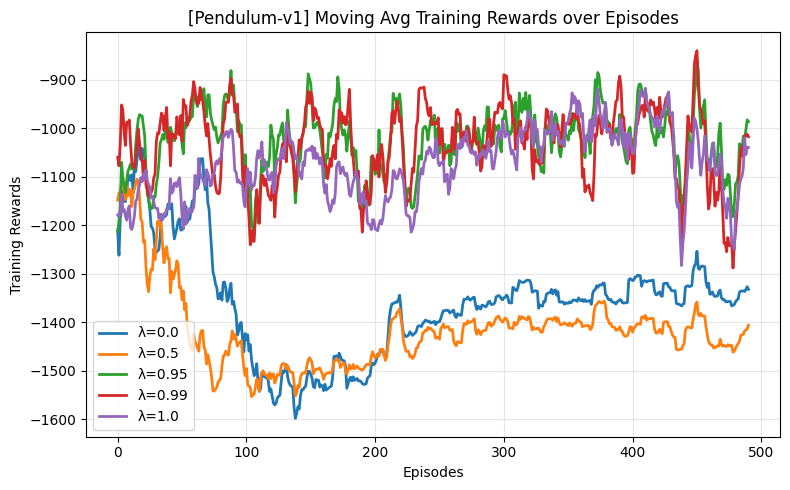

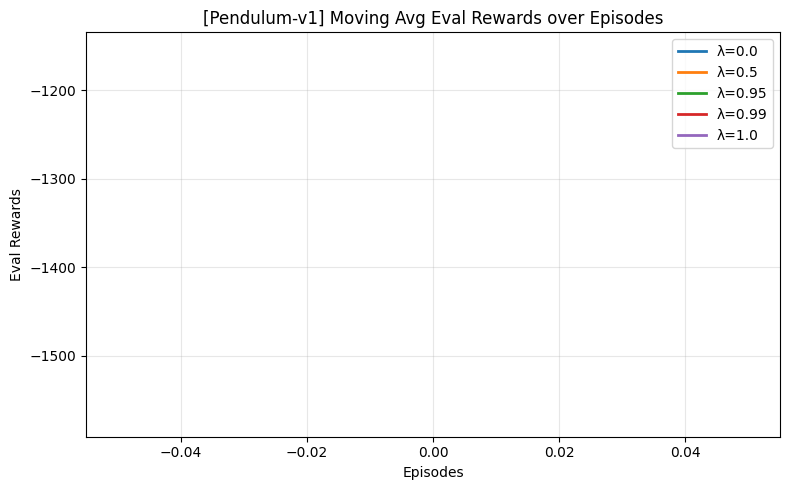

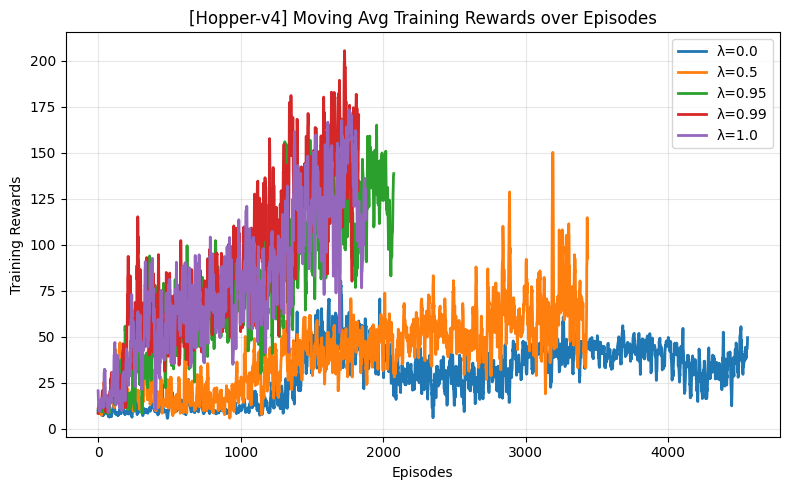

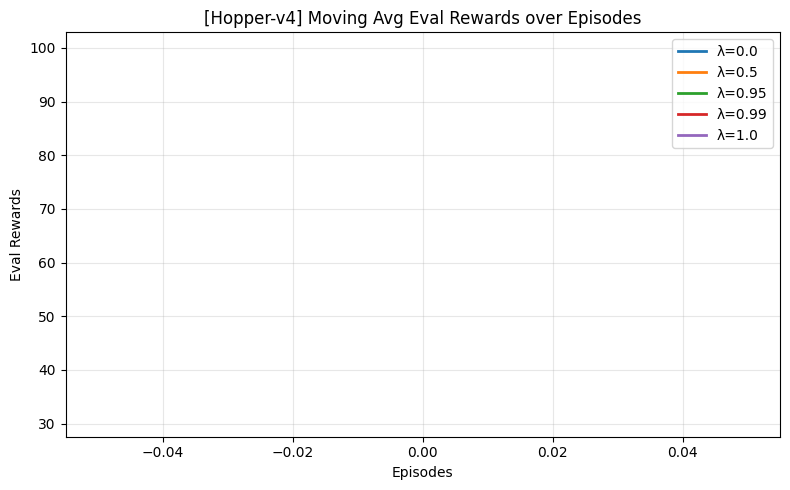

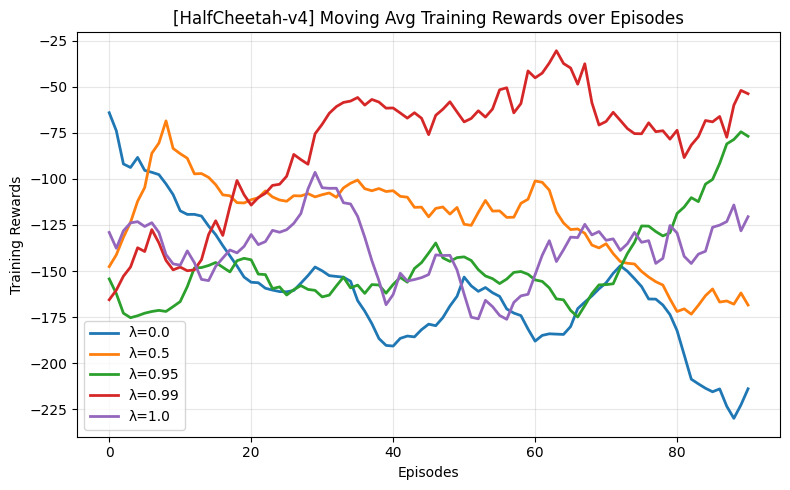

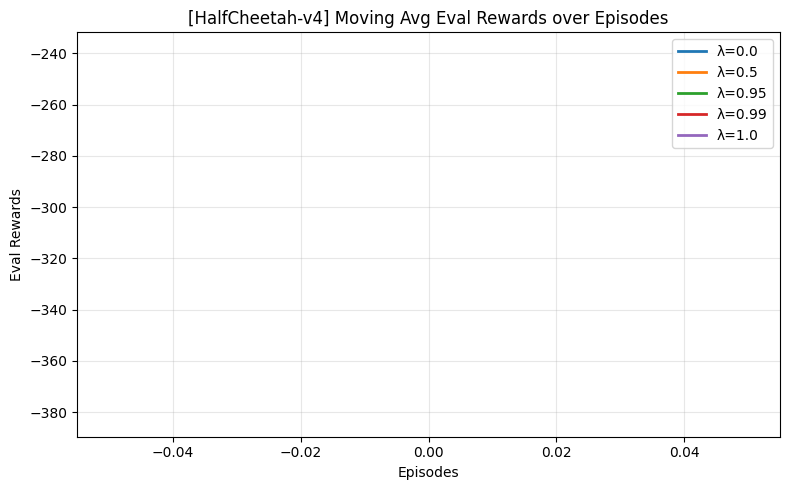

In [74]:

# GAE sweep plots for all environments

# Your code goes here
print("\nRunning GAE Lambda Sweep...")
sweep_data = run_gae_sweep()
plotResults(sweep_data, ["Pendulum-v1", "Hopper-v4", "HalfCheetah-v4"],
            window=10, use_moving_avg=True)


In [75]:
# A2C vs A3C comparison on all 3 environments

# Your code goes here
def compare_a2c_a3c(env_names=['Pendulum-v1', 'Hopper-v4', 'HalfCheetah-v4'],
                    num_episodes=100):
    """
    Compare A2C vs A3C on all environments.
    Returns quantityDict for plotResults.
    """
    comparison_results = {env: {"Training Rewards": {}, "Evaluation Rewards": {}}
                         for env in env_names}

    for env_name in env_names:
        print(f"\n{'='*60}")
        print(f"Comparing A2C vs A3C on {env_name}")
        print(f"{'='*60}")

        # Train A2C
        print("Training A2C...")
        a2c_train, a2c_eval, _, _, _ = train_a2c(
            env_id=env_name,
            total_timesteps=num_episodes * 2 * 500,
            num_envs=2,
            num_steps=500,
            gae_lambda=0.95
        )

        # Train A3C
        print("Training A3C...")
        a3c_rewards = train_a3c(
            env_id=env_name,
            num_workers=2,
            episodes_per_worker=num_episodes // 2,
            num_steps=20,
            gamma=0.99
        )

        # Store in format expected by plotResults
        comparison_results[env_name]["Training Rewards"]["A2C"] = [[a2c_train]]
        comparison_results[env_name]["Training Rewards"]["A3C"] = [[a3c_rewards]]
        comparison_results[env_name]["Evaluation Rewards"]["A2C"] = [[a2c_eval]]
        comparison_results[env_name]["Evaluation Rewards"]["A3C"] = [[]]  # A3C eval if available

        print(f"  A2C: {np.mean(a2c_train[-10:]):.2f}")
        print(f"  A3C: {np.mean(a3c_rewards[-10:]):.2f}")

    return comparison_results


Comparing A2C vs A3C...

Comparing A2C vs A3C on Pendulum-v1
Training A2C...
Update   0 | Steps   1000 | Train: -1355.58 | Eval: -1246.30 | Loss: 5367.320
Update  10 | Steps  11000 | Train: -1086.50 | Eval: -1294.67 | Loss: 3685.639
Update  20 | Steps  21000 | Train: -1128.03 | Eval: -1380.41 | Loss: 4197.073
Update  30 | Steps  31000 | Train:  -885.92 | Eval: -1051.94 | Loss: 2555.251
Update  40 | Steps  41000 | Train: -1361.36 | Eval: -1248.41 | Loss: 5418.012
Update  50 | Steps  51000 | Train: -1303.95 | Eval: -1109.75 | Loss: 4368.752
Update  60 | Steps  61000 | Train: -1137.88 | Eval: -1278.27 | Loss: 3418.838
Update  70 | Steps  71000 | Train: -1231.92 | Eval: -1171.74 | Loss: 3925.165
Update  80 | Steps  81000 | Train: -1417.15 | Eval: -1223.18 | Loss: 5078.996
Update  90 | Steps  91000 | Train: -1244.37 | Eval: -1381.79 | Loss: 4571.932
Training A3C...
Training A3C on Pendulum-v1
Workers: 2 | Episodes: 100
Worker 1 | Episode   0 | Reward: -1345.01
Worker 0 | Episode   0 | Rewa

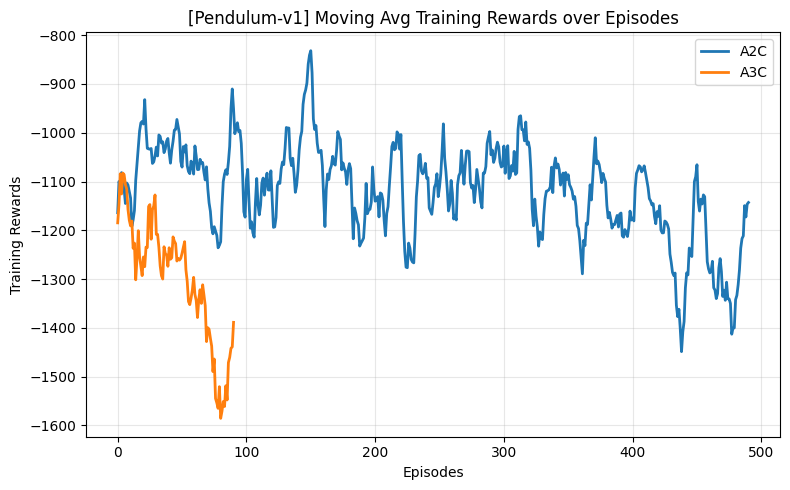

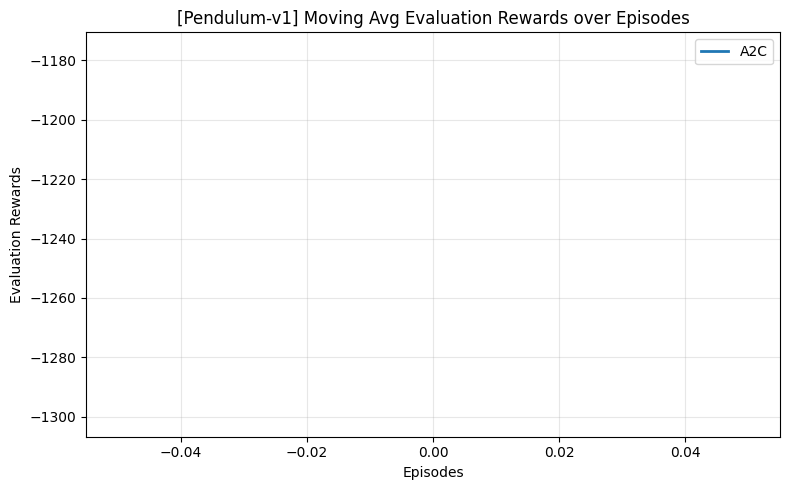

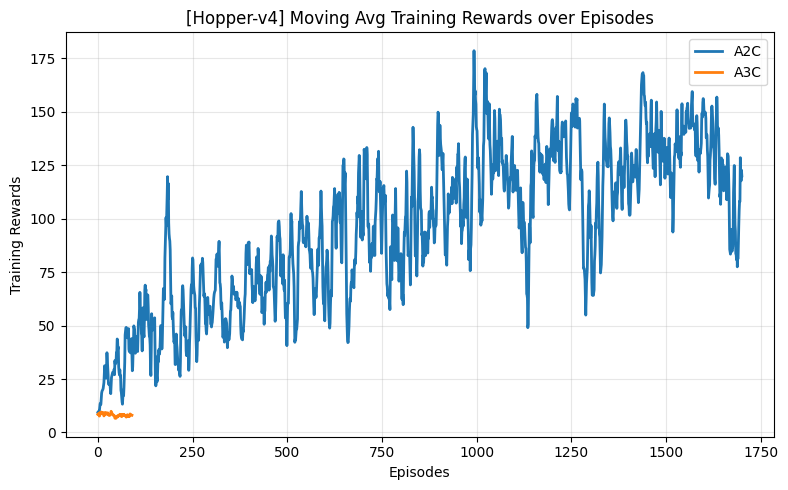

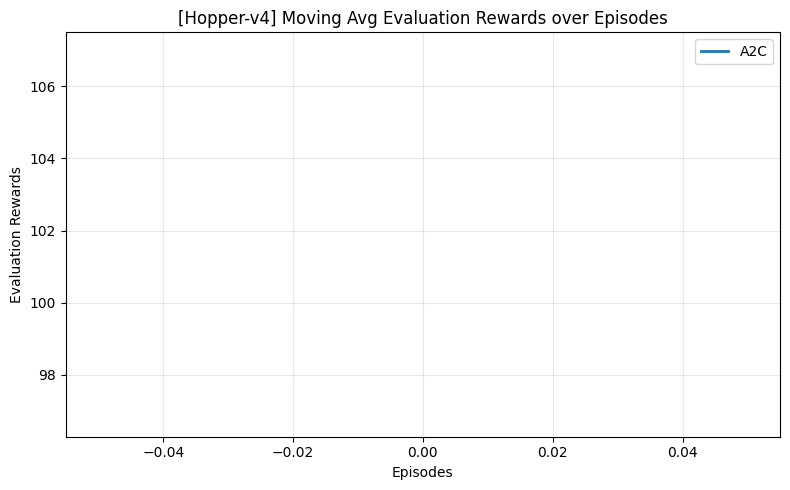

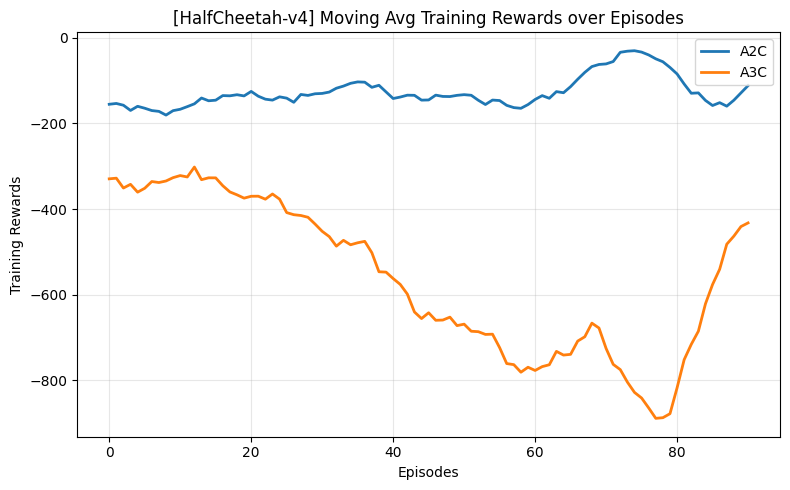

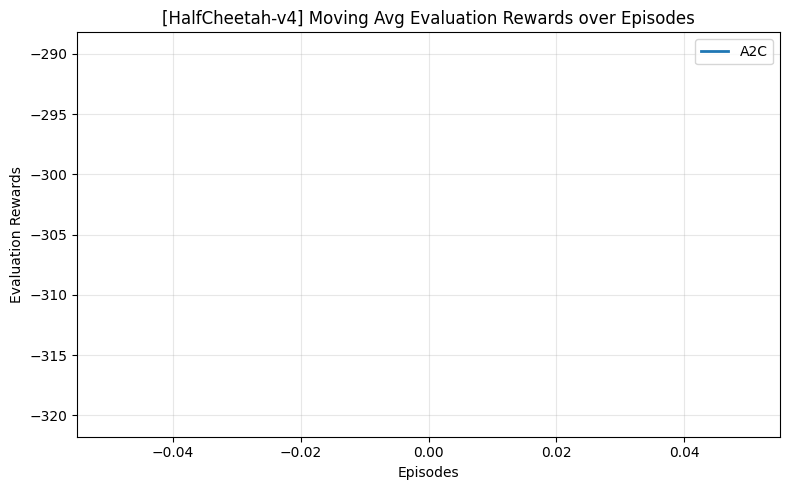

In [76]:
print("\nComparing A2C vs A3C...")
comparison_data = compare_a2c_a3c()
plotResults(comparison_data, ["Pendulum-v1", "Hopper-v4", "HalfCheetah-v4"],
            window=10, use_moving_avg=True)

## GAE Questions [$10 \times 4 = 40$ marks]

### Q1. Derive the GAE formula starting from multi-step advantage estimates.



### Q2. What happens at the extreme values of λ, and what is a good practical default?



### Q3. From the GAE lambda sweep experiment, which lambda values perform best and why?



### Q4. How does GAE relate to TD(λ) from tabular RL?



# Deep Deterministic Policy Gradient (DDPG) [50 marks]
<a id="ddpg"></a>

Implement the Deep Deterministic Policy Gradient (DDPG) agent. We have studied about DDPG agent in the Lecture. Use the function definitions (given below).

This class implements the DDPG agent, you are required to implement the various methods of this class
as outlined below. Note this class is generic and should work with any permissible Gym environment

```
class DDPG():
    def init(self, env, seed, gamma, tau, bufferSize, batch_size, updateFrequency,
             policyOptimizerFn, valueOptimizerFn,
             policyOptimizerLR,valueOptimizerLR,
             MAX_TRAIN_EPISODES,MAX_EVAL_EPISODE,
             optimizerFn)
    
    def runDDPG(self)
    def trainAgent(self)
    def gaussianStrategy(self, net , s , envActionRange , noiseScaleRatio,
        explorationMax = True)
    def greedyStrategy(self, net , s , envActionRange)
    def trainNetworks(self, experiences)
    def updateNetworks(self, onlineNet, targetNet, tau)
    def evaluateAgent(self)




```

In [ ]:
seed = 33
gamma = 0.99
tau = 0.15
bufferSize = 100000
batch_size = 32
updateFrequency = 4
policyOptimizerFn = torch.optim.Adam
valueOptimizerFn = torch.optim.Adam
policyOptimizerLR = 0.0001
valueOptimizerLR = 0.0002
MAX_TRAIN_EPISODES = 10
MAX_EVAL_EPISODE = 1
optimizerFn = None

In [ ]:
class DDPG():
    def __init__(self, env, seed, gamma, tau, bufferSize, batch_size, updateFrequency,
             policyOptimizerFn, valueOptimizerFn,
             policyOptimizerLR,valueOptimizerLR,
             MAX_TRAIN_EPISODES,MAX_EVAL_EPISODE,
             optimizerFn):
        #this DDPG method
        # 1. creates and initializes (with seed) the environment, train/eval episodes, gamma, etc.
        # 2. creates and intializes all the variables required for book-keeping values via the initBookKeeping method
        # 3. creates targetValueNetwork , targetPolicyNetwork
        # 4. creates and initializes (with network params) the optimizer function
        # 5. creates onlineValueNetwork, onlinePolicyNetwork
        # 6. Creates the replayBuffer

        #Your code goes in here
        self.env = env
        self.seed = seed

        self.env.reset(seed=seed)
        np.random.seed(seed)

        self.gamma = gamma
        self.tau = tau
        self.bufferSize = bufferSize
        self.batch_size = batch_size
        self.updateFrequency = updateFrequency
        self.MAX_TRAIN_EPISODES = MAX_TRAIN_EPISODES
        self.MAX_EVAL_EPISODE = MAX_EVAL_EPISODE

        self.MAX_VALUE_GRAD_NORM = 10
        self.MAX_POLICY_GRAD_NORM = 1

        self.targetValueNetwork = createValueNetwork(self.env.observation_space.shape[0], 1, env.action_space.shape[0], hDim=[64, 64])
        self.onlineValueNetwork = createValueNetwork(self.env.observation_space.shape[0], 1, env.action_space.shape[0], hDim=[64,64])
        self.targetPolicyNetwork = createPolicyNetwork(self.env.observation_space.shape[0], env.action_space.shape[0], hDim=[64,64])
        self.onlinePolicyNetwork = createPolicyNetwork(self.env.observation_space.shape[0], env.action_space.shape[0], hDim=[64, 64])

        self.updateNetworks(self.onlineValueNetwork, self.targetValueNetwork, self.tau)
        self.updateNetworks(self.onlinePolicyNetwork, self.targetPolicyNetwork, self.tau)

        self.policyOptimizer = policyOptimizerFn(self.onlinePolicyNetwork.parameters(), lr=policyOptimizerLR)
        self.valueOptimizer = valueOptimizerFn(self.onlineValueNetwork.parameters(), lr=valueOptimizerLR)

        self.actionLowVal = torch.tensor(self.env.action_space.low, dtype=torch.float32)
        self.actionHighVal = torch.tensor(self.env.action_space.high, dtype=torch.float32)
        self.actionRange = self.actionHighVal - self.actionLowVal

        self.initBookKeeping()
        self.rBuffer = ReplayBuffer(self.bufferSize, self.batch_size, self.seed)


In [ ]:
class DDPG(DDPG):
    def initBookKeeping(self):

      self.trainRewardsList = []
      self.evalRewardsList = []
      self.trainTimeList = []
      self.wallClockTimeList = []
      self.totalStepsList = []

      self.startTime = time.time()

    def performBookKeeping(self, train=True):
        if train:
            self.trainTimeList.append(time.time() - self.startTime)
        else:
            self.wallClockTimeList.append(time.time() - self.startTime)

In [ ]:
class DDPG(DDPG):
    def updateNetworks(self, onlineNet, targetNet, tau):
        #this function updates the onlineNetwork with the target network
        #
        # Your code goes in here
        #
        for targetParam, onlineParam in zip(targetNet.parameters(), onlineNet.parameters()):
            mixedWeights = onlineParam.data * tau + targetParam.data * (1 - tau)
            targetParam.data.copy_(mixedWeights)

In [ ]:
class DDPG(DDPG):
    def gaussianStrategy (self, net, s, envActionRange, noiseScaleRatio, explorationMax = True):
        #this function sets the scale of exploration then add the noise of this scale to the greedy action
        #and clips it within the range

        #Your code here
        if explorationMax:
          scale = self.actionRange
        else:
          scale = noiseScaleRatio * self.actionRange

        greedyAction = net(s).detach()
        noise = torch.randn_like(greedyAction) * scale
        action = greedyAction + noise
        action = action.clamp(self.actionLowVal, self.actionHighVal)

        return action.detach().cpu().numpy().reshape(-1)


In [ ]:
class DDPG(DDPG):
    def greedyStrategy (self, net , s , envActionRange):
        #this function selects the greedy action
        #and clips it within the range

        #Your code here
        action = net(s).detach()
        action = action.clamp(self.actionLowVal, self.actionHighVal)
        return action.detach().cpu().numpy().reshape(-1)


In [ ]:
class DDPG(DDPG):
    def runDDPG (self):
        #this is the main method, it trains the agent, performs bookkeeping while training and finally evaluates
        #the agent and returns the following quantities:
        #1. episode wise mean train rewards
        #2. epsiode wise mean eval rewards
        #2. episode wise trainTime (in seconds): time elapsed during training since the start of the first episode
        #3. episode wise wallClockTime (in seconds): actual time elapsed since the start of training,
        #                               note this will include time for BookKeeping and evaluation
        # Note both trainTime and wallClockTime get accumulated as episodes proceed.
        #
        #Your code goes in here
        #
        trainRewardsList, trainTimeList, evalRewardsList, wallClockTimeList, totalStepsList = self.trainAgent()
        finalEvalReward = self.evaluateAgent()
        return trainRewardsList, trainTimeList, evalRewardsList, wallClockTimeList, totalStepsList, finalEvalReward


In [ ]:
class DDPG(DDPG):
    def trainAgent(self):
        #this method collects experiences and trains the agent and does BookKeeping while training.
        #this calls the trainNetwork() method internally, it also evaluates the agent per episode
        #it trains the agent for MAX_TRAIN_EPISODES
        #
        #Your code goes in here
        #
        self.updateNetworks(self.onlineValueNetwork, self.targetValueNetwork, self.tau)
        self.updateNetworks(self.onlinePolicyNetwork, self.targetPolicyNetwork, self.tau)

        for e in range(self.MAX_TRAIN_EPISODES):
            episodeReward = 0.0
            envActionRange = self.env.action_space.high, self.env.action_space.low
            s, _ = self.env.reset()
            done = False
            steps_per_episode = 0
            while not done:
                steps_per_episode += 1
                a = self.gaussianStrategy(self.onlinePolicyNetwork, torch.from_numpy(s).float(), envActionRange,
                                          noiseScaleRatio=0.2, explorationMax = self.rBuffer.length() < self.batch_size)
                s_next, r, done, truncated, _ = self.env.step(a)
                done = done or truncated
                episodeReward += float(r)
                self.rBuffer.store(s, a, r, s_next, done)
                s = s_next
                if self.rBuffer.length() >= self.batch_size:
                    experiences = self.rBuffer.sample(self.batch_size)
                    self.trainNetwork(experiences)
                    self.performBookKeeping()

            evalReward = self.evaluateAgent()
            self.trainRewardsList.append(episodeReward)
            self.evalRewardsList.append(np.mean(evalReward).mean())

            if e % self.updateFrequency == 0:
                self.updateNetworks(self.onlineValueNetwork, self.targetValueNetwork, self.tau)
                self.updateNetworks(self.onlinePolicyNetwork, self.targetPolicyNetwork, self.tau)

            self.totalStepsList.append(steps_per_episode)
            if e % 10 == 0:
                print(f"Episode: {e} | Train Reward: {episodeReward} | Eval Reward: {np.mean(evalReward).mean()}")

        return self.trainRewardsList, self.trainTimeList, self.evalRewardsList, self.wallClockTimeList, self.totalStepsList

In [ ]:
class DDPG(DDPG):
    def trainNetwork(self, experiences):
        # this method trains the value network epoch number of times and is called by the trainAgent function
        # it essentially uses the experiences to calculate target, using the targets it calculates the error, which
        # is further used for calulating the loss. It then uses the optimizer over the loss
        # to update the params of the network by backpropagating through the network
        # this function does not return anything
        # you can try out other loss functions other than MSE like Huber loss, MAE, etc.
        #
        #Your code goes in here
        #

        ss, actions, rs, sNexts, dones = self.rBuffer.splitExperiences(experiences)

        ss = torch.tensor(ss, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.float32)
        rs = torch.tensor(rs, dtype=torch.float32).unsqueeze(1)
        sNexts = torch.tensor(sNexts, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

        with torch.no_grad():
            next_actions = self.targetPolicyNetwork(sNexts)
            next_q = self.targetValueNetwork(sNexts, next_actions)
            targets = rs + self.gamma * (1 - dones) * next_q

        current_q = self.onlineValueNetwork(ss, actions)
        valueLoss = torch.mean((targets - current_q) ** 2)
        self.valueOptimizer.zero_grad()
        valueLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.onlineValueNetwork.parameters(), self.MAX_VALUE_GRAD_NORM)
        self.valueOptimizer.step()

        pred_actions = self.onlinePolicyNetwork(ss)
        actor_loss = -self.onlineValueNetwork(ss, pred_actions).mean()
        self.policyOptimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.onlinePolicyNetwork.parameters(), self.MAX_POLICY_GRAD_NORM)
        self.policyOptimizer.step()

In [ ]:
class DDPG(DDPG):
    def evaluateAgent(self):
        #this function evaluates the agent using the value network, it evaluates agent for MAX_EVAL_EPISODES
        #typcially MAX_EVAL_EPISODES = 1
        #
        #Your code goes in here
        #
        finalEvalRewardsList = []
        for e in range(self.MAX_EVAL_EPISODE):
            episodeReward = 0.0
            s, _ = self.env.reset()
            done = False
            for c in count():
                envActionRange = (self.env.action_space.low, self.env.action_space.high)
                a = self.greedyStrategy(self.onlinePolicyNetwork, torch.from_numpy(s).float(), envActionRange)
                s_next, r, done, truncated, _ = self.env.step(a)
                episodeReward += r
                s = s_next
                if done or truncated:
                    break
            finalEvalRewardsList.append(episodeReward)
            self.performBookKeeping(train=False)
        return np.mean(finalEvalRewardsList), np.mean(finalEvalRewardsList)

In [ ]:
# evaluating the VPG agent on multiple continuous-control

# Environments used in this experiment
env_names = [
    "Pendulum-v1",
    "HalfCheetah-v4",
    "Hopper-v4"
]

quantityDictVPG = {}

# Number of independent training runs per environment
num_runs = 5

# For each environment:
for env_name in env_names:

    print(f"\n===== Environment: {env_name} =====")

    all_train_rewards = []
    all_eval_rewards = []
    all_train_times = []
    all_wall_clock_times = []
    all_total_steps = []

    for run in range(num_runs):

        print(f"Run {run+1}")

        # Create environment
        env = gym.make(env_name)

        # Initialize SAC agent
        env = gym.make(env_id)
        agent = DDPG(
            env, seed, gamma, tau, bufferSize, batch_size, updateFrequency,
            policyOptimizerFn, valueOptimizerFn,
            policyOptimizerLR, valueOptimizerLR,
            MAX_TRAIN_EPISODES, MAX_EVAL_EPISODE,
            optimizerFn
        )

        # Run training
        train_rewards, train_times, eval_rewards, wallclock_times, total_steps, final_eval_reward = agent.runDDPG()

        # Store rewards for this run
        all_train_rewards.append(train_rewards)
        all_eval_rewards.append(eval_rewards)
        all_train_times.append(train_times)
        all_wall_clock_times.append(wall_clock_times)
        all_total_steps.append(total_steps_per_episode)

    # Compute Statistics
    all_train_rewards = np.array(all_train_rewards)
    all_eval_rewards = np.array(all_eval_rewards)

    train_mean_rewards = np.mean(all_train_rewards, axis=0)
    train_std_rewards = np.std(all_train_rewards, axis=0)

    eval_mean_rewards = np.mean(all_eval_rewards, axis=0)
    eval_std_rewards = np.std(all_eval_rewards, axis=0)

    print(f'train rewards: {np.mean(all_train_rewards)} & train std: {np.std(all_train_rewards)}')
    print(f'eval rewards: {np.mean(all_eval_rewards)} & eval std: {np.std(all_eval_rewards)}')
    print(f"Finished {env_name}")

    quantityDictVPG[env_name] = {
        "Mean Train Rewards": {
            "VPG": all_train_rewards
        },
        "Mean Eval Rewards": {
            "VPG": all_eval_rewards
        },
        "Train Time (in sec)": {
            "VPG": all_train_times
        },
        "Wall Clock Time (in sec)": {
            "VPG": all_wall_clock_times
        },
        "Total Steps": {
            "VPG": all_total_steps
        }
    }
    
np.save('plot_configs/vpg_dict.npy', quantityDictVPG)

--------------------------------------------------
Running Pendulum-v1
Episode: 0, Train Reward: -1452.4988938735755, Eval Reward: -1627.4480939861382
Episode: 1, Train Reward: -1633.7010704299548, Eval Reward: -1389.4083959273512
Episode: 2, Train Reward: -1273.064881171026, Eval Reward: -1510.3224650336738
Episode: 3, Train Reward: -1496.4783970299452, Eval Reward: -1594.4796327360957
Episode: 4, Train Reward: -1618.9131316846247, Eval Reward: -1377.8124162512627
Episode: 5, Train Reward: -1369.0486291936709, Eval Reward: -1350.3442129209795
Episode: 6, Train Reward: -1366.1667476201874, Eval Reward: -1261.395169447118
Episode: 7, Train Reward: -1571.40000003625, Eval Reward: -1220.5815373913342
Episode: 8, Train Reward: -1635.353773612287, Eval Reward: -1689.475541030285
Episode: 9, Train Reward: -1646.3165470786435, Eval Reward: -1688.0315117255643
--------------------------------------------------
Running Hopper-v4
Episode: 0, Train Reward: 5.832338756041668, Eval Reward: 34.22500

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode: 2, Train Reward: 11.59010189255887, Eval Reward: 28.370652264724733
Episode: 3, Train Reward: 12.906459639135473, Eval Reward: 22.945998614139807
Episode: 4, Train Reward: 13.662538102988929, Eval Reward: 18.97893844920032
Episode: 5, Train Reward: 13.216519132993088, Eval Reward: 14.267153790978604
Episode: 6, Train Reward: 30.537541037963813, Eval Reward: 9.724366780495885
Episode: 7, Train Reward: 11.34459599450839, Eval Reward: 8.611828769672835
Episode: 8, Train Reward: 6.381628362888751, Eval Reward: 8.418335820650348
Episode: 9, Train Reward: 6.733535116718416, Eval Reward: 7.732005676507905
--------------------------------------------------
Running HalfCheetah-v4


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode: 0, Train Reward: -476.24720186217456, Eval Reward: -507.0882662610806
Episode: 1, Train Reward: -585.9243778296479, Eval Reward: -601.7212529934258
Episode: 2, Train Reward: -595.3243514899648, Eval Reward: -600.2751982144732
Episode: 3, Train Reward: -603.7610669370123, Eval Reward: -600.4747565402062
Episode: 4, Train Reward: -600.6699653531007, Eval Reward: -602.2548955617478
Episode: 5, Train Reward: -597.1367174827371, Eval Reward: -601.640165086178
Episode: 6, Train Reward: -600.3571774286711, Eval Reward: -602.358318848506
Episode: 7, Train Reward: -600.8259197723303, Eval Reward: -602.884872043691
Episode: 8, Train Reward: -599.858327019985, Eval Reward: -602.2536461557345
Episode: 9, Train Reward: -600.7572389857876, Eval Reward: -601.0894499798017


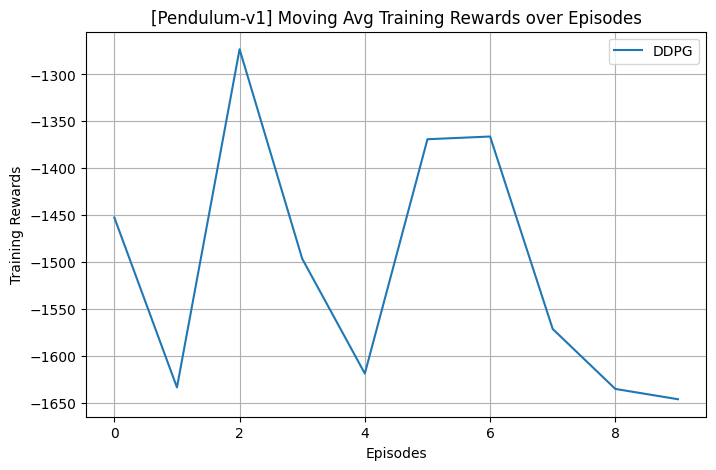

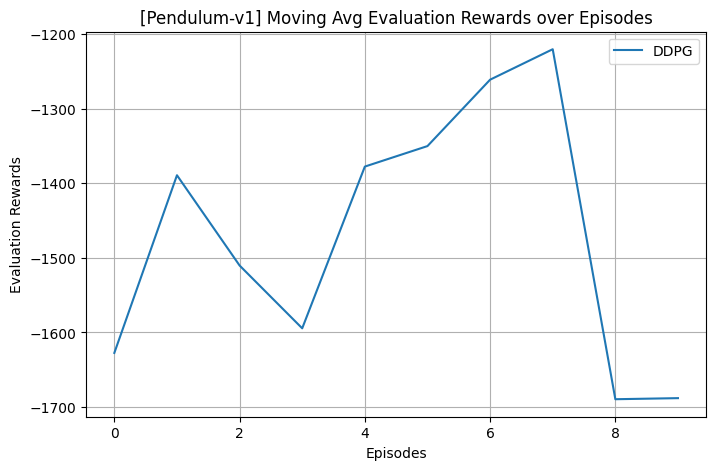

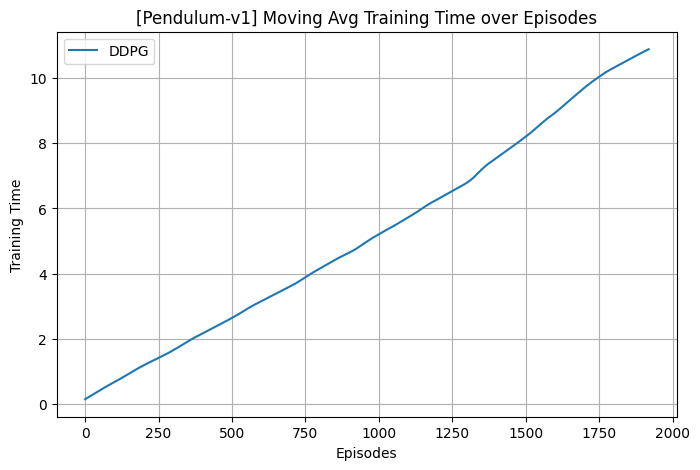

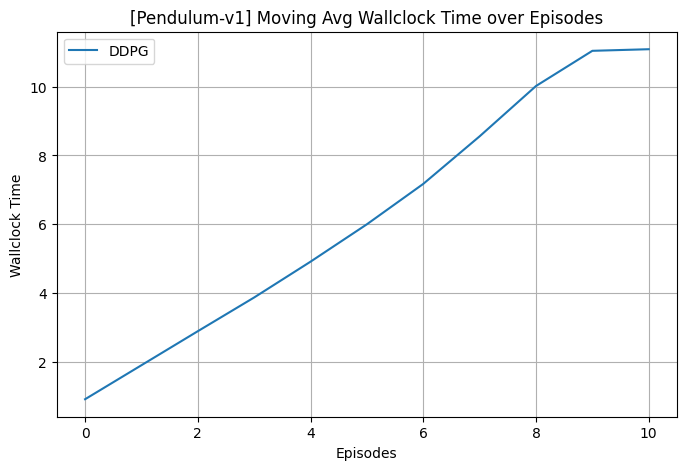

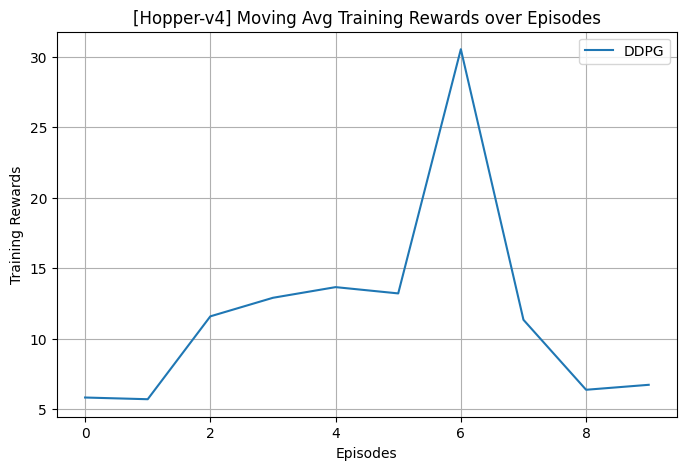

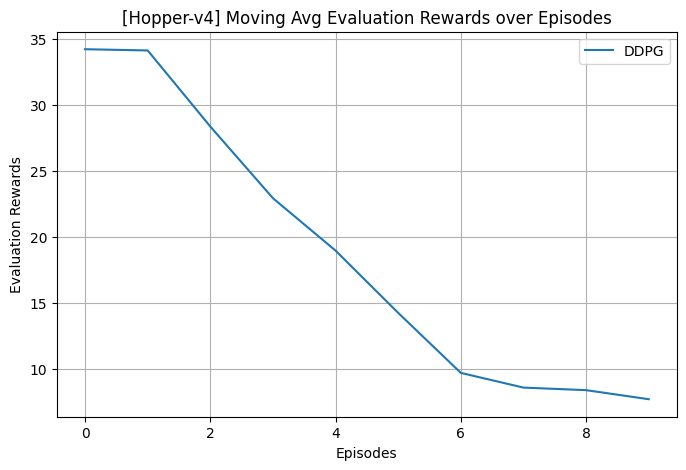

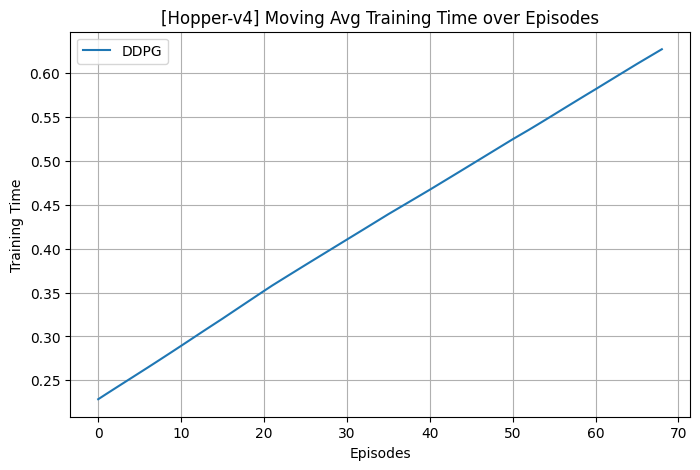

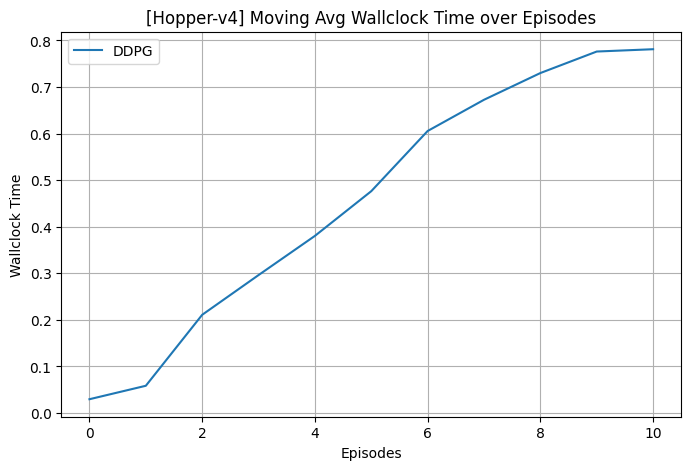

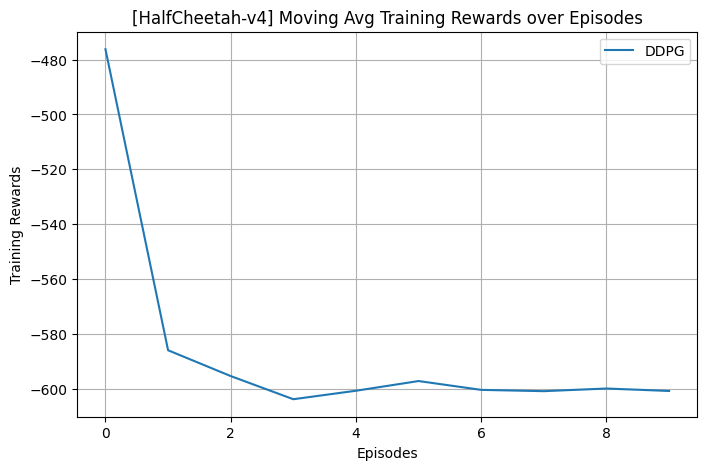

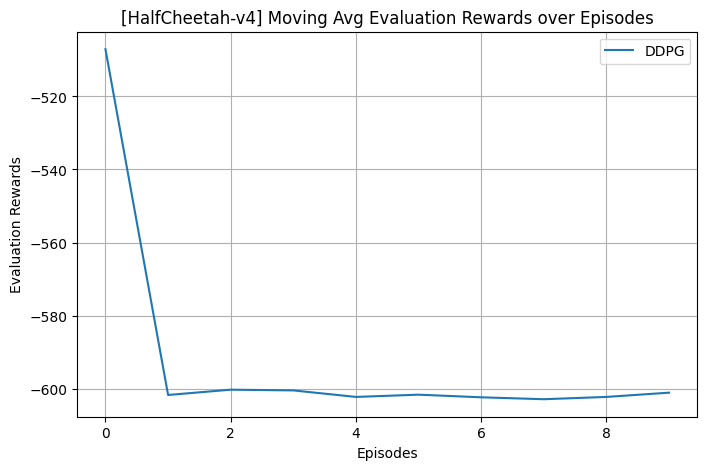

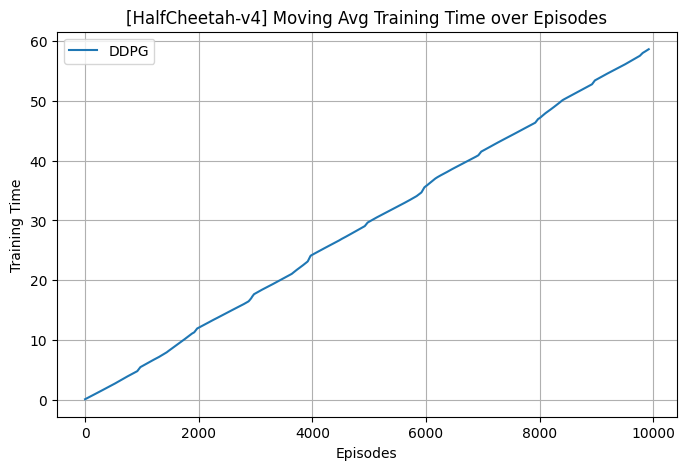

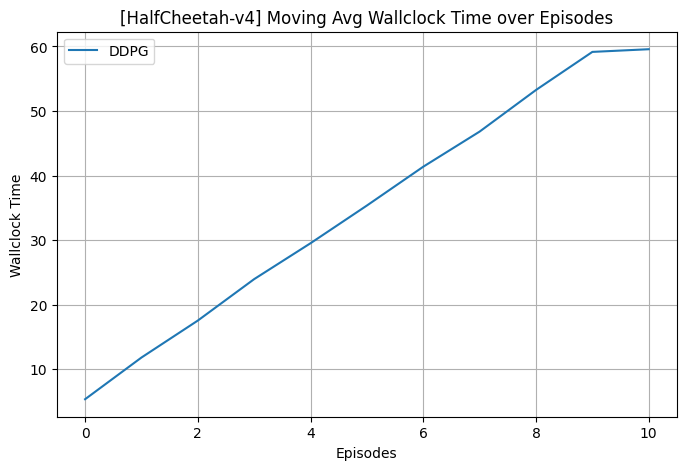

In [ ]:
# Run the A2C training on multiple environments and store the results.
# Iterate through the environments: 'Pendulum-v1', 'Hopper-v4', and 'HalfCheetah-v4'.

# For each environment, print a header so that the training progress is clear.

# Call the function train_a2c() with the environment name and a total training
# Store the returned training results in a dictionary.


env_names = ["Pendulum-v1", "Hopper-v4", "HalfCheetah-v4"]
ddpg_plot_config = {}

for env_id in env_names:
    print(f"-" * 50)
    print(f"Running {env_id}")
    env = gym.make(env_id)
    agent = DDPG(
        env, seed, gamma, tau, bufferSize, batch_size, updateFrequency,
        policyOptimizerFn, valueOptimizerFn,
        policyOptimizerLR, valueOptimizerLR,
        MAX_TRAIN_EPISODES, MAX_EVAL_EPISODE,
        optimizerFn
    )

    train_rewards, train_times, eval_rewards, wallclock_times, total_steps, final_eval_reward = agent.runDDPG()
    ddpg_plot_config[env_id] = {
        "Training Rewards": {"DDPG": [train_rewards]},
        "Evaluation Rewards": {"DDPG": [eval_rewards]},
        "Training Time": {"DDPG": [train_times]},
        "Wallclock Time": {"DDPG": [wallclock_times]},
        "Total Steps": {"DDPG": []}
      }


# Plot the learning curve:
#   - First plot the raw returns with a light transparency.
#   - Then compute a moving-average smoothing using numpy convolution
#     to show a cleaner trend of the learning progress.


# Display the plot for each environment.
plotResults(ddpg_plot_config, env_names)

# Twin-Delayed Deep Deterministic Policy Gradient (TD3) [50 marks]
<a id="td3"></a>

Implement the Twin-delayed deep deterministic policy gradient (TD3) agent. We have studied about TD3 agent in the Lecture. Use the function definitions (given below).

This class implements the TD3 agent, you are required to implement the various methods of this class
as outlined below. Note this class is generic and should work with any permissible Gym environment

```
class DDPG():
    def init(env, gamma, tau,
    bufferSize ,
    updateFrequencyPolicy ,
    updateFrequencyValue ,
    trainPolicyFrequency ,
    policyOptimizerFn ,
    valueOptimizerFn ,
    policyOptimizerLR ,
    valueOptimizerLR ,
    MAX TRAIN EPISODES,
    MAX EVAL EPISODE,
    optimizerFn )
    
    def runTD3 (self)
    def trainAgent (self)
    def gaussianStrategy (self, net , s , envActionRange , noiseScaleRatio ,
        explorationMax = True)
    def greedyStrategy (self, net , s , envActionRange)
    def trainNetworks (self,experiences , envActionRange)
    def updateValueNetwork(self, onlineNet, targetNet, tau)
    def updatePolicyNetwork(self, onlineNet, targetNet, tau)
    def evaluateAgent (self)



```

In [ ]:
seed = 33
gamma = 0.99
tau = 0.15
bufferSize = 100000
batch_size = 32
updateFrequencyValue = 4
updateFrequencyPolicy = 2
trainPolicyFrequency = 2
policyOptimizerFn = torch.optim.Adam
valueOptimizerFn = torch.optim.Adam
policyOptimizerLR = 0.0001
valueOptimizerLR = 0.0002
MAX_TRAIN_EPISODES = 10
MAX_EVAL_EPISODE = 1
optimizerFn = None

In [ ]:
class TD3():
    def __init__(self, env, seed, gamma, tau,
    bufferSize, batchSize,
    updateFrequencyPolicy ,
    updateFrequencyValue ,
    trainPolicyFrequency ,
    policyOptimizerFn ,
    valueOptimizerFn ,
    policyOptimizerLR ,
    valueOptimizerLR ,
    MAX_TRAIN_EPISODES,
    MAX_EVAL_EPISODE,
    optimizerFn):
        #this TD3 method
        # 1. creates and initializes (with seed) the environment, train/eval episodes, gamma, etc.
        # 2. creates and intializes all the variables required for book-keeping values via the initBookKeeping method
        # 3. creates targetValueNetwork , targetPolicyNetwork
        # 4. creates and initializes (with network params) the optimizer function
        # 5. creates onlineValueNetwork, onlinePolicyNetwork
        # 6. Creates the replayBuffer

        #Your code goes in here
        self.env = env
        self.seed = seed
        self.env.reset(seed = self.seed)

        self.gamma = gamma
        self.tau = tau
        self.bufferSize = bufferSize
        self.updateFrequencyPolicy = updateFrequencyPolicy
        self.updateFrequencyValue = updateFrequencyValue
        self.trainPolicyFrequency = trainPolicyFrequency
        self.batch_size = batchSize

        self.obs_dim = self.env.observation_space.shape[0]
        self.act_dim = self.env.action_space.shape[0]
        self.targetValueNetwork = createValueNetwork(self.obs_dim, 1, self.act_dim, hDim=[256, 128], isTwoStreams=True)
        self.onlineValueNetwork =createValueNetwork(self.obs_dim, 1, self.act_dim, hDim=[256, 128], isTwoStreams=True)
        self.targetPolicyNetwork = createPolicyNetwork(self.obs_dim, self.act_dim, hDim=[256, 128])
        self.onlinePolicyNetwork = createPolicyNetwork(self.obs_dim, self.act_dim, hDim=[256, 128])

        self.updateValueNetwork(self.onlineValueNetwork, self.targetValueNetwork, self.tau)
        self.updatePolicyNetwork(self.onlinePolicyNetwork, self.targetPolicyNetwork, self.tau)

        self.valueOptimizer = valueOptimizerFn(self.onlineValueNetwork.parameters(), lr=valueOptimizerLR)
        self.policyOptimizer = policyOptimizerFn(self.onlinePolicyNetwork.parameters(), lr=policyOptimizerLR)

        self.MAX_VALUE_GRAD_NORM = 10
        self.MAX_POLICY_GRAD_NORM = 1

        self.MAX_TRAIN_EPISODES = MAX_TRAIN_EPISODES
        self.MAX_EVAL_EPISODE = MAX_EVAL_EPISODE

        self.actionLowVal = torch.tensor(self.env.action_space.low, dtype=torch.float32)
        self.actionHighVal = torch.tensor(self.env.action_space.high, dtype=torch.float32)
        self.actionRange = self.actionHighVal - self.actionLowVal

        self.initBookKeeping()
        self.rBuffer = ReplayBuffer(self.bufferSize, seed = self.seed)



In [ ]:
class TD3(TD3):
    def initBookKeeping(self):
      self.trainRewardsList = []
      self.evalRewardsList = []
      self.trainTimeList = []
      self.wallClockTimeList = []

      self.startTime = time.time()

    def performBookKeeping(self, train=True):
        if train:
            self.trainTimeList.append(time.time() - self.startTime)
        else:
            self.wallClockTimeList.append(time.time() - self.startTime)

In [ ]:
class TD3(TD3):
    def updateValueNetwork(self, onlineNet, targetNet, tau):
        #this function updates the onlineValueNetwork with the targetValuenetwork
        #
        # Your code goes in here
        #
        for targetParam, onlineParam in zip(targetNet.parameters(), onlineNet.parameters()):
            mixedWeights = onlineParam.data * tau + targetParam.data * (1 - tau)
            targetParam.data.copy_(mixedWeights)


In [ ]:
class TD3(TD3):
    def updatePolicyNetwork(self, onlineNet, targetNet, tau):
        #this function updates the onlinePolicuNetwork with the targetPolicynetwork
        #
        # Your code goes in here
        #
        for targetParam, onlineParam in zip(targetNet.parameters(), onlineNet.parameters()):
            mixedWeights = onlineParam.data * tau + targetParam.data * (1 - tau)
            targetParam.data.copy_(mixedWeights)


In [ ]:
class TD3(TD3):
    def gaussianStrategy (self, net , s , envActionRange , noiseScaleRatio ,
        explorationMax = True ):
        #this function sets the scale of exploration then add the noise of this scale to the greedy action
        #and clips it within the range

        #Your code here
        if explorationMax:
          scale = self.actionRange
        else:
          scale = noiseScaleRatio * self.actionRange

        greedyAction = net(s).detach()
        noise = torch.randn_like(greedyAction) * scale
        action = greedyAction + noise
        action = action.clamp(self.actionLowVal, self.actionHighVal)

        return action.detach().cpu().numpy().reshape(-1)


In [ ]:
class TD3(TD3):
    def greedyStrategy (self, net , s , envActionRange ):
        #this function selects the greedy action
        #and clips it within the range

        #Your code here
        action = net(s).detach()
        action = action.clamp(self.actionLowVal, self.actionHighVal)
        return action.detach().cpu().numpy().reshape(-1)


In [ ]:
class TD3(TD3):
    def runTD3 (self):
        #this is the main method, it trains the agent, performs bookkeeping while training and finally evaluates
        #the agent and returns the following quantities:
        #1. episode wise mean train rewards
        #2. epsiode wise mean eval rewards
        #2. episode wise trainTime (in seconds): time elapsed during training since the start of the first episode
        #3. episode wise wallClockTime (in seconds): actual time elapsed since the start of training,
        #                               note this will include time for BookKeeping and evaluation
        # Note both trainTime and wallClockTime get accumulated as episodes proceed.
        #
        #Your code goes in here
        #
        trainRewardsList, trainTimeList, evalRewardsList, wallClockTimeList = self.trainAgent()
        finalEvalReward = self.evaluateAgent()
        return trainRewardsList, trainTimeList, evalRewardsList, wallClockTimeList, finalEvalReward


In [ ]:
class TD3(TD3):
    def trainAgent(self):
        #this method collects experiences and trains the agent and does BookKeeping while training.
        #this calls the trainNetwork() method internally, it also evaluates the agent per episode
        #it trains the agent for MAX_TRAIN_EPISODES
        #
        #Your code goes in here
        #
        self.updateValueNetwork(self.onlineValueNetwork, self.targetValueNetwork, self.tau)
        self.updatePolicyNetwork(self.onlinePolicyNetwork, self.targetPolicyNetwork, self.tau)

        for e in range(self.MAX_TRAIN_EPISODES):
            episodeReward = 0.0
            envActionRange = self.env.action_space.high, self.env.action_space.low
            s, _ = self.env.reset()
            done = False
            while not done:
                a = self.gaussianStrategy(self.onlinePolicyNetwork, torch.from_numpy(s).float(), envActionRange,
                                          noiseScaleRatio=0.2, explorationMax = self.rBuffer.length() < self.batch_size)
                s_next, r, done, truncated, _ = self.env.step(a)
                done = done or truncated
                episodeReward += float(r)
                self.rBuffer.store(s, a, r, s_next, done)
                s = s_next
                if self.rBuffer.length() >= self.batch_size:
                    experiences = self.rBuffer.sample(self.batch_size)
                    self.trainNetwork(experiences, e, envActionRange)
                    self.performBookKeeping()

            evalReward = self.evaluateAgent()
            self.trainRewardsList.append(episodeReward)
            self.evalRewardsList.append(np.mean(evalReward).mean())

            if e % self.updateFrequencyValue == 0:
                self.updateValueNetwork(self.onlineValueNetwork, self.targetValueNetwork, self.tau)

            if e % self.updateFrequencyPolicy == 0:
                self.updatePolicyNetwork(self.onlinePolicyNetwork, self.targetPolicyNetwork, self.tau)

            print(f"Episode: {e} | Train Reward: {episodeReward} | Eval Reward: {np.mean(evalReward).mean()}")

        return self.trainRewardsList, self.trainTimeList, self.evalRewardsList, self.wallClockTimeList

In [ ]:
class TD3(TD3):
    def trainNetwork(self, experiences , episode, envActionRange):
        # this method trains the value network epoch number of times and is called by the trainAgent function
        # it essentially uses the experiences to calculate target, using the targets it calculates the error, which
        # is further used for calulating the loss. It then uses the optimizer over the loss
        # to update the params of the network by backpropagating through the network
        # this function does not return anything
        # you can try out other loss functions other than MSE like Huber loss, MAE, etc.
        #
        #Your code goes in here
        #
        ss, actions, rs, sNexts, dones = self.rBuffer.splitExperiences(experiences)

        ss = torch.tensor(ss, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.float32)
        rs = torch.tensor(rs, dtype=torch.float32).unsqueeze(1)
        sNexts = torch.tensor(sNexts, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

        as_noise = self.actionRange * torch.randn_like(actions)
        as_noise = torch.max(torch.min(as_noise, self.actionHighVal), self.actionLowVal)

        argmax_a_qs_v = self.targetPolicyNetwork(sNexts)
        noisy_argmax_a_qs_v = argmax_a_qs_v + as_noise
        noisy_argmax_a_qs_v = torch.max(torch.min(noisy_argmax_a_qs_v, self.actionHighVal), self.actionLowVal)

        max_1_a_qs_v, max_2_a_qs_v = self.targetValueNetwork(sNexts, noisy_argmax_a_qs_v)
        max_a_qs_v = torch.min(max_1_a_qs_v, max_2_a_qs_v)
        target_qs = rs + self.gamma * (1 - dones) * max_a_qs_v

        qs_1, qs_2 = self.onlineValueNetwork(ss, actions)
        tdErrors_1 = target_qs.detach() - qs_1
        tdErrors_2 = target_qs.detach() - qs_2

        valueLoss = torch.mean(0.5 * (tdErrors_1 ** 2)) + torch.mean(0.5 * (tdErrors_2 ** 2))
        self.valueOptimizer.zero_grad()
        valueLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.onlineValueNetwork.parameters(), self.MAX_VALUE_GRAD_NORM)
        self.valueOptimizer.step()

        if episode % self.trainPolicyFrequency == 0:
            argmax_a_qs_p = self.onlinePolicyNetwork(sNexts)
            max_a_qs_p, _ = self.onlineValueNetwork(sNexts, argmax_a_qs_p)
            policyLoss = -torch.mean(max_a_qs_p)
            self.policyOptimizer.zero_grad()
            policyLoss.backward()
            torch.nn.utils.clip_grad_norm_(self.onlinePolicyNetwork.parameters(), self.MAX_POLICY_GRAD_NORM)
            self.policyOptimizer.step()

In [ ]:
class TD3(TD3):
    def evaluateAgent(self):
        #this function evaluates the agent using the value network, it evaluates agent for MAX_EVAL_EPISODES
        #typcially MAX_EVAL_EPISODES = 1
        #
        #Your code goes in here
        #
        finalEvalRewardsList = []
        for e in range(self.MAX_EVAL_EPISODE):
            episodeReward = 0.0
            s, _ = self.env.reset()
            done = False
            for c in count():
                envActionRange = (self.env.action_space.low, self.env.action_space.high)
                a = self.greedyStrategy(self.onlinePolicyNetwork, torch.from_numpy(s).float(), envActionRange)
                s_next, r, done, truncated, _ = self.env.step(a)
                episodeReward += r
                s = s_next
                if done or truncated:
                    break
            finalEvalRewardsList.append(episodeReward)
            self.performBookKeeping(train=False)
        return np.mean(finalEvalRewardsList), np.mean(finalEvalRewardsList)

--------------------------------------------------
Running Pendulum-v1
Episode: 0, Train Reward: -1788.6823931199997, Eval Reward: -1499.9777006927236
Episode: 1, Train Reward: -1555.2390912181545, Eval Reward: -1650.2398485102578
Episode: 2, Train Reward: -1510.9717086469238, Eval Reward: -1497.9351096328462
Episode: 3, Train Reward: -1539.3046688693612, Eval Reward: -1500.3374867512944
Episode: 4, Train Reward: -1470.142663304466, Eval Reward: -1463.908682370182
Episode: 5, Train Reward: -1563.5673340145681, Eval Reward: -1497.271961927681
Episode: 6, Train Reward: -1568.5147132320853, Eval Reward: -1510.88471321556
Episode: 7, Train Reward: -1575.689599419842, Eval Reward: -1513.8552253089056
Episode: 8, Train Reward: -1313.448081794531, Eval Reward: -1537.651311487948
Episode: 9, Train Reward: -1560.4043029800644, Eval Reward: -1533.988161720567
--------------------------------------------------
Running Hopper-v4
Episode: 0, Train Reward: 4.4432771488755645, Eval Reward: 24.1851089

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode: 2, Train Reward: 4.134791497342314, Eval Reward: 16.074903724348612
Episode: 3, Train Reward: 14.117542757143672, Eval Reward: 16.1250277440514
Episode: 4, Train Reward: 23.215391569874757, Eval Reward: 8.224227461135307
Episode: 5, Train Reward: 7.85955632916933, Eval Reward: 8.32069280286945
Episode: 6, Train Reward: 6.103990780780341, Eval Reward: 6.246447273131148
Episode: 7, Train Reward: 8.707664777808334, Eval Reward: 6.306493947808446
Episode: 8, Train Reward: 4.974874214527981, Eval Reward: 4.367351196874362
Episode: 9, Train Reward: 6.442582766775403, Eval Reward: 4.947425296137926
--------------------------------------------------
Running HalfCheetah-v4


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode: 0, Train Reward: -536.8129386739497, Eval Reward: -593.1398695683913
Episode: 1, Train Reward: -593.2060742546728, Eval Reward: -592.1255248815486
Episode: 2, Train Reward: -592.3704897390487, Eval Reward: -592.833683472609
Episode: 3, Train Reward: -593.4534136259695, Eval Reward: -592.3370603566422
Episode: 4, Train Reward: -593.1089715675497, Eval Reward: -593.4996801358611
Episode: 5, Train Reward: -592.2979806657338, Eval Reward: -592.9401272183482
Episode: 6, Train Reward: -591.6932889109669, Eval Reward: -592.8891995615861
Episode: 7, Train Reward: -592.9132881709816, Eval Reward: -594.0870880363262
Episode: 8, Train Reward: -591.0228117351813, Eval Reward: -593.2307397305499
Episode: 9, Train Reward: -591.7384464232025, Eval Reward: -591.4365896163904


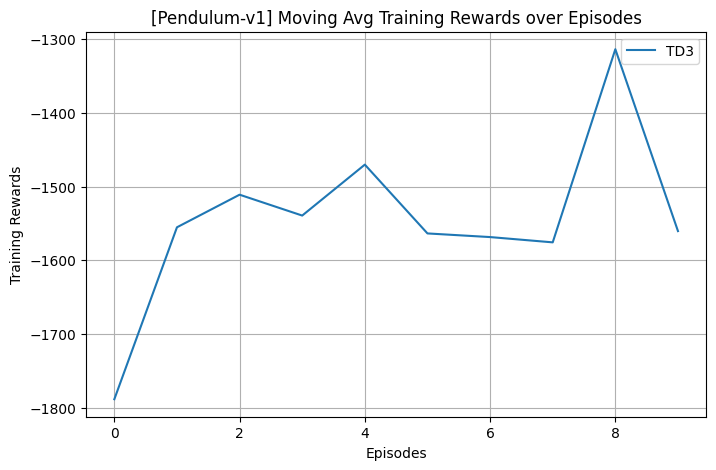

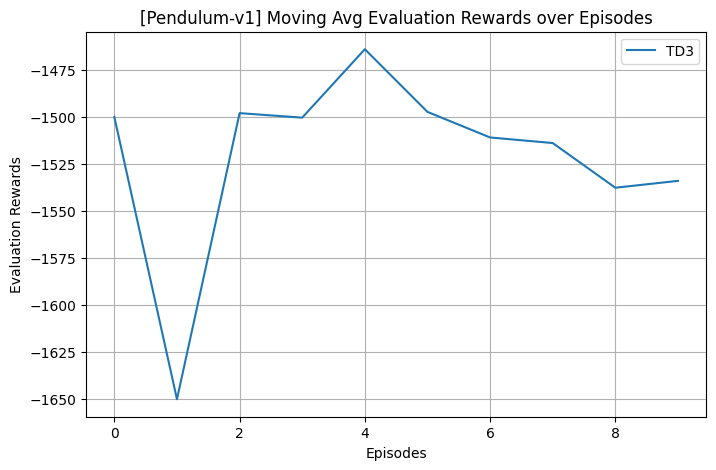

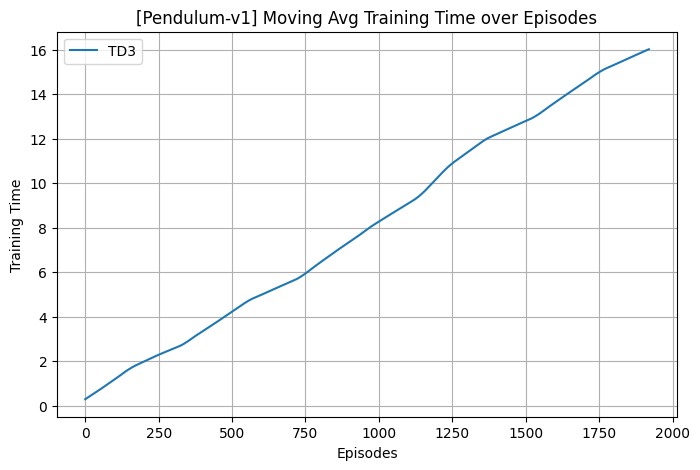

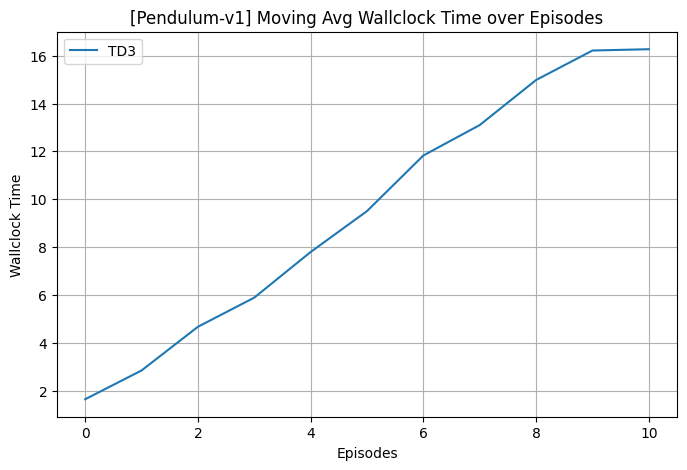

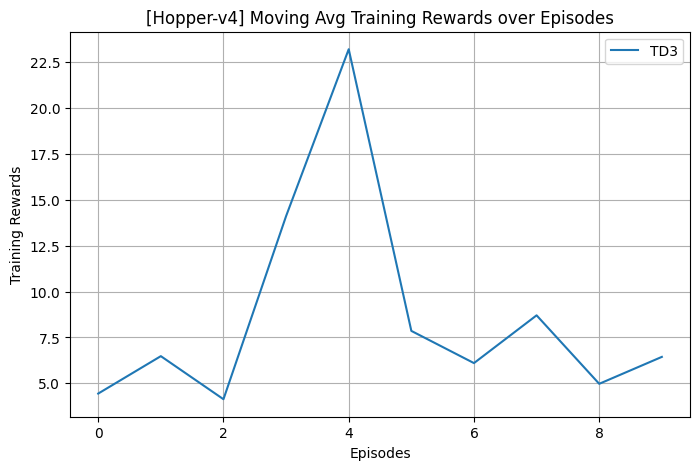

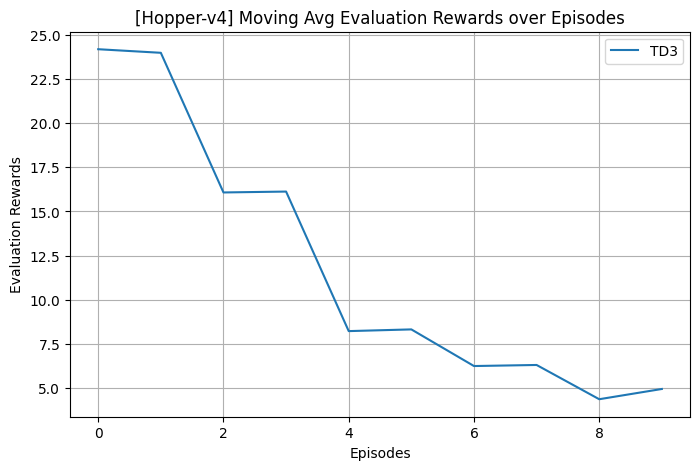

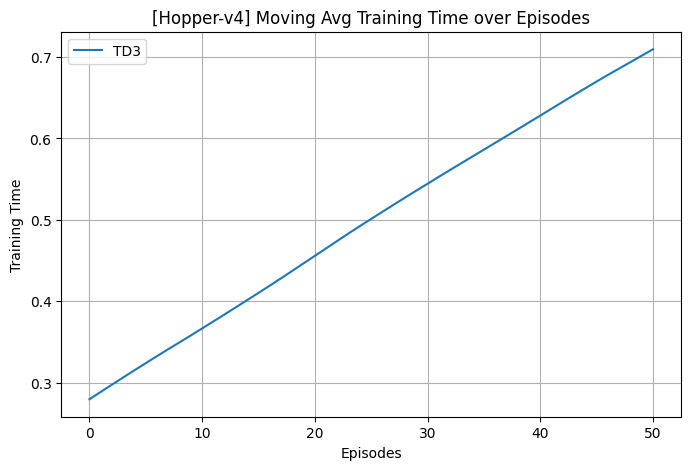

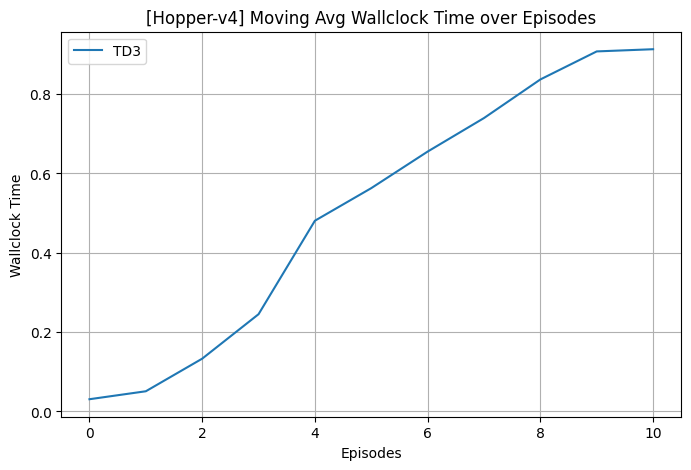

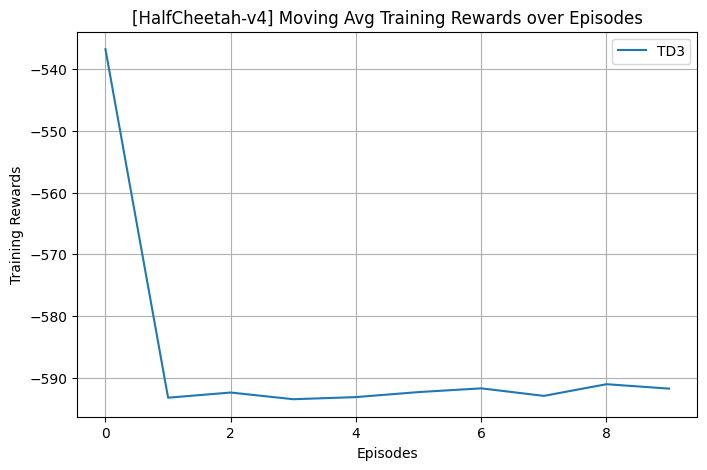

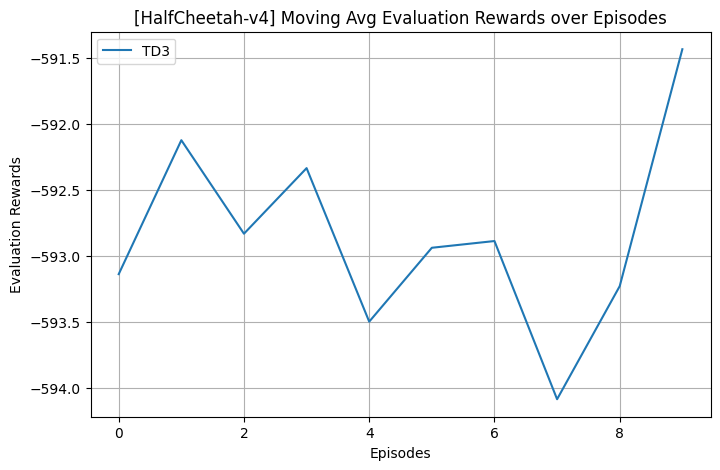

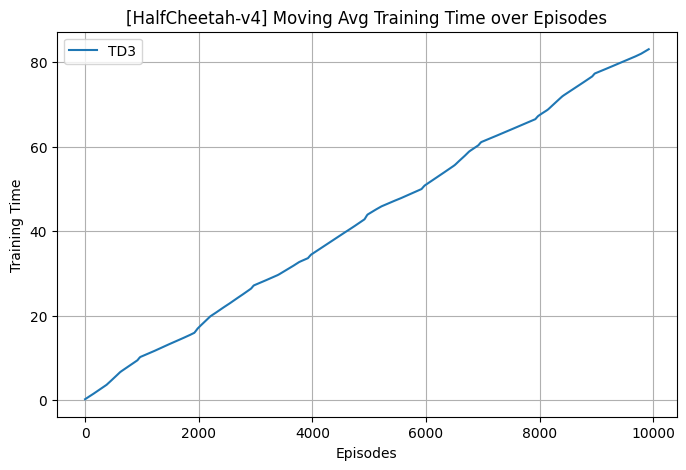

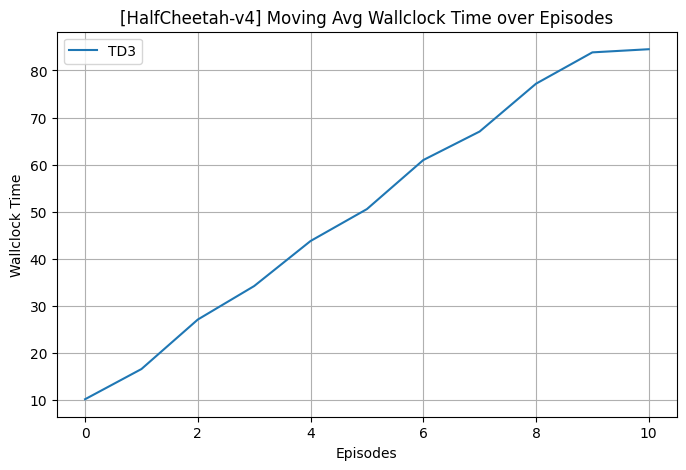

In [ ]:
env_names = ["Pendulum-v1", "Hopper-v4", "HalfCheetah-v4"]
td3_plot_config = {}

for env_id in env_names:
    print(f"-" * 50)
    print(f"Running {env_id}")
    env = gym.make(env_id)
    agent = TD3(
        env, seed, gamma, tau, bufferSize, batchSize, updateFrequencyPolicy,
        updateFrequencyValue, trainPolicyFrequency,
        policyOptimizerFn, valueOptimizerFn,
        policyOptimizerLR, valueOptimizerLR,
        MAX_TRAIN_EPISODES, MAX_EVAL_EPISODE,
        optimizerFn
    )

    train_rewards, train_times, eval_rewards, wallclock_times, final_eval_reward = agent.runTD3()
    td3_plot_config[env_id] = {
        "Training Rewards": {"TD3": [train_rewards]},
        "Evaluation Rewards": {"TD3": [eval_rewards]},
        "Training Time": {"TD3": [train_times]},
        "Wallclock Time": {"TD3": [wallclock_times]}
      }

# Display the plot for each environment.
plotResults(td3_plot_config, env_names)

# Soft Actor-Critic (SAC) [ 50 marks ]

SAC is an off-policy maximum entropy deep RL algorithm for continuous action spaces. It maintains two online Q-networks and two target Q-networks to mitigate overestimation bias, and uses a squashed Gaussian policy with automatic entropy tuning.

### Key Ideas

**1. Stochastic Policy (Squashed Gaussian)**  
The network learns $\mu$ and $\sigma$; samples $u \sim \mathcal{N}(\mu, \sigma)$, applies $a = \tanh(u)$, then rescales to the environment action range.

**2. Log-probability correction for tanh squashing:**

$$\log \pi(a \mid s) = \log p(u \mid s) - \sum_{i=0}^{D} \log(1 - \tanh^2(u_i))$$

**3. Policy Loss (maximize Q, maximize entropy):**

$$J_\pi(\phi) = -\, \mathbb{E}_{s \sim \mathcal{U}(D),\, \hat{a} \sim \pi} \left[ \min_k Q(s, \hat{a};\, \theta^k) - \alpha \log \pi(\hat{a} \mid s;\, \phi) \right]$$

**4. Automatic Entropy Tuning (learn $\alpha$):**

$$J(\alpha) = -\, \mathbb{E}_{s \sim \mathcal{U}(D),\, \hat{a} \sim \pi} \left[ \alpha \left( \mathcal{H} + \log \pi(\hat{a} \mid s;\, \phi) \right) \right]$$

where $\mathcal{H} = -|\mathcal{A}| = -\prod \text{shape}(a_\text{env})$

**5. Soft Bellman Backup (critic target):**

$$\text{target\_q} = r + \gamma \cdot \left( \min_k Q_{\text{target},k}(s', a') - \alpha \log \pi(a' \mid s') \right) \cdot (1 - \text{done})$$

**6. Soft (Polyak) Target Update:**

$$\theta_{\text{target}} \leftarrow (1 - \tau)\, \theta_{\text{target}} + \tau\, \theta_{\text{online}}$$



### Task

Implement the SAC agent using the class structure below.

In [15]:
import time
from collections import deque

In [16]:
class ValueNetwork(nn.Module):

    def __init__(self, stateDim, actionDim, hiddenDims):
        """
        Args:
            stateDim (int): dimension of state space
            actionDim (int): dimension of action space
            hiddenDims (list): hidden layer sizes

        Output:
            Initializes Q-network Q(s,a)
        """
        super(ValueNetwork, self).__init__()
        prevdim = stateDim + actionDim
        self.layers = nn.ModuleList()
        for dim in hiddenDims:
            self.layers.append(nn.Linear(prevdim, dim))
            prevdim = dim
        self.layers.append(nn.Linear(prevdim, 1))
        self.activation = nn.ReLU()

    def forward(self, state, action):
        """
        Args:
            state (tensor): shape (batch_size, stateDim)
            action (tensor): shape (batch_size, actionDim)

        Returns:
            q_value (tensor): predicted Q(s,a), shape (batch_size,1)
        """
        x = torch.cat([state, action], dim=1)
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

In [17]:
class PolicyNetwork(nn.Module):

    def __init__(self, stateDim, actionRange, hiddenDims):
        """
        Args:
            stateDim (int): state dimension
            actionRange (tuple): (action_low, action_high)
            hiddenDims (list): hidden layer sizes

        Output:
            Initializes stochastic policy network
        """
        super(PolicyNetwork, self).__init__()

        self.logSTD_min = -1
        self.logSTD_max = 1
        self.epsilon = 1e-6

        self.activation = nn.ReLU()
        self.actionLowVal = nn.Parameter(torch.FloatTensor(actionRange[0]), requires_grad=False)
        self.actionHighVal = nn.Parameter(torch.FloatTensor(actionRange[1]), requires_grad=False)
        self.actionRange = self.actionHighVal - self.actionLowVal

        self.inputLayer = nn.Linear(stateDim, hiddenDims[0])
        self.hLayers = nn.ModuleList()

        for i in range(len(hiddenDims)-1):
            self.hLayers.append(nn.Linear(hiddenDims[i], hiddenDims[i+1]))
        self.mean = nn.Linear(hiddenDims[-1], len(self.actionHighVal))
        self.logStd = nn.Linear(hiddenDims[-1], len(self.actionHighVal))


    def forward(self, state):
        """
        Args:
            state (tensor): input states

        Returns:
            action_env (tensor): sampled action in env range
            action_greedy (tensor): deterministic action
            log_prob (tensor): log probability of action
        """
        s = state
        l = self.activation(self.inputLayer(s))
        for layer in self.hLayers:
            l = self.activation(layer(l))
        mean, logSTD = self.mean(l), self.logStd(l)
        logSTD = logSTD.clamp(self.logSTD_min, self.logSTD_max)
        pi_s = torch.distributions.Normal(mean, logSTD.exp())
        u = pi_s.rsample()
        a = torch.tanh(u)
        a_env = self.rescale(a)
        a_greedy = self.rescale(torch.tanh(mean))
        log_prob = pi_s.log_prob(u) - torch.log(1 - a**2 + self.epsilon)
        log_prob = log_prob.sum(dim=-1, keepdim=True)
        return a_env, a_greedy, log_prob


    def rescale(self, action):
        """
        Args:
            action (tensor): tanh output in [-1,1]

        Returns:
            scaled_action (tensor): action in environment range
        """
        squasherMin = -1
        squasherMax = 1
        multiplier = (self.actionHighVal - self.actionLowVal) / (squasherMax - squasherMin)
        action_r = (action - squasherMin) * multiplier + self.actionLowVal
        return action_r

In [18]:
class ReplayBuffer:

    def __init__(self, bufferSize):
        """
        Args:
            bufferSize (int): max number of stored transitions
        """
        self.bufferSize = bufferSize
        self.buffer = deque(maxlen=bufferSize)


    def store(self, transition):
        """
        Args:
            transition (tuple): (state, action, reward, next_state, done)
        """
        self.buffer.append(transition)

    def sample(self, batchSize):
        """
        Args:
            batchSize (int)

        Returns:
            batch (list): sampled transitions
        """
        batch = random.sample(self.buffer, batchSize)
        return batch

    def splitExperiences(self, experiences):
        #it takes in experiences and gives the following:
        #states, actions, rewards, nextStates, dones
        #
        #Your code goes in here
        #
        states = []
        actions = []
        rewards = []
        nextStates = []
        dones = []

        # spliting the curr_states, action_taken, reward_got, next_states, done(whether_terminated)
        # in 5 different lists
        for exp in experiences:
            s, a, r, ns, done = exp
            states.append(s)
            actions.append(a)
            rewards.append(r)
            nextStates.append(ns)
            dones.append(done)

        # converting python list into numpy array
        states = np.array(states)
        actions = np.array(actions)
        rewards = np.array(rewards)
        nextStates = np.array(nextStates)
        dones = np.array(dones)

        # finally return all the separated numpy arrays
        return states, actions, rewards, nextStates, dones

    def length(self):
        return len(self.buffer)

In [ ]:
class SAC:

    def __init__(self, env, gamma, tau, bufferSize, batchSize, entropyLR,
                 updateFrequency, policyOptimizerFn, valueOptimizerFn_1,
                 valueOptimizerFn_2, policyOptimizerLR, valueOptimizerLR,
                 alphaOptimizerFn, MAX_TRAIN_EPISODES,
                 MAX_EVAL_EPISODE, hDims, minSamples):
        """
        Args:
            env: gym environment
            gamma (float): discount factor
            tau (float): target update rate
            bufferSize (int): replay buffer size
            batchSize (int): training batch size
        """
        self.env = env
        self.gamma = gamma
        self.tau = tau
        self.bufferSize = bufferSize
        self.batchSize = batchSize
        self.minSamples = minSamples
        self.updateFrequency = updateFrequency
        self.MAX_TRAIN_EPISODES = MAX_TRAIN_EPISODES
        self.MAX_EVAL_EPISODE = MAX_EVAL_EPISODE
        self.MAX_VALUE_GRAD_NORM = 0.5
        self.MAX_POLICY_GRAD_NORM = 0.5
        self.entropyLR = entropyLR

        self.stateDim = self.env.observation_space.shape[0]
        self.actionDim = self.env.action_space.shape[0]

        self.actionLowVal = torch.tensor(self.env.action_space.low, dtype=torch.float32)
        self.actionHighVal = torch.tensor(self.env.action_space.high, dtype=torch.float32)
        self.actionRange = self.actionHighVal - self.actionLowVal

        self.targetValueNetwork1 = ValueNetwork(self.stateDim, self.actionDim, hiddenDims=hDims)
        self.targetValueNetwork2 = ValueNetwork(self.stateDim, self.actionDim, hiddenDims=hDims)
        self.onlineValueNetwork1 = ValueNetwork(self.stateDim, self.actionDim, hiddenDims=hDims)
        self.onlineValueNetwork2 = ValueNetwork(self.stateDim, self.actionDim, hiddenDims=hDims)
        self.policyNetwork = PolicyNetwork(
            self.stateDim,
            (self.actionLowVal, self.actionHighVal),
            hiddenDims=hDims
        )

        self.logAlpha = torch.tensor(0.0, requires_grad=True)

        self.alphaOptimizer = alphaOptimizerFn([self.logAlpha], lr=entropyLR)
        self.valueOptimizerFn_1 = valueOptimizerFn_1(self.onlineValueNetwork1.parameters(), lr=valueOptimizerLR)
        self.valueOptimizerFn_2 = valueOptimizerFn_2(self.onlineValueNetwork2.parameters(), lr=valueOptimizerLR)
        self.policyOptimizerFn = policyOptimizerFn(self.policyNetwork.parameters(), lr=policyOptimizerLR)

        self.updateTargetNetworks()
        self.startTime = time.time()
        self.rBuffer = ReplayBuffer(bufferSize)


    def selectAction(self, state):
        """
        Args:
            state (array): current state

        Returns:
            action (array): action sampled from policy
        """
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        a_env, a_greedy, log_prob = self.policyNetwork(state)
        return a_env.detach().numpy().flatten()


    def trainNetworks(self, batch, episode):
        """
        Args:
            batch: sampled transitions

        Updates:
            critics, policy, entropy coefficient
        """
        ss, actions, rs, sNexts, dones = self.rBuffer.splitExperiences(batch)

        ss = torch.tensor(ss, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.float32)
        rs = torch.tensor(rs, dtype=torch.float32).unsqueeze(1)
        sNexts = torch.tensor(sNexts, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

        with torch.no_grad():
            as_p, _, logp_p = self.policyNetwork(sNexts)
            q_p_1 = self.targetValueNetwork1(sNexts, as_p)
            q_p_2 = self.targetValueNetwork2(sNexts, as_p)
            q_p = torch.min(q_p_1, q_p_2)
            alpha = self.logAlpha.exp()
            target_q = rs + self.gamma * (1 - dones) * (q_p - alpha * logp_p)

        q_1 = self.onlineValueNetwork1(ss, actions)
        q_2 = self.onlineValueNetwork2(ss, actions)
        q_1_loss = (0.5 * (q_1 - target_q)**2).mean()
        q_2_loss = (0.5 * (q_2 - target_q)**2).mean()

        self.valueOptimizerFn_1.zero_grad()
        q_1_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.onlineValueNetwork1.parameters(), self.MAX_VALUE_GRAD_NORM)
        self.valueOptimizerFn_1.step()

        self.valueOptimizerFn_2.zero_grad()
        q_2_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.onlineValueNetwork2.parameters(), self.MAX_VALUE_GRAD_NORM)
        self.valueOptimizerFn_2.step()

        for p in self.onlineValueNetwork1.parameters():
            p.requires_grad = False
        for p in self.onlineValueNetwork2.parameters():
            p.requires_grad = False

        as_current, _, logp = self.policyNetwork(ss)
        q_current_1 = self.onlineValueNetwork1(ss, as_current)
        q_current_2 = self.onlineValueNetwork2(ss, as_current)
        q_current = torch.min(q_current_1, q_current_2)

        alpha = self.logAlpha.exp()
        policyLoss = (alpha * logp - q_current).mean()

        self.policyOptimizerFn.zero_grad()
        policyLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.policyNetwork.parameters(), self.MAX_POLICY_GRAD_NORM)
        self.policyOptimizerFn.step()

        for p in self.onlineValueNetwork1.parameters():
            p.requires_grad = True
        for p in self.onlineValueNetwork2.parameters():
            p.requires_grad = True

        targetEntropy = -self.actionDim
        alpha_target = (logp + targetEntropy).detach()
        alphaLoss = -(self.logAlpha * alpha_target).mean()
        self.alphaOptimizer.zero_grad()
        alphaLoss.backward()
        self.alphaOptimizer.step()


    def updateTargetNetworks(self):
        """
        Performs Polyak update of target networks
        """
        for target_param, online_param in zip(self.targetValueNetwork1.parameters(), self.onlineValueNetwork1.parameters()):
            mixedWeights = (1 - self.tau) * target_param + self.tau * online_param
            target_param.data.copy_(mixedWeights)

        for target_param, online_param in zip(self.targetValueNetwork2.parameters(), self.onlineValueNetwork2.parameters()):
            mixedWeights = (1 - self.tau) * target_param + self.tau * online_param
            target_param.data.copy_(mixedWeights)


    def trainAgent(self):
        """
        Runs training episodes

        Returns:
            trainRewards (list): reward per episode
        """
        self.updateTargetNetworks()
        trainRewards = []
        trainTimes = []

        for e in range(self.MAX_TRAIN_EPISODES):
            rewardPerEpisode = 0.0
            s, _ = self.env.reset()
            done = False
            while not done:
                if self.rBuffer.length() < self.minSamples:
                    a = self.env.action_space.sample()
                else:
                    a = self.selectAction(s)

                s_next, r, done, truncated, _ = self.env.step(a)
                done = done or truncated

                rewardPerEpisode += float(r)
                experience = (s, a, r, s_next, done)
                self.rBuffer.store(experience)

                if self.rBuffer.length() > self.minSamples:
                    experiences = self.rBuffer.sample(self.batchSize)
                    self.trainNetworks(experiences, e)
                s = s_next

            if e % self.updateFrequency:
                self.updateTargetNetworks()

            trainRewards.append(rewardPerEpisode)
            trainTimes.append(time.time() - self.startTime)
        return trainRewards, trainTimes


    def evaluateAgent(self):
        """
        Returns:
            mean_reward (float): evaluation performance
        """
        finalEvalRewardsList = []
        for e in range(self.MAX_EVAL_EPISODE):
            episodeReward = 0.0
            s, _ = self.env.reset()
            done = False
            for c in count():
                s_tensor = torch.tensor(s, dtype=torch.float32)
                _, a_greedy, _ = self.policyNetwork(s_tensor)
                a = a_greedy.detach().cpu().numpy()
                s_next, r, done, truncated, _ = self.env.step(a)
                episodeReward += r
                s = s_next
                if done or truncated:
                    break
            finalEvalRewardsList.append(episodeReward)
        return np.mean(finalEvalRewardsList)


    def runSAC(self):
        """
        Runs full training pipeline

        Returns:
            train_rewards, eval_score, training_time
        """
        train_rewards, training_time = self.trainAgent()
        eval_score = self.evaluateAgent()
        return train_rewards, eval_score, training_time


In [ ]:

# We evaluate the SAC agent on multiple continuous-control


# Environments used in this experiment
env_names = [
    "Pendulum-v1",
    "HalfCheetah-v4",
    "Hopper-v4"
]

# Number of independent training runs per environment
num_runs = 5

# For each environment:
'''  1. Train the SAC agent for multiple runs
  2. Collect training rewards
  3. Compute mean and standard deviation'''

sac_plot_config = {}

for env_name in env_names:

    print(f"\n===== Environment: {env_name} =====")

    all_rewards = []
    all_times = []
    eval_score_over_run = 0.0

    for run in range(num_runs):

        print(f"Run {run+1}")

        # Create environment
        env = gym.make(env_name)

        # Initialize SAC agent
        agent = SAC(
            env=env,
            gamma=0.99,
            tau=0.015,
            bufferSize=50000,
            entropyLR=2e-4,
            updateFrequency=5,
            policyOptimizerFn=torch.optim.Adam,
            valueOptimizerFn_1=torch.optim.Adam,
            valueOptimizerFn_2=torch.optim.Adam,
            policyOptimizerLR=3e-4,
            valueOptimizerLR=3e-4,
            alphaOptimizerFn=torch.optim.Adam,
            MAX_TRAIN_EPISODES=100,
            MAX_EVAL_EPISODE=1,
            hDims=[256, 128],
            batchSize=32,
            minSamples=32
        )

        rewards, eval_score, train_time = agent.runSAC()

        all_rewards.append(rewards)
        all_times.append(train_time)
        eval_score_over_run += eval_score

    eval_score_over_run /= num_runs
    mean_per_run = np.mean(np.array(all_rewards), axis=1)
    mean_time_per_run = np.mean(np.array(all_times), axis=1)

    sac_plot_config[env_name] = {
        "Train Rewards": {"SAC" : [mean_per_run]},
        "Train Times(in sec)": {"SAC" : [mean_time_per_run]}
    }
    run_mean = np.mean(mean_per_run)
    run_std = np.std(mean_per_run)

    print(f"Mean rewards: {run_mean} | Std rewards: {run_std} | Mean Eval Score: {eval_score_over_run}")
    print(f"Finished {env_name}")


===== Environment: Pendulum-v1 =====
Run 1
Run 2
Run 3
Run 4
Run 5
Mean rewards: -1438.5539715775708 and Std rewards: 39.36237268952858 | Mean Eval Score: -1645.2138782290517
Finished Pendulum-v1

===== Environment: HalfCheetah-v4 =====
Run 1


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Run 2
Run 3


KeyboardInterrupt: 

In [ ]:
plotResults(sac_plot_config, env_names)

## Plot all the graph across all the 3 environment and write an analysis report.


# PPO [50 marks]
<a id="PPO"></a>

PPO have quite a few key implementation details.
Please Refer:
"Proximal Policy Optimization Algorithms" [PPO](https://arxiv.org/abs/1707.06347) and
"Implementation Matters in Deep RL: A Case Study on PPO and TRPO" [Implementation Matters](https://openreview.net/forum?id=r1etN1rtPB)

Lets finish things off with an easy implementation of PPO!
A easy way to check you implementation details is running your implementation on some easier environment first and make sure it converges. Like "CartPole-v1" should converge to episodic return of 500 in around 300k steps.

In [ ]:
#All imports here
## Feel free to add or remove

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
from torch.distributions.normal import Normal

import torch.multiprocessing as mp
from torch.multiprocessing import Barrier, Queue, Process

In [28]:
# PPO Hyperparameters (multiprocessing version)

ppo_gym_id = "HalfCheetah-v4"
ppo_learning_rate = 2e-4
ppo_seed = 1
ppo_total_timesteps = 1000000

ppo_num_workers = 4
ppo_num_steps = 2048

ppo_gamma = 0.99
ppo_gae_lambda = 0.95

ppo_update_epochs = 10
ppo_num_minibatches = 32

ppo_clip_coef = 0.2
ppo_clip_vloss = True

ppo_ent_coef = 0.001
ppo_vf_coef = 0.5
ppo_max_grad_norm = 0.5

ppo_norm_adv = True
ppo_anneal_lr = True
ppo_target_kl = 0.015

ppo_batch_size = ppo_num_workers * ppo_num_steps
ppo_minibatch_size = ppo_batch_size // ppo_num_minibatches

print(f"PPO: batch={ppo_batch_size}, minibatch={ppo_minibatch_size}")

PPO: batch=8192, minibatch=256


In [29]:
# PPO Agent (takes raw dims, works in any process)
class PPOAgent(nn.Module):
    """
    PPO agent containing separate actor and critic networks.
    Supports both discrete and continuous action spaces.
    """

    def __init__(self, obs_dim, act_dim, is_discrete=False,
                 action_high=None, action_low=None):
        """
        Initialize the PPO agent.

        Args:
            obs_dim (int): Dimension of the observation/state space.
            act_dim (int): Dimension of the action space.
            is_discrete (bool): True if the environment has a discrete
                                action space, otherwise False.
            action_high (array-like, optional): Upper bound of the
                                continuous action space.
            action_low (array-like, optional): Lower bound of the
                                continuous action space.

        Expected Output:
            Initializes actor and critic neural networks along with
            parameters required for action scaling in continuous spaces.
        """

        #Your Code goes here
        super(PPOAgent, self).__init__()
        self.is_discrete = is_discrete

        # Shared feature extractor
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        # Actor head
        if is_discrete:
            self.actor = nn.Linear(128, act_dim)
        else:
            self.actor_mean = nn.Linear(128, act_dim)
            self.actor_log_std = nn.Parameter(torch.zeros(act_dim))

        # Critic head
        self.critic = nn.Linear(128, 1)

        # Action scaling for continuous
        if not is_discrete:
            self.action_high = torch.FloatTensor(action_high)
            self.action_low = torch.FloatTensor(action_low)


    def get_value(self, x):
        """
        Compute the value estimate for a given state.

        Args:
            x (Tensor): Input state tensor of shape (batch_size, obs_dim).

        Expected Output:
            Tensor containing the predicted state value V(s)
            from the critic network.
        """
        x = self.shared(x)
        return self.critic(x)



    def get_action_and_value(self, x, action=None):
        """
        Compute action, log probability, entropy, and state value.

        Args:
            x (Tensor): Input state tensor of shape (batch_size, obs_dim).
            action (Tensor, optional): Specific action for which the
                                       log probability should be computed.
                                       If None, the function samples an action
                                       from the policy distribution.

        Expected Output:
            action (Tensor): Sampled or provided action.
            log_prob (Tensor): Log probability of the selected action.
            entropy (Tensor): Entropy of the action distribution
                              (used for exploration).
            value (Tensor): Predicted state value from the critic.
        """
        x = self.shared(x)
        value = self.critic(x)

        if self.is_discrete:
            logits = self.actor(x)
            dist = Categorical(logits=logits)
            if action is None:
                action = dist.sample()
            log_prob = dist.log_prob(action)
            entropy = dist.entropy()
        else:
            mean = self.actor_mean(x)
            std = torch.exp(self.actor_log_std)
            dist = Normal(mean, std)
            if action is None:
                raw_action = dist.rsample()
                # Tanh squashing
                action = torch.tanh(raw_action)
                # Scale to env range
                action = self.action_low.to(action.device) + (action + 1) * 0.5 * (
                    self.action_high.to(action.device) - self.action_low.to(action.device)
                )
            else:
                # Inverse scaling: action in env range -> [-1, 1]
                action = action.to(x.device)
                squashed = 2.0 * (action - self.action_low) / (self.action_high - self.action_low) - 1.0
                # Clamp to avoid numerical issues with arctanh
                squashed = torch.clamp(squashed, -0.999999, 0.999999)
                # Inverse tanh: arctanh(x) = 0.5 * log((1+x)/(1-x))
                raw_action = 0.5 * torch.log((1 + squashed) / (1 - squashed))

            # Calculate log prob (simplified for continuous with tanh)
            log_prob = dist.log_prob(raw_action).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1)

        return action, log_prob, entropy, value

In [30]:
# PPO Worker + Training Loop (Multiprocessing Version)
def ppo_worker(worker_id, global_agent,
               env_id, seed, num_steps, num_updates,
               shared_obs, shared_actions, shared_logprobs,
               shared_rewards, shared_dones, shared_values,
               shared_next_obs, shared_next_done,
               collect_barrier, update_barrier, ep_queue):
    """
    PPO worker process responsible for collecting rollouts.

    Args:
        worker_id        : Unique ID of the worker process.
        global_agent     : Shared PPO policy network.
        env_id           : Gym environment name.
        seed             : Random seed for reproducibility.
        num_steps        : Number of steps collected per rollout.
        num_updates      : Number of PPO updates to perform.

        shared_obs       : Shared buffer storing observations.
        shared_actions   : Shared buffer storing actions.
        shared_logprobs  : Shared buffer storing log probabilities.
        shared_rewards   : Shared buffer storing rewards.
        shared_dones     : Shared buffer storing termination flags.
        shared_values    : Shared buffer storing value predictions.

        shared_next_obs  : Shared buffer storing next observations.
        shared_next_done : Shared buffer storing next done flag.

        collect_barrier  : Synchronization barrier for rollout collection.
        update_barrier   : Synchronization barrier after PPO update.
        ep_queue         : Queue used to send episode rewards to main process.

    Expected Output:
        This function does not return values directly.
        Instead, it stores rollout data in shared buffers and
        sends episode rewards to the main process through ep_queue.
    """
    # Create local environment
    env = gym.make(env_id)
    env.reset(seed=seed + worker_id)

    # Get dimensions
    obs_dim = env.observation_space.shape[0]
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
    act_dim = env.action_space.n if is_discrete else env.action_space.shape[0]

    # Local state
    state, _ = env.reset()
    done = False
    episode_reward = 0.0

    for update in range(num_updates):
        # Sync with global model at start of rollout
        with torch.no_grad():
            local_agent_state_dict = {k: v.clone() for k, v in global_agent.state_dict().items()}

        # Storage for this worker's trajectory
        local_obs = []
        local_actions = []
        local_logprobs = []
        local_rewards = []
        local_dones = []
        local_values = []

        # Collect trajectory
        for step in range(num_steps):
            state_tensor = torch.FloatTensor(state).unsqueeze(0)

            # Use local copy of model for inference
            with torch.no_grad():
                # Create temporary agent with local state dict
                temp_agent = PPOAgent(obs_dim, act_dim, is_discrete,
                                    env.action_space.high if not is_discrete else None,
                                    env.action_space.low if not is_discrete else None)
                temp_agent.load_state_dict(local_agent_state_dict)
                temp_agent.eval()

                action, log_prob, _, value = temp_agent.get_action_and_value(state_tensor)

            if is_discrete:
                action_item = action.item()
            else:
                action_item = action.squeeze(0).cpu().numpy()

            next_state, reward, terminated, truncated, _ = env.step(action_item)
            done_flag = terminated or truncated

            # Store locally
            local_obs.append(state.copy())
            if is_discrete:
                local_actions.append(action.item())
            else:
                local_actions.append(action_item)  # This is already numpy from above
            local_logprobs.append(log_prob.item())
            local_rewards.append(reward)
            local_dones.append(float(done_flag))
            local_values.append(value.item())

            episode_reward += reward

            if done_flag:
                # Send episode reward to main process
                ep_queue.put((worker_id, episode_reward))
                episode_reward = 0.0
                state, _ = env.reset()
                done = False
            else:
                state = next_state
                done = done_flag

        # Write to shared memory at specific offset for this worker
        offset = worker_id * num_steps
        for i, (o, a, lp, r, d, v) in enumerate(zip(local_obs, local_actions, local_logprobs,
                                                     local_rewards, local_dones, local_values)):
            idx = offset + i
            # Convert numpy array to torch tensor before assignment
            shared_obs[idx, :] = torch.from_numpy(o) if isinstance(o, np.ndarray) else o
            shared_actions[idx] = a if isinstance(a, (int, float)) else torch.tensor(a)
            shared_logprobs[idx] = lp
            shared_rewards[idx] = r
            shared_dones[idx] = d
            shared_values[idx] = v

        # Store next observation and done flag for bootstrap
        shared_next_obs[worker_id, :] = torch.from_numpy(state) if isinstance(state, np.ndarray) else state
        shared_next_done[worker_id] = float(done)

        # Wait at collection barrier for all workers to finish
        collect_barrier.wait()

        # Wait at update barrier for main process to finish optimization
        update_barrier.wait()

    env.close()

In [31]:
def train_ppo(env_id=ppo_gym_id, seed=ppo_seed,
              total_timesteps=ppo_total_timesteps,
              num_workers=ppo_num_workers, num_steps=ppo_num_steps,
              lr=ppo_learning_rate, gamma=ppo_gamma,
              gae_lambda=ppo_gae_lambda, update_epochs=ppo_update_epochs,
              num_minibatches=ppo_num_minibatches,
              clip_coef=ppo_clip_coef, clip_vloss=ppo_clip_vloss,
              ent_coef=ppo_ent_coef, vf_coef=ppo_vf_coef,
              max_grad_norm=ppo_max_grad_norm, norm_adv=ppo_norm_adv,
              anneal_lr=ppo_anneal_lr, target_kl=ppo_target_kl):
    """
    PPO training loop using multiprocessing workers.

    Args:
        env_id           : Gym environment used for training.
        seed             : Random seed.
        total_timesteps  : Total number of environment interactions.
        num_workers      : Number of parallel workers collecting data.
        num_steps        : Number of rollout steps per worker.

        lr               : Learning rate for optimizer.
        gamma            : Discount factor for future rewards.
        gae_lambda       : Lambda parameter for GAE.

        update_epochs    : Number of PPO update passes per batch.
        num_minibatches  : Number of minibatches for SGD.

        clip_coef        : PPO clipping coefficient.
        clip_vloss       : Whether value loss clipping is used.

        ent_coef         : Entropy coefficient for exploration.
        vf_coef          : Value loss coefficient.
        max_grad_norm    : Maximum gradient norm for clipping.

        norm_adv         : Whether to normalize advantages.
        anneal_lr        : Whether learning rate is annealed.
        target_kl        : Optional KL divergence stopping threshold.

    Expected Output:
        results      : List containing tuples (global_step, episode_reward)
                       used to plot the learning curve.
        global_agent : The trained PPO agent.
    """
    # Get environment specs
    dummy_env = gym.make(env_id)
    obs_dim = dummy_env.observation_space.shape[0]
    is_discrete = isinstance(dummy_env.action_space, gym.spaces.Discrete)
    act_dim = dummy_env.action_space.n if is_discrete else dummy_env.action_space.shape[0]
    action_high = dummy_env.action_space.high if not is_discrete else None
    action_low = dummy_env.action_space.low if not is_discrete else None
    dummy_env.close()

    # Calculate training parameters
    batch_size = num_workers * num_steps
    num_updates = total_timesteps // batch_size
    minibatch_size = batch_size // num_minibatches

    print(f"Starting PPO training: {num_updates} updates, batch size {batch_size}")

    # Create shared global agent
    global_agent = PPOAgent(obs_dim, act_dim, is_discrete, action_high, action_low)
    global_agent.share_memory()

    # Shared memory buffers using torch tensors - ensure they're on CPU
    shared_obs = torch.zeros((num_workers * num_steps, obs_dim), dtype=torch.float32).share_memory_()

    if is_discrete:
        shared_actions = torch.zeros((num_workers * num_steps,), dtype=torch.long).share_memory_()
    else:
        shared_actions = torch.zeros((num_workers * num_steps, act_dim), dtype=torch.float32).share_memory_()

    shared_logprobs = torch.zeros((num_workers * num_steps,), dtype=torch.float32).share_memory_()
    shared_rewards = torch.zeros((num_workers * num_steps,), dtype=torch.float32).share_memory_()
    shared_dones = torch.zeros((num_workers * num_steps,), dtype=torch.float32).share_memory_()
    shared_values = torch.zeros((num_workers * num_steps,), dtype=torch.float32).share_memory_()

    # Next state buffers for bootstrap
    shared_next_obs = torch.zeros((num_workers, obs_dim), dtype=torch.float32).share_memory_()
    shared_next_done = torch.zeros((num_workers,), dtype=torch.float32).share_memory_()

    # Synchronization primitives
    collect_barrier = Barrier(num_workers + 1)  # Workers + main process
    update_barrier = Barrier(num_workers + 1)

    # Episode reward queue
    ep_queue = Queue()

    # Spawn worker processes
    workers = []
    for worker_id in range(num_workers):
        p = Process(target=ppo_worker, args=(
            worker_id, global_agent, env_id, seed, num_steps, num_updates,
            shared_obs, shared_actions, shared_logprobs,
            shared_rewards, shared_dones, shared_values,
            shared_next_obs, shared_next_done,
            collect_barrier, update_barrier, ep_queue
        ))
        p.start()
        workers.append(p)

    # Optimizer
    optimizer = optim.Adam(global_agent.parameters(), lr=lr, eps=1e-5)

    # Results tracking
    results = []
    global_step = 0

    # Training loop (main process)
    for update in range(num_updates):
        # Anneal learning rate if requested
        if anneal_lr:
            frac = 1.0 - (update - 1.0) / num_updates
            lrnow = frac * lr
            optimizer.param_groups[0]["lr"] = lrnow

        # Wait for all workers to finish collection
        collect_barrier.wait()

        # Collect episode rewards from queue without blocking
        while not ep_queue.empty():
            try:
                worker_id, ep_reward = ep_queue.get_nowait()
                results.append((global_step, ep_reward))
            except:
                break

        global_step += batch_size

        # Compute GAE advantages and returns
        with torch.no_grad():
            # Get next values for bootstrap
            next_values = global_agent.get_value(shared_next_obs).squeeze()

            # Reshape to (num_steps, num_workers)
            rewards = shared_rewards.view(num_workers, num_steps).t()
            dones = shared_dones.view(num_workers, num_steps).t()
            values = shared_values.view(num_workers, num_steps).t()
            next_values = next_values.view(1, num_workers)
            next_dones = shared_next_done.view(1, num_workers)

            advantages = torch.zeros_like(rewards)
            lastgaelam = 0

            for t in reversed(range(num_steps)):
                if t == num_steps - 1:
                    nextnonterminal = 1.0 - next_dones
                    nextvals = next_values
                else:
                    nextnonterminal = 1.0 - dones[t+1]
                    nextvals = values[t+1]

                delta = rewards[t] + gamma * nextvals * nextnonterminal - values[t]
                advantages[t] = lastgaelam = delta + gamma * gae_lambda * nextnonterminal * lastgaelam

            returns = advantages + values

            # Flatten
            advantages = advantages.t().reshape(-1)
            returns = returns.t().reshape(-1)

            # Normalize advantages
            if norm_adv:
                advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Flatten batch
        b_obs = shared_obs
        if is_discrete:
            b_actions = shared_actions.long()
        else:
            b_actions = shared_actions
        b_logprobs = shared_logprobs
        b_advantages = advantages
        b_returns = returns
        b_values = shared_values

        # Optimizing the policy and value network
        b_inds = np.arange(batch_size)
        clipfracs = []

        for epoch in range(update_epochs):
            np.random.shuffle(b_inds)
            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = b_inds[start:end]

                _, newlogprob, entropy, newvalue = global_agent.get_action_and_value(
                    b_obs[mb_inds],
                    b_actions[mb_inds] if not is_discrete else b_actions[mb_inds]
                )

                logratio = newlogprob - b_logprobs[mb_inds]
                ratio = logratio.exp()

                with torch.no_grad():
                    # Approximate KL divergence
                    old_approx_kl = (-logratio).mean()
                    approx_kl = ((ratio - 1) - logratio).mean()
                    clipfracs.append(((ratio - 1.0).abs() > clip_coef).float().mean().item())

                mb_advantages = b_advantages[mb_inds]

                # Policy loss
                pg_loss1 = -mb_advantages * ratio
                pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()

                # Value loss
                newvalue = newvalue.view(-1)
                if clip_vloss:
                    v_loss_unclipped = (newvalue - b_returns[mb_inds]) ** 2
                    v_clipped = b_values[mb_inds] + torch.clamp(
                        newvalue - b_values[mb_inds],
                        -clip_coef,
                        clip_coef,
                    )
                    v_loss_clipped = (v_clipped - b_returns[mb_inds]) ** 2
                    v_loss_max = torch.max(v_loss_unclipped, v_loss_clipped)
                    v_loss = 0.5 * v_loss_max.mean()
                else:
                    v_loss = 0.5 * ((newvalue - b_returns[mb_inds]) ** 2).mean()

                entropy_loss = entropy.mean()
                loss = pg_loss - ent_coef * entropy_loss + vf_coef * v_loss

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(global_agent.parameters(), max_grad_norm)
                optimizer.step()

            # Early stopping on KL divergence
            if target_kl is not None:
                if approx_kl > target_kl:
                    print(f"Early stopping at epoch {epoch} due to KL divergence {approx_kl:.4f} > {target_kl}")
                    break

        # Signal workers that update is complete
        update_barrier.wait()

        if update % 10 == 0:
            print(f"Update {update}/{num_updates}, Step {global_step}, Episodes collected: {len(results)}")
            if len(results) > 0:
                recent_rewards = [r for s, r in results[-10:]]
                print(f"  Mean reward (last 10): {np.mean(recent_rewards):.2f}")

    # Cleanup
    for p in workers:
        p.join()

    # Collect any remaining episode rewards
    while not ep_queue.empty():
        try:
            worker_id, ep_reward = ep_queue.get_nowait()
            results.append((global_step, ep_reward))
        except:
            break

    return results, global_agent

In [32]:
ppo_plot_config = {}
env_names = [
    "Pendulum-v1",
    "HalfCheetah-v4",
    "Hopper-v4"
]

num_runs = 5
for env_name in env_names:

    print(f"\n===== Environment: {env_name} =====")

    all_results = []

    for run in range(num_runs):
        print(f"Run {run+1}")

        results, global_agent = train_ppo(
            env_id=env_name,
            seed=ppo_seed + run * 100,  # Different seed per run
            total_timesteps=ppo_total_timesteps,
            num_workers=ppo_num_workers,
            num_steps=ppo_num_steps,
            lr=ppo_learning_rate,
            gamma=ppo_gamma,
            gae_lambda=ppo_gae_lambda,
            update_epochs=ppo_update_epochs,
            num_minibatches=ppo_num_minibatches,
            clip_coef=ppo_clip_coef,
            clip_vloss=ppo_clip_vloss,
            ent_coef=ppo_ent_coef,
            vf_coef=ppo_vf_coef,
            max_grad_norm=ppo_max_grad_norm,
            norm_adv=ppo_norm_adv,
            anneal_lr=ppo_anneal_lr,
            target_kl=ppo_target_kl
        )

        all_results.append(results)

    # Compute Statistics
    ppo_train_rewards = [[tr for (gs, tr) in all_results[i]] for i in range(num_runs)]
    ppo_global_steps = [[gs for (gs, tr) in all_results[i]] for i in range(num_runs)]

    ppo_plot_config[env_name] = {
        "Mean Train Rewards": {"PPO": ppo_train_rewards},
        "Mean Global Steps": {"PPO": ppo_global_steps}
    }

    print(f"Mean rewards: {np.mean(np.mean(ppo_train_rewards, axis=1))} and Std rewards: {np.std(np.mean(ppo_train_rewards, axis=1))} | mean Global steps: {np.mean(np.mean(ppo_global_steps, axis=1))}")
    print(f"Finished {env_name}")


===== Environment: Pendulum-v1 =====
Run 1
Starting PPO training: 122 updates, batch size 8192
Update 0/122, Step 8192, Episodes collected: 40
  Mean reward (last 10): -1329.97
Update 10/122, Step 90112, Episodes collected: 448
  Mean reward (last 10): -972.77
Update 20/122, Step 172032, Episodes collected: 860
  Mean reward (last 10): -515.60
Update 30/122, Step 253952, Episodes collected: 1268
  Mean reward (last 10): -323.07
Update 40/122, Step 335872, Episodes collected: 1676
  Mean reward (last 10): -310.90
Update 50/122, Step 417792, Episodes collected: 2088
  Mean reward (last 10): -227.37


Process Process-5:


KeyboardInterrupt: 

Process Process-6:
Process Process-7:
Process Process-8:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/tmp/ipykernel_974/3351121802.py", line 72, in ppo_worker
    temp_agent = PPOAgent(obs_dim, act_dim, is_discrete,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)


# Experiments and Plots [70 marks]
<a id="experiments"></a>

Run the VPG, REINFORCE, DDPG, TD3, PPO, on Pendulum, Hopper and Half Cheetah environment respectively.

Plot the following for each of the environment separately. Note based on different hyper-parameters and strategies you use, you can have multiple plots for each of the below.

As you are aware from your past experience, single run of the agent over the environment results in plots that have lot of variance and look very noisy. One way to overcome this is to create several different instances of the environment using different seeds and then average out the results across these and plot these. For all the plots below, you this strategy. You need to run 5 different instances of the environment for each agent. As you have seen in the lecture slides, we plot the maximum and minimum values around the mean in the plots, so this gives us the shaded plot with the mean curve in the between. In this assignment, you are required to do the same. Generate plots with envelop between maximum and minimum value
For each of the quantity of interest, plot each of the agent within the same plot using different colors for the envelop. Choose colors such that that there is clear contrast between the plots corresponding to different agents.

1. Plot mean train rewards vs episodes
2. Plot mean evaluation rewards vs episodes
3. Plot total steps vs episode
4. Plot train time vs episode
5. Plot wall clock time vs episode
6. Based on plots what are your observations about DDPG and TD3, compare the two algorithms.
7. What is the advatage of PPO over DDPG or TD3?